# Banking Credit Risk Prediction

## Project Objective

To develop a machine learning model that predicts whether a customer is likely to be classified as a bad credit customer using demographic, account, credit, and enquiry information.

## Business Objective

The goal is to help financial institutions identify potentially high-risk customers early and support better credit-risk assessment and decision-making.

# Phase 1 – Data Loading and Initial Data Quality Assessment

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## load the Original Datasets

In [2]:
import pandas as pd


demographics_clean = pd.read_csv("Cust_Demographics.csv")
account_clean = pd.read_csv("Cust_Account.csv")
enquiry_clean = pd.read_csv("Cust_Enquiry.csv")

print("Demographics shape:", demographics_clean.shape)
print("Account shape:", account_clean.shape)
print("Enquiry shape:", enquiry_clean.shape)

Demographics shape: (23896, 83)
Account shape: (186329, 21)
Enquiry shape: (413188, 6)


## 2: Validate Customer IDs

In [3]:


for name, df in {
    "Demographics": demographics_clean,
    "Account": account_clean,
    "Enquiry": enquiry_clean
}.items():
    print(f"\n{name}")
    print("Missing customer IDs:", df["customer_no"].isna().sum())
    print("Unique customers:", df["customer_no"].nunique())
    print("Total rows:", len(df))


Demographics
Missing customer IDs: 0
Unique customers: 23896
Total rows: 23896

Account
Missing customer IDs: 0
Unique customers: 23896
Total rows: 186329

Enquiry
Missing customer IDs: 0
Unique customers: 23896
Total rows: 413188


##  3: Check for Duplicate Records

In [4]:


for name, df in {
    "Demographics": demographics_clean,
    "Account": account_clean,
    "Enquiry": enquiry_clean
}.items():
    print(f"{name} duplicate rows:", df.duplicated().sum())

Demographics duplicate rows: 0
Account duplicate rows: 2401
Enquiry duplicate rows: 13827


## 4: Remove Exact Duplicate Records

In [5]:


account_clean = account_clean.drop_duplicates().copy()
enquiry_clean = enquiry_clean.drop_duplicates().copy()

print("Account shape after removing duplicates:", account_clean.shape)
print("Enquiry shape after removing duplicates:", enquiry_clean.shape)

print("\nRemaining Account duplicates:", account_clean.duplicated().sum())
print("Remaining Enquiry duplicates:", enquiry_clean.duplicated().sum())

Account shape after removing duplicates: (183928, 21)
Enquiry shape after removing duplicates: (399361, 6)

Remaining Account duplicates: 0
Remaining Enquiry duplicates: 0


##  5: Validate One Demographics Record per Customer

In [6]:


demographic_customer_counts = (
    demographics_clean["customer_no"]
    .value_counts()
)

print("Customers with exactly 1 demographics record:",
      (demographic_customer_counts == 1).sum())

print("Customers with more than 1 demographics record:",
      (demographic_customer_counts > 1).sum())

print("Maximum demographics records for one customer:",
      demographic_customer_counts.max())

Customers with exactly 1 demographics record: 23896
Customers with more than 1 demographics record: 0
Maximum demographics records for one customer: 1


## 6. Analyze the Target Variable

In [7]:


print("Target column present:", "Bad_label" in demographics_clean.columns)

print("\nTarget value counts:")
print(demographics_clean["Bad_label"].value_counts())

print("\nTarget percentage distribution:")
print(
    (demographics_clean["Bad_label"].value_counts(normalize=True) * 100)
    .round(2)
)

Target column present: True

Target value counts:
Bad_label
0    22892
1     1004
Name: count, dtype: int64

Target percentage distribution:
Bad_label
0    95.8
1     4.2
Name: proportion, dtype: float64


## 7. Analyze Missing Values in Demographics

In [8]:


missing_summary = pd.DataFrame({
    "missing_count": demographics_clean.isna().sum(),
    "missing_percentage": (
        demographics_clean.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values("missing_percentage", ascending=False)
)

print(missing_summary)

             missing_count  missing_percentage
feature_61           23887               99.96
feature_74           23879               99.93
feature_18           23878               99.92
feature_10           23845               99.79
feature_49           23792               99.56
feature_17           22869               95.70
feature_8            22635               94.72
feature_9            22635               94.72
feature_57           21503               89.99
feature_73           20951               87.68
feature_48           18399               77.00
feature_45           13713               57.39
feature_13           13004               54.42
feature_53           11610               48.59
feature_51           11422               47.80
feature_14            7733               32.36
feature_38            5682               23.78
feature_37            5682               23.78
feature_36            5682               23.78
feature_27            3637               15.22
feature_2    

## 8: Inspect High-Missingness Demographic Features

In [ ]:


high_missing_features = (
    missing_summary[missing_summary["missing_percentage"] >= 50]
    .index
    .tolist()
)

print("Features with 50% or more missing values:")
print(high_missing_features)

print("\nNumber of high-missingness features:",
      len(high_missing_features))

for col in high_missing_features:
    print(f"\n--- {col} ---")
    print("Missing %:", missing_summary.loc[col, "missing_percentage"])
    print("Non-missing values:", demographics_clean[col].notna().sum())
    print("Unique non-missing values:", demographics_clean[col].nunique())
    print("Sample values:")
    print(demographics_clean[col].dropna().head(10).tolist())

# Phase 2 – Data Cleaning and Feature Quality Refinement

## Check Redundancy Between Feature 8 and Feature 9

In [10]:


feature_8_9 = demographics_clean[["feature_8", "feature_9"]].dropna(
    subset=["feature_8", "feature_9"]
)

print("Rows with both features available:", len(feature_8_9))

print("\nNumber of unique feature_8 values:",
      feature_8_9["feature_8"].nunique())

print("Number of unique feature_9 values:",
      feature_8_9["feature_9"].nunique())

print("\nUnique feature_8 -> feature_9 mappings:")
mapping_check = (
    feature_8_9.groupby("feature_8")["feature_9"]
    .nunique()
)

print(mapping_check)

print("\nMaximum number of feature_9 values for one feature_8 value:",
      mapping_check.max())

Rows with both features available: 1261

Number of unique feature_8 values: 19
Number of unique feature_9 values: 19

Unique feature_8 -> feature_9 mappings:
feature_8
RCBL     1
RCBNH    1
RCBSR    1
RCFO     1
RCFR     1
RFCU     1
RINF     1
RMIC     1
RMINV    1
RMTVR    1
RNOA     1
RNOI     1
ROCPV    1
ROTVR    1
RPRN     1
RRCPV    1
RROCL    1
RRTVR    1
RUTR     1
Name: feature_9, dtype: int64

Maximum number of feature_9 values for one feature_8 value: 1


##  Investigate Extremely Sparse Features

In [11]:


sparse_features = [
    "feature_10",
    "feature_17",
    "feature_18",
    "feature_49",
    "feature_61",
    "feature_74"
]

for col in sparse_features:
    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")
    
    print("Data type:", demographics_clean[col].dtype)
    print("Non-missing values:", demographics_clean[col].notna().sum())
    print("Unique values:", demographics_clean[col].nunique())
    
    print("\nValue counts:")
    print(demographics_clean[col].value_counts(dropna=True).head(20))


feature_10
Data type: object
Non-missing values: 51
Unique values: 9

Value counts:
feature_10
3.09E+11              35
309000000000.0         7
1.01E+15               3
3.07E+11               1
C                      1
30900114539            1
1.00E+15               1
5540000000000000.0     1
1010000000000000.0     1
Name: count, dtype: int64

feature_17
Data type: object
Non-missing values: 1027
Unique values: 302

Value counts:
feature_17
5622    169
5736     89
5787     33
1677     31
6177     27
7259     25
6769     24
2790     21
6882     21
4455     20
3140     16
4283     16
3986     11
5785      8
4868      8
2815      8
3515      8
3030      7
2833      7
6662      7
Name: count, dtype: int64

feature_18
Data type: object
Non-missing values: 18
Unique values: 12

Value counts:
feature_18
180       5
113       3
91        1
4539      1
TD3       1
q         1
2219      1
6380      1
3344      1
3452      1
MA03      1
3665.0    1
Name: count, dtype: int64

feature_49
Data typ

##  Remove Unusable and Redundant Features

In [12]:

features_to_remove = [
    "feature_8",
    "feature_10",
    "feature_17",
    "feature_18",
    "feature_49",
    "feature_61",
    "feature_74"
]

demographics_clean = demographics_clean.drop(
    columns=features_to_remove
)

print("Removed features:")
print(features_to_remove)

print("\nDemographics shape after feature removal:",
      demographics_clean.shape)

print("\nRemaining columns:")
print(demographics_clean.columns.tolist())

Removed features:
['feature_8', 'feature_10', 'feature_17', 'feature_18', 'feature_49', 'feature_61', 'feature_74']

Demographics shape after feature removal: (23896, 76)

Remaining columns:
['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_9', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'fea

## Analyze Remaining High-Missing Categorical Features

In [13]:


categorical_features = [
    "feature_13",
    "feature_48",
    "feature_57",
    "feature_73"
]

for col in categorical_features:
    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")
    
    print("Missing percentage:",
          round(demographics_clean[col].isna().mean() * 100, 2))
    
    print("Non-missing values:",
          demographics_clean[col].notna().sum())
    
    print("Unique values:",
          demographics_clean[col].nunique())
    
    print("\nValue counts:")
    print(demographics_clean[col].value_counts(dropna=True))


feature_13
Missing percentage: 54.42
Non-missing values: 10892
Unique values: 14

Value counts:
feature_13
PD3    8416
TD3    2430
PM1      18
PM2       7
PM3       5
TD1       4
PD2       3
PD1       3
IS2       1
GO1       1
TD5       1
TD4       1
DD3       1
PM4       1
Name: count, dtype: int64

feature_48
Missing percentage: 77.0
Non-missing values: 5497
Unique values: 56

Value counts:
feature_48
HDFC Bank                                    1368
ICICI Bank                                   1130
AXIS Bank                                     528
The Ratnakar Bank Ltd.                        456
State Bank of India                           382
Kotak Mahindra Bank Ltd.                      210
Citibank N.A.                                 194
Standard Chartered Bank                       133
Yes Bank                                      120
IDBI Bank Ltd.                                107
Punjab National Bank                           88
Union Bank of India                       

##  Profile Remaining Demographic Features

In [14]:
demographic_profile = pd.DataFrame({
    "data_type": demographics_clean.dtypes.astype(str),
    "missing_count": demographics_clean.isna().sum(),
    "missing_percentage": (
        demographics_clean.isna().mean() * 100
    ).round(2),
    "unique_values": demographics_clean.nunique(dropna=True)
})

demographic_profile = demographic_profile.sort_index()

display(demographic_profile)

,data_type,missing_count,missing_percentage,unique_values
Bad_label,int64,0,0.00,2
customer_no,int64,0,0.00,23896
dt_opened,object,0,0.00,197
entry_time,object,15,0.06,296
feature_1,object,15,0.06,7
feature_11,object,15,0.06,2
feature_12,object,15,0.06,16
feature_13,object,13004,54.42,14
feature_14,float64,7733,32.36,2
feature_15,object,23,0.10,364


##  Identify Constant Features

In [15]:
constant_features = [
    col
    for col in demographics_clean.columns
    if col != "Bad_label"
    and demographics_clean[col].nunique(dropna=True) <= 1
]

print("Constant features:")
print(constant_features)

print("\nNumber of constant features:", len(constant_features))

for col in constant_features:
    print(f"\n{col}")
    print("Data type:", demographics_clean[col].dtype)
    print("Unique non-missing values:",
          demographics_clean[col].nunique(dropna=True))
    print("Value:",
          demographics_clean[col].dropna().unique())

Constant features:
['feature_5', 'feature_6', 'feature_54']

Number of constant features: 3

feature_5
Data type: object
Unique non-missing values: 1
Value: ['Card Setup']

feature_6
Data type: float64
Unique non-missing values: 1
Value: [14.]

feature_54
Data type: object
Unique non-missing values: 1
Value: ['17-Jun-16']


##  Remove Constant Features

In [16]:
demographics_clean = demographics_clean.drop(
    columns=constant_features
)

print("Removed constant features:")
print(constant_features)

print("\nUpdated demographics shape:")
print(demographics_clean.shape)

print("\nRemaining constant features:")
remaining_constant_features = [
    col
    for col in demographics_clean.columns
    if col != "Bad_label"
    and demographics_clean[col].nunique(dropna=True) <= 1
]

print(remaining_constant_features)

Removed constant features:
['feature_5', 'feature_6', 'feature_54']

Updated demographics shape:
(23896, 73)

Remaining constant features:
[]


## Verify Customer-Level Uniqueness


In [17]:

print("Total customer records:", len(demographics_clean))
print("Unique customer IDs:", demographics_clean["customer_no"].nunique())
print("Duplicate customer IDs:", demographics_clean["customer_no"].duplicated().sum())

print("\nCustomer-level uniqueness check:")
print(
    "PASS" if len(demographics_clean) == demographics_clean["customer_no"].nunique()
    else "CHECK REQUIRED"
)



Total customer records: 23896
Unique customer IDs: 23896
Duplicate customer IDs: 0

Customer-level uniqueness check:
PASS


# Phase 3 – Date Preparation and Temporal Data Validation

##  Inspect Date Columns


In [18]:
date_columns = [
    col for col in demographics_clean.columns
    if "date" in col.lower() or "dt" in col.lower() or "time" in col.lower()
]

print("Potential date/time columns:")
print(date_columns)

for col in date_columns:
    print(f"\n--- {col} ---")
    print("Data type:", demographics_clean[col].dtype)
    print("Missing values:", demographics_clean[col].isna().sum())
    print("Sample values:")
    print(demographics_clean[col].dropna().head(10).tolist())


Potential date/time columns:
['dt_opened', 'entry_time']

--- dt_opened ---
Data type: object
Missing values: 0
Sample values:
['18-Apr-15', '21-Apr-15', '22-Apr-15', '25-Apr-15', '06-May-15', '12-May-15', '22-May-15', '22-May-15', '28-May-15', '30-May-15']

--- entry_time ---
Data type: object
Missing values: 15
Sample values:
['13-Apr-15', '21-Apr-15', '21-Apr-15', '15-Apr-15', '30-Apr-15', '06-May-15', '06-May-15', '15-May-15', '15-May-15', '27-May-15']


## Inspect Account and Enquiry Date Columns

In [19]:
for name, df in {
    "Account": account_clean,
    "Enquiry": enquiry_clean
}.items():

    print(f"\n{'=' * 50}")
    print(f"{name} Date/Time Columns")
    print(f"{'=' * 50}")

    date_columns = [
        col for col in df.columns
        if "date" in col.lower()
        or "dt" in col.lower()
        or "time" in col.lower()
    ]

    print("Potential date/time columns:")
    print(date_columns)

    for col in date_columns:
        print(f"\n--- {col} ---")
        print("Data type:", df[col].dtype)
        print("Missing values:", df[col].isna().sum())
        print("Sample values:")
        print(df[col].dropna().head(10).tolist())


Account Date/Time Columns
Potential date/time columns:
['dt_opened', 'upload_dt', 'opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt', 'paymt_str_dt', 'paymt_end_dt']

--- dt_opened ---
Data type: object
Missing values: 0
Sample values:
['10-Nov-15', '10-Nov-15', '10-Nov-15', '20-Jul-15', '20-Jul-15', '20-Jul-15', '20-Jul-15', '20-Jul-15', '20-Jul-15', '20-Jul-15']

--- upload_dt ---
Data type: object
Missing values: 0
Sample values:
['20-Oct-15', '20-Oct-15', '20-Oct-15', '09-Jul-15', '09-Jul-15', '09-Jul-15', '09-Jul-15', '09-Jul-15', '09-Jul-15', '09-Jul-15']

--- opened_dt ---
Data type: object
Missing values: 426
Sample values:
['09-Jun-13', '25-May-12', '22-Mar-12', '13-Jan-06', '18-Jan-15', '14-Jan-15', '29-Dec-14', '22-Oct-14', '04-Dec-12', '01-Aug-12']

--- last_paymt_dt ---
Data type: object
Missing values: 25095
Sample values:
['30-Jun-14', '06-Sep-15', '31-Aug-15', '05-May-15', '02-May-15', '02-May-15', '02-May-15', '08-May-15', '21-May-15', '03-Dec-11']

--- closed_

##  Convert Date Columns to Datetime

In [20]:
account_date_columns = [
    "dt_opened",
    "upload_dt",
    "opened_dt",
    "last_paymt_dt",
    "closed_dt",
    "reporting_dt",
    "paymt_str_dt",
    "paymt_end_dt"
]

enquiry_date_columns = [
    "dt_opened",
    "upload_dt",
    "enquiry_dt"
]

demographics_date_columns = [
    "dt_opened",
    "entry_time"
]

for col in account_date_columns:
    account_clean[col] = pd.to_datetime(
        account_clean[col],
        format="%d-%b-%y",
        errors="coerce"
    )

for col in enquiry_date_columns:
    enquiry_clean[col] = pd.to_datetime(
        enquiry_clean[col],
        format="%d-%b-%y",
        errors="coerce"
    )

for col in demographics_date_columns:
    demographics_clean[col] = pd.to_datetime(
        demographics_clean[col],
        format="%d-%b-%y",
        errors="coerce"
    )

print("Account date columns:")
print(account_clean[account_date_columns].dtypes)

print("\nEnquiry date columns:")
print(enquiry_clean[enquiry_date_columns].dtypes)

print("\nDemographics date columns:")
print(demographics_clean[demographics_date_columns].dtypes)

Account date columns:
dt_opened        datetime64[ns]
upload_dt        datetime64[ns]
opened_dt        datetime64[ns]
last_paymt_dt    datetime64[ns]
closed_dt        datetime64[ns]
reporting_dt     datetime64[ns]
paymt_str_dt     datetime64[ns]
paymt_end_dt     datetime64[ns]
dtype: object

Enquiry date columns:
dt_opened     datetime64[ns]
upload_dt     datetime64[ns]
enquiry_dt    datetime64[ns]
dtype: object

Demographics date columns:
dt_opened     datetime64[ns]
entry_time    datetime64[ns]
dtype: object


##  Validate Date Conversion

In [21]:
print("Account date columns - missing values after conversion:")
print(account_clean[account_date_columns].isna().sum())

print("\nEnquiry date columns - missing values after conversion:")
print(enquiry_clean[enquiry_date_columns].isna().sum())

print("\nDemographics date columns - missing values after conversion:")
print(demographics_clean[demographics_date_columns].isna().sum())

Account date columns - missing values after conversion:
dt_opened             0
upload_dt             0
opened_dt           426
last_paymt_dt     25095
closed_dt        107775
reporting_dt          0
paymt_str_dt          1
paymt_end_dt          1
dtype: int64

Enquiry date columns - missing values after conversion:
dt_opened       0
upload_dt     109
enquiry_dt    109
dtype: int64

Demographics date columns - missing values after conversion:
dt_opened      0
entry_time    15
dtype: int64


##  Check Date Ranges

In [22]:
for name, df, date_cols in [
    ("Demographics", demographics_clean, demographics_date_columns),
    ("Account", account_clean, account_date_columns),
    ("Enquiry", enquiry_clean, enquiry_date_columns)
]:
    print(f"\n{'=' * 60}")
    print(f"{name} Date Ranges")
    print(f"{'=' * 60}")

    for col in date_cols:
        print(
            f"{col}: "
            f"Min = {df[col].min()} | "
            f"Max = {df[col].max()}"
        )


Demographics Date Ranges
dt_opened: Min = 2015-04-16 00:00:00 | Max = 2015-12-31 00:00:00
entry_time: Min = 2015-02-01 00:00:00 | Max = 2015-12-23 00:00:00

Account Date Ranges
dt_opened: Min = 2015-04-16 00:00:00 | Max = 2015-12-31 00:00:00
upload_dt: Min = 2015-04-21 00:00:00 | Max = 2015-12-31 00:00:00
opened_dt: Min = 1979-10-01 00:00:00 | Max = 2015-12-15 00:00:00
last_paymt_dt: Min = 1993-02-20 00:00:00 | Max = 2015-12-10 00:00:00
closed_dt: Min = 1993-10-14 00:00:00 | Max = 2015-12-11 00:00:00
reporting_dt: Min = 2004-02-14 00:00:00 | Max = 2015-12-20 00:00:00
paymt_str_dt: Min = 1993-10-01 00:00:00 | Max = 2015-12-01 00:00:00
paymt_end_dt: Min = 1993-02-01 00:00:00 | Max = 2015-12-01 00:00:00

Enquiry Date Ranges
dt_opened: Min = 2015-04-16 00:00:00 | Max = 2015-12-31 00:00:00
upload_dt: Min = 2015-04-21 00:00:00 | Max = 2015-12-31 00:00:00
enquiry_dt: Min = 2004-07-22 00:00:00 | Max = 2015-12-23 00:00:00


##  Validate Logical Date Relationships

In [23]:
print("Account date relationship checks:")

print(
    "upload_dt before dt_opened:",
    (account_clean["upload_dt"] < account_clean["dt_opened"]).sum()
)

print(
    "reporting_dt before dt_opened:",
    (account_clean["reporting_dt"] < account_clean["dt_opened"]).sum()
)

print(
    "opened_dt after reporting_dt:",
    (account_clean["opened_dt"] > account_clean["reporting_dt"]).sum()
)

print(
    "last_paymt_dt before opened_dt:",
    (account_clean["last_paymt_dt"] < account_clean["opened_dt"]).sum()
)

print(
    "closed_dt before opened_dt:",
    (account_clean["closed_dt"] < account_clean["opened_dt"]).sum()
)

print(
    "paymt_end_dt before paymt_str_dt:",
    (account_clean["paymt_end_dt"] < account_clean["paymt_str_dt"]).sum()
)

print("\nEnquiry date relationship checks:")

print(
    "upload_dt before dt_opened:",
    (enquiry_clean["upload_dt"] < enquiry_clean["dt_opened"]).sum()
)

print(
    "enquiry_dt after dt_opened:",
    (enquiry_clean["enquiry_dt"] > enquiry_clean["dt_opened"]).sum()
)

Account date relationship checks:
upload_dt before dt_opened: 181961
reporting_dt before dt_opened: 183928
opened_dt after reporting_dt: 0
last_paymt_dt before opened_dt: 97
closed_dt before opened_dt: 2
paymt_end_dt before paymt_str_dt: 162850

Enquiry date relationship checks:
upload_dt before dt_opened: 394850
enquiry_dt after dt_opened: 0


## Inspect Suspicious Account Date Relationships

In [ ]:
print("Rows where last payment date is before account opened date:")
print(
    account_clean.loc[
        account_clean["last_paymt_dt"] < account_clean["opened_dt"],
        ["customer_no", "dt_opened", "opened_dt", "last_paymt_dt", "closed_dt",
         "reporting_dt", "paymt_str_dt", "paymt_end_dt"]
    ].head(10)
)

print("\nRows where closed date is before account opened date:")
print(
    account_clean.loc[
        account_clean["closed_dt"] < account_clean["opened_dt"],
        ["customer_no", "dt_opened", "opened_dt", "last_paymt_dt", "closed_dt",
         "reporting_dt", "paymt_str_dt", "paymt_end_dt"]
    ]
)

print("\nRows where paymt_end_dt is before paymt_str_dt:")
print(
    account_clean.loc[
        account_clean["paymt_end_dt"] < account_clean["paymt_str_dt"],
        ["customer_no", "dt_opened", "opened_dt", "last_paymt_dt",
         "reporting_dt", "paymt_str_dt", "paymt_end_dt",
         "paymenthistory1", "paymenthistory2"]
    ].head(10)
)

##  Quantify Account Date Anomalies

In [25]:
account_rows = len(account_clean)

last_payment_before_opened = (
    account_clean["last_paymt_dt"] < account_clean["opened_dt"]
).sum()

closed_before_opened = (
    account_clean["closed_dt"] < account_clean["opened_dt"]
).sum()

print("Total account records:", account_rows)

print(
    "\nLast payment before account opened:",
    last_payment_before_opened,
    f"({last_payment_before_opened / account_rows * 100:.3f}%)"
)

print(
    "Closed before account opened:",
    closed_before_opened,
    f"({closed_before_opened / account_rows * 100:.3f}%)"
)

print(
    "\nDecision:",
    "These are isolated date inconsistencies and will not be corrected or removed at this stage."
)

Total account records: 183928

Last payment before account opened: 97 (0.053%)
Closed before account opened: 2 (0.001%)

Decision: These are isolated date inconsistencies and will not be corrected or removed at this stage.


##  Validate Historical Data Availability Before Application Date

In [26]:

application_dates = demographics_clean[
    ["customer_no", "dt_opened"]
].copy()



account_timing_check = account_clean.merge(
    application_dates,
    on="customer_no",
    how="left",
    suffixes=("_account", "_application")
)


account_timing_check["account_after_application"] = (
    account_timing_check["reporting_dt"]
    > account_timing_check["dt_opened_application"]
)

account_after_application = account_timing_check[
    account_timing_check["account_after_application"]
].copy()


enquiry_timing_check = enquiry_clean.merge(
    application_dates,
    on="customer_no",
    how="left",
    suffixes=("_enquiry", "_application")
)

enquiry_timing_check["enquiry_after_application"] = (
    enquiry_timing_check["enquiry_dt"]
    > enquiry_timing_check["dt_opened_application"]
)

enquiry_after_application = enquiry_timing_check[
    enquiry_timing_check["enquiry_after_application"]
].copy()



print("AS-OF DATE VALIDATION")
print("=" * 60)

print(
    "Account records checked:",
    len(account_timing_check)
)

print(
    "Account records reported after application date:",
    len(account_after_application)
)

print(
    "Enquiry records checked:",
    len(enquiry_timing_check)
)

print(
    "Enquiry records made after application date:",
    len(enquiry_after_application)
)

print("\nDecision:")

if (
    len(account_after_application) == 0
    and len(enquiry_after_application) == 0
):
    print(
        "PASS - No account reporting records or enquiries occur "
        "after the customer application date."
    )
else:
    print(
        "REVIEW REQUIRED - Some historical records occur after "
        "the customer application date."
    )

    if len(account_after_application) > 0:
        print(
            "\nAccount records requiring review:",
            len(account_after_application)
        )

    if len(enquiry_after_application) > 0:
        print(
            "Enquiry records requiring review:",
            len(enquiry_after_application)
        )

AS-OF DATE VALIDATION
Account records checked: 183928
Account records reported after application date: 0
Enquiry records checked: 399361
Enquiry records made after application date: 0

Decision:
PASS - No account reporting records or enquiries occur after the customer application date.


# Phase 4 – Payment History Analysis and DPD Feature Engineering

##  Inspect Payment-History Fields

In [27]:
payment_history_columns = [
    "paymenthistory1",
    "paymenthistory2"
]

for col in payment_history_columns:
    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")

    print("Data type:", account_clean[col].dtype)
    print("Missing values:", account_clean[col].isna().sum())
    print(
        "Missing percentage:",
        f"{account_clean[col].isna().mean() * 100:.2f}%"
    )
    print(
        "Unique non-missing values:",
        account_clean[col].nunique(dropna=True)
    )

    print("\nSample values:")
    print(account_clean[col].dropna().head(5).tolist())


paymenthistory1
Data type: object
Missing values: 0
Missing percentage: 0.00%
Unique non-missing values: 18311

Sample values:
['"STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXSTD""""', '"000000000000000000000000000000000000000000000000000000""""', '"000000000000000000000000000000000000000000000000000000""""', '"120090060060060030000000000000000000000000000000000000""""', '"000000000000000""""']

paymenthistory2
Data type: object
Missing values: 106395
Missing percentage: 57.85%
Unique non-missing values: 11911

Sample values:
['"000000000000000000000000000XXX000000000000000000000000""""', '"000000000000000000000000000000000000000000000000000000""""', '"000000000000000000000000000000000000""""', '"030000000000XXX000000000000000000000000XXX000000000""""', '"000000000000000000000000000000000000000000000000000000""""']


##  Analyze Payment-History Structure

In [28]:
for col in payment_history_columns:
    history_lengths = (
        account_clean[col]
        .dropna()
        .astype(str)
        .str.strip('"')
        .str.len()
    )

    print(f"\n{'=' * 60}")
    print(f"{col} Length Analysis")
    print(f"{'=' * 60}")

    print("Minimum length:", history_lengths.min())
    print("Maximum length:", history_lengths.max())
    print("Mean length:", round(history_lengths.mean(), 2))
    print("Median length:", history_lengths.median())

    print("\nMost common lengths:")
    print(history_lengths.value_counts().head(10))


paymenthistory1 Length Analysis
Minimum length: 3
Maximum length: 54
Mean length: 35.69
Median length: 42.0

Most common lengths:
paymenthistory1
54    80557
3     21079
30     6760
6      6610
27     6595
9      6209
33     5893
12     5765
24     5543
18     5409
Name: count, dtype: int64

paymenthistory2 Length Analysis
Minimum length: 3
Maximum length: 54
Mean length: 39.89
Median length: 54.0

Most common lengths:
paymenthistory2
54    40648
3      3001
21     2999
6      2584
18     2514
24     2464
9      2401
12     2400
15     2344
27     2077
Name: count, dtype: int64


##  Examine Payment-History Codes

In [29]:
for col in payment_history_columns:
    history = (
        account_clean[col]
        .dropna()
        .astype(str)
        .str.strip('"')
    )

    print(f"\n{'=' * 60}")
    print(f"{col} Character / Code Analysis")
    print(f"{'=' * 60}")

    # Character-level values
    characters = sorted(set("".join(history)))

    print("Unique characters:")
    print(characters)

    print("\nCharacter frequencies:")
    print(
        pd.Series(list("".join(history)))
        .value_counts()
        .sort_index()
    )

    print("\nFirst 10 cleaned histories:")
    print(history.head(10).tolist())


paymenthistory1 Character / Code Analysis
Unique characters:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'D', 'L', 'M', 'S', 'T', 'U', 'X']

Character frequencies:
0    5295098
1      28105
2      17103
3      15305
4       9104
5      18595
6      13022
7       8932
8      12598
9      15573
A         75
B        951
D     145720
L        152
M         75
S     146488
T     145720
U        670
X     690579
Name: count, dtype: int64

First 10 cleaned histories:
['STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXSTD', '000000000000000000000000000000000000000000000000000000', '000000000000000000000000000000000000000000000000000000', '120090060060060030000000000000000000000000000000000000', '000000000000000', '000000000000000', '000000000000000000', '000000000000000000000000', '000000000000000000000000000000000000000000000000000000', '000000000XXX000000000000030XXX000000000000000000000000']

paymenthistory2 Character / Code Analysis
Unique characters:
['0', '1', '2', '3', '4', 

## Extract 3-Character Payment-History Codes

In [30]:
for col in payment_history_columns:
    history = (
        account_clean[col]
        .dropna()
        .astype(str)
        .str.strip('"')
    )

    
    codes = []

    for value in history:
        codes.extend(
            [value[i:i+3] for i in range(0, len(value), 3)]
        )

    code_counts = pd.Series(codes).value_counts()

    print(f"\n{'=' * 60}")
    print(f"{col} - 3-Character Code Analysis")
    print(f"{'=' * 60}")

    print("Number of unique 3-character codes:", code_counts.shape[0])

    print("\nMost common codes:")
    print(code_counts.head(30))


paymenthistory1 - 3-Character Code Analysis
Number of unique 3-character codes: 899

Most common codes:
000    1736198
XXX     230193
STD     145439
900       7126
030       5460
001       3380
015       2806
060       2699
180       2697
150       2020
090       1836
025       1696
026       1288
120       1228
007       1089
008        922
024        914
006        701
SUB        670
055        641
023        640
016        590
020        583
038        545
085        528
028        517
029        504
056        496
005        483
021        479
Name: count, dtype: int64

paymenthistory2 - 3-Character Code Analysis
Number of unique 3-character codes: 890

Most common codes:
000    788342
XXX    150827
STD     50548
900      3016
030      2858
001      2316
180      2098
015      1851
150      1147
060      1103
025      1035
026       784
090       529
024       509
008       488
023       477
007       475
020       445
055       440
006       428
120       409
016       379
027   

## Separate Numeric DPD Codes from Status Codes

In [31]:
for col in payment_history_columns:
    history = (
        account_clean[col]
        .dropna()
        .astype(str)
        .str.strip('"')
    )

    codes = []

    for value in history:
        codes.extend(
            [value[i:i+3] for i in range(0, len(value), 3)]
        )

    code_series = pd.Series(codes)

    numeric_codes = code_series[
        code_series.str.fullmatch(r"\d{3}", na=False)
    ]

    status_codes = code_series[
        ~code_series.str.fullmatch(r"\d{3}", na=False)
    ]

    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")

    print("Total 3-character codes:", len(code_series))
    print("Numeric DPD codes:", len(numeric_codes))
    print("Status codes:", len(status_codes))

    print("\nNumeric code range:")
    print(
        "Minimum:",
        numeric_codes.astype(int).min(),
        "| Maximum:",
        numeric_codes.astype(int).max()
    )

    print("\nMost common numeric DPD codes:")
    print(numeric_codes.value_counts().head(20))

    print("\nMost common status codes:")
    print(status_codes.value_counts().head(20))


paymenthistory1
Total 3-character codes: 2187955
Numeric DPD codes: 1811145
Status codes: 376810

Numeric code range:
Minimum: 0 | Maximum: 900

Most common numeric DPD codes:
000    1736198
900       7126
030       5460
001       3380
015       2806
060       2699
180       2697
150       2020
090       1836
025       1696
026       1288
120       1228
007       1089
008        922
024        914
006        701
055        641
023        640
016        590
020        583
Name: count, dtype: int64

Most common status codes:
XXX    230193
STD    145439
SUB       670
DBT       281
LSS       152
SMA        75
Name: count, dtype: int64

paymenthistory2
Total 3-character codes: 1031001
Numeric DPD codes: 829076
Status codes: 201925

Numeric code range:
Minimum: 0 | Maximum: 900

Most common numeric DPD codes:
000    788342
900      3016
030      2858
001      2316
180      2098
015      1851
150      1147
060      1103
025      1035
026       784
090       529
024       509
008       488
02

## Summarize Observed Payment-History Codes

In [32]:
for col in payment_history_columns:

    history = (
        account_clean[col]
        .dropna()
        .astype(str)
        .str.strip('"')
    )

    codes = []

    for value in history:
        codes.extend(
            [value[i:i+3] for i in range(0, len(value), 3)]
        )

    code_series = pd.Series(codes)

    numeric_codes = code_series[
        code_series.str.fullmatch(r"\d{3}", na=False)
    ]

    status_codes = code_series[
        ~code_series.str.fullmatch(r"\d{3}", na=False)
    ]

    print(f"\n{'=' * 60}")
    print(f"{col} - Observed Payment-History Codes")
    print(f"{'=' * 60}")

    print("Total 3-character codes:", len(code_series))

    print("\nNumeric codes:")
    print("Count:", len(numeric_codes))
    print("Unique:", numeric_codes.nunique())
    print("Top 15:")
    print(numeric_codes.value_counts().head(15))

    print("\nStatus codes:")
    print("Count:", len(status_codes))
    print("Unique:", status_codes.nunique())
    print("Frequency:")
    print(status_codes.value_counts())


paymenthistory1 - Observed Payment-History Codes
Total 3-character codes: 2187955

Numeric codes:
Count: 1811145
Unique: 893
Top 15:
000    1736198
900       7126
030       5460
001       3380
015       2806
060       2699
180       2697
150       2020
090       1836
025       1696
026       1288
120       1228
007       1089
008        922
024        914
Name: count, dtype: int64

Status codes:
Count: 376810
Unique: 6
Frequency:
XXX    230193
STD    145439
SUB       670
DBT       281
LSS       152
SMA        75
Name: count, dtype: int64

paymenthistory2 - Observed Payment-History Codes
Total 3-character codes: 1031001

Numeric codes:
Count: 829076
Unique: 884
Top 15:
000    788342
900      3016
030      2858
001      2316
180      2098
015      1851
150      1147
060      1103
025      1035
026       784
090       529
024       509
008       488
023       477
007       475
Name: count, dtype: int64

Status codes:
Count: 201925
Unique: 6
Frequency:
XXX    150827
STD     50548
SUB     

## Numeric DPD Distribution Analysis

In [33]:
for col in payment_history_columns:
    history = (
        account_clean[col]
        .dropna()
        .astype(str)
        .str.strip('"')
    )

    codes = []

    for value in history:
        codes.extend(
            [value[i:i+3] for i in range(0, len(value), 3)]
        )

    code_series = pd.Series(codes)

    numeric_codes = code_series[
        code_series.str.fullmatch(r"\d{3}", na=False)
    ].astype(int)

    print(f"\n{'=' * 60}")
    print(f"{col} - Numeric DPD Distribution")
    print(f"{'=' * 60}")

    print("Number of numeric codes:", len(numeric_codes))

    print("\nDescriptive statistics:")
    print(numeric_codes.describe())

    print("\nNumeric code frequency:")
    print(numeric_codes.value_counts().sort_index().head(50))


paymenthistory1 - Numeric DPD Distribution
Number of numeric codes: 1811145

Descriptive statistics:
count    1.811145e+06
mean     8.786713e+00
std      7.220043e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.000000e+02
dtype: float64

Numeric code frequency:
0     1736198
1        3380
2         278
3         426
4         427
5         483
6         701
7        1089
8         922
9         242
10        321
11        341
12        305
13        342
14        372
15       2806
16        590
17        307
18        301
19        347
20        583
21        479
22        479
23        640
24        914
25       1696
26       1288
27        402
28        517
29        504
30       5460
31        234
32        110
33         92
34         75
35        120
36        229
37        247
38        545
39        211
40         93
41        107
42        101
43        109
44        120
45        127
46        168
47        131
48        

## Calculate Payment-History Coverage Per Account

In [34]:
for col in payment_history_columns:
    history_lengths = (
        account_clean[col]
        .fillna("")
        .astype(str)
        .str.strip('"')
        .str.len()
    )

    monthly_codes = history_lengths / 3

    print(f"\n{'=' * 60}")
    print(f"{col} - Monthly History Coverage")
    print(f"{'=' * 60}")

    print("Minimum monthly codes:", monthly_codes.min())
    print("Maximum monthly codes:", monthly_codes.max())
    print("Mean monthly codes:", round(monthly_codes.mean(), 2))
    print("Median monthly codes:", monthly_codes.median())

    print("\nMost common monthly-code counts:")
    print(monthly_codes.value_counts().sort_index().head(20))


paymenthistory1 - Monthly History Coverage
Minimum monthly codes: 1.0
Maximum monthly codes: 18.0
Mean monthly codes: 11.9
Median monthly codes: 14.0

Most common monthly-code counts:
paymenthistory1
1.0     21079
2.0      6610
3.0      6209
4.0      5765
5.0      4965
6.0      5409
7.0      5235
8.0      5543
9.0      6595
10.0     6760
11.0     5893
12.0     4796
13.0     4404
14.0     4075
15.0     3597
16.0     3324
17.0     3112
18.0    80557
Name: count, dtype: int64

paymenthistory2 - Monthly History Coverage
Minimum monthly codes: 0.0
Maximum monthly codes: 18.0
Mean monthly codes: 5.61
Median monthly codes: 0.0

Most common monthly-code counts:
paymenthistory2
0.0     106395
1.0       3001
2.0       2584
3.0       2401
4.0       2400
5.0       2344
6.0       2514
7.0       2999
8.0       2464
9.0       2077
10.0      1934
11.0      1939
12.0      1843
13.0      1839
14.0      1719
15.0      1543
16.0      1568
17.0      1716
18.0     40648
Name: count, dtype: int64


##  Calculate 0–29 DPD Count Per Account

In [ ]:
def count_dpd_0_29(history):

    if pd.isna(history):
        return pd.NA

    history = str(history).strip('"')

    codes = [
        history[i:i+3]
        for i in range(0, len(history), 3)
    ]

    numeric_codes = [
        int(code)
        for code in codes
        if code.isdigit()
    ]

    return sum(
        0 <= code <= 29
        for code in numeric_codes
    )


account_clean["dpd_0_29_count_1"] = (
    account_clean["paymenthistory1"]
    .apply(count_dpd_0_29)
)

account_clean["dpd_0_29_count_2"] = (
    account_clean["paymenthistory2"]
    .apply(count_dpd_0_29)
)

print("0–29 DPD count features created successfully.")

print("\nMissing values:")
print(
    account_clean[
        [
            "dpd_0_29_count_1",
            "dpd_0_29_count_2"
        ]
    ].isna().sum()
)

print("\nDescriptive statistics:")
print(
    account_clean[
        [
            "dpd_0_29_count_1",
            "dpd_0_29_count_2"
        ]
    ].describe()
)

print("\nSample:")
print(
    account_clean[
        [
            "customer_no",
            "paymenthistory1",
            "paymenthistory2",
            "dpd_0_29_count_1",
            "dpd_0_29_count_2"
        ]
    ].head()
)

## Create Customer-Level 0–29 DPD Feature

In [36]:
payment_history_customer_features = (
    account_clean
    .groupby("customer_no")
    .agg(
        payment_history_avg_dpd_0_29_bucket_1=(
            "dpd_0_29_count_1",
            "mean"
        ),
        payment_history_avg_dpd_0_29_bucket_2=(
            "dpd_0_29_count_2",
            "mean"
        )
    )
    .reset_index()
)

print(
    "Customer-level payment-history feature shape:",
    payment_history_customer_features.shape
)

print("\nMissing values:")
print(
    payment_history_customer_features.isna().sum()
)

print("\nDescriptive statistics:")
print(
    payment_history_customer_features[
        [
            "payment_history_avg_dpd_0_29_bucket_1",
            "payment_history_avg_dpd_0_29_bucket_2"
        ]
    ].describe()
)

print("\nSample:")
print(
    payment_history_customer_features.head()
)

Customer-level payment-history feature shape: (23896, 3)

Missing values:
customer_no                                 0
payment_history_avg_dpd_0_29_bucket_1       0
payment_history_avg_dpd_0_29_bucket_2    4558
dtype: int64

Descriptive statistics:
       payment_history_avg_dpd_0_29_bucket_1
count                           23896.000000
mean                                9.868748
std                                 3.593227
min                                 0.000000
25%                                 7.400000
50%                                 9.800000
75%                                12.222222
max                                18.000000

Sample:
   customer_no  payment_history_avg_dpd_0_29_bucket_1  \
0            1                               5.222222   
1            2                              17.500000   
2            3                              18.000000   
3            4                              10.941176   
4            5                               9.1428

## Validate Payment-History Aggregation Logic

In [37]:
paymenthistory2_availability = (
    account_clean
    .groupby("customer_no")["paymenthistory2"]
    .apply(lambda x: x.notna().sum())
    .reset_index(name="paymenthistory2_available_records")
)

print(
    "Customer count:",
    paymenthistory2_availability["customer_no"].nunique()
)

print("\nPaymenthistory2 available-record statistics:")
print(
    paymenthistory2_availability[
        "paymenthistory2_available_records"
    ].describe()
)

customers_with_history2 = (
    paymenthistory2_availability[
        paymenthistory2_availability["paymenthistory2_available_records"] > 0
    ].shape[0]
)

customers_without_history2 = (
    paymenthistory2_availability[
        paymenthistory2_availability["paymenthistory2_available_records"] == 0
    ].shape[0]
)

print(
    "\nCustomers with paymenthistory2:",
    customers_with_history2
)

print(
    "Customers without paymenthistory2:",
    customers_without_history2
)

print(
    "\nPercentage without paymenthistory2:",
    round(
        customers_without_history2
        / len(paymenthistory2_availability)
        * 100,
        2
    ),
    "%"
)


Customer count: 23896

Paymenthistory2 available-record statistics:
count    23896.000000
mean         3.244602
std          3.710328
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         48.000000
Name: paymenthistory2_available_records, dtype: float64

Customers with paymenthistory2: 19338
Customers without paymenthistory2: 4558

Percentage without paymenthistory2: 19.07 %


## Create Final Customer-Level 0–29 DPD Feature


In [38]:


dpd_features_long = account_clean[
    [
        "customer_no",
        "dpd_0_29_count_1",
        "dpd_0_29_count_2"
    ]
].copy()


dpd_values = pd.concat(
    [
        dpd_features_long[
            ["customer_no", "dpd_0_29_count_1"]
        ].rename(
            columns={"dpd_0_29_count_1": "dpd_0_29_count"}
        ),

        dpd_features_long[
            ["customer_no", "dpd_0_29_count_2"]
        ].rename(
            columns={"dpd_0_29_count_2": "dpd_0_29_count"}
        )
    ],
    ignore_index=True
)

dpd_values = dpd_values.dropna(
    subset=["dpd_0_29_count"]
)


payment_history_final_features = (
    dpd_values
    .groupby("customer_no")
    .agg(
        payment_history_avg_dpd_0_29_bucket=(
            "dpd_0_29_count",
            "mean"
        ),
        payment_history_valid_records=(
            "dpd_0_29_count",
            "count"
        )
    )
    .reset_index()
)

payment_history_final_features = (
    demographics_clean[["customer_no"]]
    .merge(
        payment_history_final_features,
        on="customer_no",
        how="left"
    )
)

print(
    "Final payment-history feature shape:",
    payment_history_final_features.shape
)

print("\nMissing values:")
print(
    payment_history_final_features.isna().sum()
)

print("\nDescriptive statistics:")
print(
    payment_history_final_features[
        [
            "payment_history_avg_dpd_0_29_bucket",
            "payment_history_valid_records"
        ]
    ].describe()
)

print("\nSample:")
print(
    payment_history_final_features.head()
)

Final payment-history feature shape: (23896, 3)

Missing values:
customer_no                            0
payment_history_avg_dpd_0_29_bucket    0
payment_history_valid_records          0
dtype: int64

Descriptive statistics:
       payment_history_valid_records
count                   23896.000000
mean                       10.941622
std                         9.811391
min                         1.000000
25%                         4.000000
50%                         8.000000
75%                        14.000000
max                       113.000000

Sample:
   customer_no payment_history_avg_dpd_0_29_bucket  \
0            1                            5.458333   
1            2                                17.5   
2            3                                18.0   
3            4                           11.107143   
4            5                           10.181818   

   payment_history_valid_records  
0                             24  
1                              4  
2 

## Correct Payment History Length Features

In [39]:


payment_history_columns = ["paymenthistory1", "paymenthistory2"]

for col in payment_history_columns:
    account_clean[f"{col}_length"] = (
        account_clean[col]
        .astype("string")
        .str.strip('"')
        .str.len()
    )

payment_history_length_customer_features = (
    account_clean
    .groupby("customer_no")
    .agg(
        payment_history_mean_length_1=("paymenthistory1_length", "mean"),
        payment_history_mean_length_2=("paymenthistory2_length", "mean")
    )
    .reset_index()
)

print("Payment history length feature shape:")
print(payment_history_length_customer_features.shape)

print("\nMissing values:")
print(
    payment_history_length_customer_features.isna().sum()
)

print("\nFeature statistics:")
display(
    payment_history_length_customer_features[
        [
            "payment_history_mean_length_1",
            "payment_history_mean_length_2"
        ]
    ].describe()
)

print("\nSample:")
display(
    payment_history_length_customer_features.head()
)

Payment history length feature shape:
(23896, 3)

Missing values:
customer_no                         0
payment_history_mean_length_1       0
payment_history_mean_length_2    4558
dtype: int64

Feature statistics:


,payment_history_mean_length_1,payment_history_mean_length_2
count,23896.0,19338.0
mean,35.090885,36.395955
std,10.076524,13.98138
min,3.0,3.0
25%,28.5,27.0
50%,35.571429,39.0
75%,42.0,48.0
max,54.0,54.0



Sample:


,customer_no,payment_history_mean_length_1,payment_history_mean_length_2
0,1,28.166667,40.0
1,2,54.0,54.0
2,3,54.0,54.0
3,4,37.764706,38.181818
4,5,38.142857,41.25


## Calculate Account-Level Payment Duration

In [ ]:
account_clean["diff_lastpaymt_opened_days"] = (
    account_clean["last_paymt_dt"] - account_clean["opened_dt"]
).dt.days

print("Account-level payment duration statistics:")
print(
    account_clean["diff_lastpaymt_opened_days"].describe()
)

print("\nMissing duration values:")
print(
    account_clean["diff_lastpaymt_opened_days"].isna().sum()
)

print("\nNegative duration values:")
print(
    (account_clean["diff_lastpaymt_opened_days"] < 0).sum()
)

print("\nSample results:")
print(
    account_clean[
        [
            "customer_no",
            "opened_dt",
            "last_paymt_dt",
            "diff_lastpaymt_opened_days"
        ]
    ].head(10)
)

## Inspect Negative Payment Durations

In [ ]:
negative_duration_rows = account_clean[
    account_clean["diff_lastpaymt_opened_days"] < 0
].copy()

print("Number of negative-duration records:")
print(len(negative_duration_rows))

print("\nNegative duration statistics:")
print(
    negative_duration_rows["diff_lastpaymt_opened_days"].describe()
)

print("\nNegative-duration records:")
print(
    negative_duration_rows[
        [
            "customer_no",
            "opened_dt",
            "last_paymt_dt",
            "diff_lastpaymt_opened_days",
            "closed_dt",
            "reporting_dt"
        ]
    ].head(20)
)

## Create Customer-Level Total Payment Duration

In [42]:
total_diff_customer_features = (
    account_clean
    .groupby("customer_no")
    .agg(
        total_diff_lastpaymt_opened_dt=(
            "diff_lastpaymt_opened_days",
            "sum",
            # Missing account-level durations are ignored by sum.
            # Customers with no valid duration will be handled separately.
        )
    )
    .reset_index()
)

# Identify customers with no valid duration at all
valid_duration_count = (
    account_clean
    .groupby("customer_no")["diff_lastpaymt_opened_days"]
    .count()
    .reset_index(name="valid_duration_count")
)

total_diff_customer_features = total_diff_customer_features.merge(
    valid_duration_count,
    on="customer_no",
    how="left"
)

total_diff_customer_features.loc[
    total_diff_customer_features["valid_duration_count"] == 0,
    "total_diff_lastpaymt_opened_dt"
] = pd.NA

print("Customer-level feature shape:")
print(total_diff_customer_features.shape)

print("\nCustomers with at least one valid duration:")
print(
    (total_diff_customer_features["valid_duration_count"] > 0).sum()
)

print("\nCustomers with no valid duration:")
print(
    (total_diff_customer_features["valid_duration_count"] == 0).sum()
)

print("\nTotal payment-duration statistics:")
print(
    total_diff_customer_features[
        ["total_diff_lastpaymt_opened_dt"]
    ].describe()
)

print("\nNegative customer-level totals:")
print(
    (
        total_diff_customer_features["total_diff_lastpaymt_opened_dt"] < 0
    ).sum()
)

print("\nSample customer-level features:")
print(
    total_diff_customer_features.head(10)
)

Customer-level feature shape:
(23896, 3)

Customers with at least one valid duration:
23845

Customers with no valid duration:
51

Total payment-duration statistics:
       total_diff_lastpaymt_opened_dt
count                    23845.000000
mean                      5361.180793
std                       7098.224292
min                          0.000000
25%                       1265.000000
50%                       2932.000000
75%                       6366.000000
max                      91600.000000

Negative customer-level totals:
0

Sample customer-level features:
   customer_no  total_diff_lastpaymt_opened_dt  valid_duration_count
0            1                         14960.0                    10
1            2                          4070.0                     2
2            3                          2454.0                     1
3            4                         38600.0                    14
4            5                          1357.0                     2
5         

## Create Customer-Level Mean Payment Duration

In [43]:
mean_diff_customer_features = (
    account_clean
    .groupby("customer_no")
    .agg(
        mean_diff_lastpaymt_opened_dt=(
            "diff_lastpaymt_opened_days",
            "mean"
        )
    )
    .reset_index()
)

print("Customer-level feature shape:")
print(mean_diff_customer_features.shape)

print("\nCustomers with valid mean duration:")
print(
    mean_diff_customer_features[
        "mean_diff_lastpaymt_opened_dt"
    ].notna().sum()
)

print("\nCustomers with missing mean duration:")
print(
    mean_diff_customer_features[
        "mean_diff_lastpaymt_opened_dt"
    ].isna().sum()
)

print("\nMean payment-duration statistics:")
print(
    mean_diff_customer_features[
        ["mean_diff_lastpaymt_opened_dt"]
    ].describe()
)

print("\nNegative customer-level mean durations:")
print(
    (
        mean_diff_customer_features[
            "mean_diff_lastpaymt_opened_dt"
        ] < 0
    ).sum()
)

print("\nSample customer-level features:")
print(
    mean_diff_customer_features.head(10)
)

Customer-level feature shape:
(23896, 2)

Customers with valid mean duration:
23845

Customers with missing mean duration:
51

Mean payment-duration statistics:
       mean_diff_lastpaymt_opened_dt
count                   23845.000000
mean                      689.292781
std                       454.777301
min                         0.000000
25%                       361.700000
50%                       578.900000
75%                       899.100000
max                      8517.000000

Negative customer-level mean durations:
0

Sample customer-level features:
   customer_no  mean_diff_lastpaymt_opened_dt
0            1                    1496.000000
1            2                    2035.000000
2            3                    2454.000000
3            4                    2757.142857
4            5                     678.500000
5            6                    1640.840000
6            7                    2586.833333
7            8                    3253.125000
8            9  

## Validate Customer-Level Payment Duration Features

In [44]:
duration_validation = (
    total_diff_customer_features[
        [
            "customer_no",
            "total_diff_lastpaymt_opened_dt",
            "valid_duration_count"
        ]
    ]
    .merge(
        mean_diff_customer_features,
        on="customer_no",
        how="inner"
    )
)

duration_validation["calculated_mean"] = (
    duration_validation["total_diff_lastpaymt_opened_dt"]
    / duration_validation["valid_duration_count"]
)

duration_validation["difference"] = (
    duration_validation["calculated_mean"]
    - duration_validation["mean_diff_lastpaymt_opened_dt"]
)

print("Validation shape:")
print(duration_validation.shape)

print("\nMaximum absolute difference between calculated and aggregated mean:")
print(
    duration_validation["difference"].abs().max()
)

print("\nCustomers with a meaningful difference (> 0.000001):")
print(
    (
        duration_validation["difference"].abs() > 0.000001
    ).sum()
)

print("\nValidation result:")
print(
    "PASS"
    if duration_validation["difference"].abs().max() <= 0.000001
    else "CHECK REQUIRED"
)

print("\nSample validation:")
print(
    duration_validation.head(10)
)

Validation shape:
(23896, 6)

Maximum absolute difference between calculated and aggregated mean:
0.0

Customers with a meaningful difference (> 0.000001):
0

Validation result:
PASS

Sample validation:
   customer_no  total_diff_lastpaymt_opened_dt  valid_duration_count  \
0            1                         14960.0                    10   
1            2                          4070.0                     2   
2            3                          2454.0                     1   
3            4                         38600.0                    14   
4            5                          1357.0                     2   
5            6                         41021.0                    25   
6            7                         15521.0                     6   
7            8                         26025.0                     8   
8            9                         12636.0                     5   
9           10                         21912.0                    11   

   m

# Phase 5 – Enquiry and Credit Behaviour Feature Engineering

## Calculate Enquiry Recency

In [ ]:

enquiry_clean["enquiry_recency_days"] = (
    enquiry_clean["dt_opened"] - enquiry_clean["enquiry_dt"]
).dt.days

print("Enquiry recency statistics:")
print(
    enquiry_clean["enquiry_recency_days"].describe()
)

print("\nMissing enquiry recency values:")
print(
    enquiry_clean["enquiry_recency_days"].isna().sum()
)

print("\nNegative enquiry recency values:")
print(
    (enquiry_clean["enquiry_recency_days"] < 0).sum()
)

print("\nSample enquiry records:")
print(
    enquiry_clean[
        [
            "customer_no",
            "dt_opened",
            "enquiry_dt",
            "enquiry_recency_days"
        ]
    ].head(10)
)

## Create Customer-Level Enquiry Recency Features

In [46]:
enquiry_recency_customer_features = (
    enquiry_clean
    .groupby("customer_no")
    .agg(
        count_enquiry_recency_365=(
            "enquiry_recency_days",
            lambda x: (x <= 365).sum()
        ),
        count_enquiry_recency_90=(
            "enquiry_recency_days",
            lambda x: (x <= 90).sum()
        )
    )
    .reset_index()
)

print("Customer-level feature shape:")
print(enquiry_recency_customer_features.shape)

print("\nUnique customers represented:")
print(
    enquiry_recency_customer_features["customer_no"].nunique()
)

print("\nCustomers with no enquiry records:")
print(
    demographics_clean["customer_no"].nunique()
    - enquiry_recency_customer_features["customer_no"].nunique()
)

print("\nFeature statistics:")
print(
    enquiry_recency_customer_features[
        [
            "count_enquiry_recency_365",
            "count_enquiry_recency_90"
        ]
    ].describe()
)

print("\nSample customer-level features:")
print(
    enquiry_recency_customer_features.head(10)
)

Customer-level feature shape:
(23896, 3)

Unique customers represented:
23896

Customers with no enquiry records:
0

Feature statistics:
       count_enquiry_recency_365  count_enquiry_recency_90
count               23896.000000              23896.000000
mean                    4.560931                  1.024732
std                     4.393223                  1.528311
min                     0.000000                  0.000000
25%                     2.000000                  0.000000
50%                     3.000000                  0.000000
75%                     6.000000                  1.000000
max                    63.000000                 20.000000

Sample customer-level features:
   customer_no  count_enquiry_recency_365  count_enquiry_recency_90
0            1                          1                         0
1            2                         19                         2
2            3                          0                         0
3            4             

## Validate Enquiry Recency Features

In [47]:
recency_validation = enquiry_recency_customer_features.copy()

print("Customers where 90-day enquiry count exceeds 365-day count:")
print(
    (
        recency_validation["count_enquiry_recency_90"]
        > recency_validation["count_enquiry_recency_365"]
    ).sum()
)

print("\nMinimum difference between 365-day and 90-day counts:")
print(
    (
        recency_validation["count_enquiry_recency_365"]
        - recency_validation["count_enquiry_recency_90"]
    ).min()
)

print("\nValidation result:")
print(
    "PASS"
    if (
        recency_validation["count_enquiry_recency_90"]
        <= recency_validation["count_enquiry_recency_365"]
    ).all()
    else "CHECK REQUIRED"
)

print("\nSample validation:")
print(
    recency_validation.head(10)
)

Customers where 90-day enquiry count exceeds 365-day count:
0

Minimum difference between 365-day and 90-day counts:
0

Validation result:
PASS

Sample validation:
   customer_no  count_enquiry_recency_365  count_enquiry_recency_90
0            1                          1                         0
1            2                         19                         2
2            3                          0                         0
3            4                          0                         0
4            5                          0                         0
5            6                          3                         0
6            7                          0                         0
7            8                          6                         0
8            9                          6                         0
9           10                          7                         1


## Identify Balance and Credit-Limit Columns

In [48]:
print("Account columns:")
print(account_clean.columns.tolist())

print("\nColumns containing balance-related terms:")
print([
    col for col in account_clean.columns
    if any(term in col.lower() for term in ["balance", "bal", "curr"])
])

print("\nColumns containing credit-limit-related terms:")
print([
    col for col in account_clean.columns
    if any(term in col.lower() for term in ["credit", "limit"])
])

Account columns:
['dt_opened', 'customer_no', 'upload_dt', 'acct_type', 'owner_indic', 'opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt', 'high_credit_amt', 'cur_balance_amt', 'amt_past_due', 'paymenthistory1', 'paymenthistory2', 'paymt_str_dt', 'paymt_end_dt', 'creditlimit', 'cashlimit', 'rateofinterest', 'paymentfrequency', 'actualpaymentamount', 'dpd_0_29_count_1', 'dpd_0_29_count_2', 'paymenthistory1_length', 'paymenthistory2_length', 'diff_lastpaymt_opened_days']

Columns containing balance-related terms:
['cur_balance_amt']

Columns containing credit-limit-related terms:
['high_credit_amt', 'creditlimit', 'cashlimit']


## Validate Credit-Limit and Balance Values

In [49]:
utilisation_columns = [
    "cur_balance_amt",
    "creditlimit",
    "cashlimit"
]

print("Missing values:")
print(
    account_clean[utilisation_columns].isna().sum()
)

print("\nZero values:")
print(
    (account_clean[utilisation_columns] == 0).sum()
)

print("\nNegative values:")
print(
    (account_clean[utilisation_columns] < 0).sum()
)

print("\nDescriptive statistics:")
print(
    account_clean[utilisation_columns].describe()
)

Missing values:
cur_balance_amt         0
creditlimit        135629
cashlimit          149025
dtype: int64

Zero values:
cur_balance_amt    88588
creditlimit            0
cashlimit              0
dtype: int64

Negative values:
cur_balance_amt    8781
creditlimit           0
cashlimit             0
dtype: int64

Descriptive statistics:
       cur_balance_amt   creditlimit       cashlimit
count     1.839280e+05  4.829900e+04    34903.000000
mean      7.646594e+04  7.553070e+04    20600.970404
std       6.210345e+05  7.167185e+04    24895.517704
min      -7.355205e+06  1.000000e+00        1.000000
25%       0.000000e+00  3.100000e+04     7500.000000
50%       0.000000e+00  6.000000e+04    12500.000000
75%       2.105725e+04  1.000000e+05    27000.000000
max       1.360100e+08  2.500000e+06  1000000.000000


## Validate Account-Level Balance-to-Credit-Limit Ratio

In [50]:
import numpy as np

account_clean["balance_creditlimit_ratio"] = (
    account_clean["cur_balance_amt"] / account_clean["creditlimit"]
)

print("Missing ratio values:")
print(
    account_clean["balance_creditlimit_ratio"].isna().sum()
)

print("\nTrue infinite ratio values:")
print(
    np.isinf(
        account_clean["balance_creditlimit_ratio"]
    ).sum()
)

print("\nNegative ratio values:")
print(
    (
        account_clean["balance_creditlimit_ratio"] < 0
    ).sum()
)

print("\nRatio statistics:")
print(
    account_clean["balance_creditlimit_ratio"].describe()
)

print("\nHighest ratio values:")
print(
    account_clean[
        [
            "customer_no",
            "cur_balance_amt",
            "creditlimit",
            "balance_creditlimit_ratio"
        ]
    ]
    .sort_values(
        "balance_creditlimit_ratio",
        ascending=False
    )
    .head(20)
)

print("\nLowest ratio values:")
print(
    account_clean[
        [
            "customer_no",
            "cur_balance_amt",
            "creditlimit",
            "balance_creditlimit_ratio"
        ]
    ]
    .sort_values(
        "balance_creditlimit_ratio",
        ascending=True
    )
    .head(20)
)

Missing ratio values:
135629

True infinite ratio values:
0

Negative ratio values:
4061

Ratio statistics:
count    48299.000000
mean         0.399719
std         25.494351
min         -2.552200
25%          0.000000
50%          0.068324
75%          0.455816
max       5602.000000
Name: balance_creditlimit_ratio, dtype: float64

Highest ratio values:
        customer_no  cur_balance_amt  creditlimit  balance_creditlimit_ratio
43100         13864             5602          1.0                5602.000000
83216         16893           371442      10000.0                  37.144200
108545         7700            28219       1000.0                  28.219000
76434          7243           217118      12000.0                  18.093167
85866          8096           310552      21000.0                  14.788190
181383        15551           333172      24000.0                  13.882167
66928         19947           149732      11000.0                  13.612000
93156          6417          

## Create Customer-Level Balance to Credit Limit Ratio

In [51]:
balance_credit_customer_features = (
    account_clean
    .groupby("customer_no")
    .agg(
        total_current_balance=("cur_balance_amt", "sum"),
        total_credit_limit=("creditlimit", "sum")
    )
    .reset_index()
)

# Customers with no reported credit limit
balance_credit_customer_features.loc[
    balance_credit_customer_features["total_credit_limit"] == 0,
    "total_credit_limit"
] = pd.NA

print(
    "Customer-level credit feature shape:",
    balance_credit_customer_features.shape
)

print("\nCustomers with reported credit limit:")
print(
    balance_credit_customer_features["total_credit_limit"]
    .notna()
    .sum()
)

print("\nCustomers without reported credit limit:")
print(
    balance_credit_customer_features["total_credit_limit"]
    .isna()
    .sum()
)

print("\nSample:")
display(balance_credit_customer_features.head())

Customer-level credit feature shape: (23896, 3)

Customers with reported credit limit:
19872

Customers without reported credit limit:
4024

Sample:


,customer_no,total_current_balance,total_credit_limit
0,1,4714857,670000.0
1,2,30754,1000000.0
2,3,17864,NaN
3,4,1845569,956000.0
4,5,7973,NaN


In [52]:
balance_credit_customer_features["Ratio_currbalance_creditlimit"] = (
    balance_credit_customer_features["total_current_balance"]
    / balance_credit_customer_features["total_credit_limit"]
)

print("Ratio_currbalance_creditlimit created successfully.")

print("\nMissing ratio values:")
print(
    balance_credit_customer_features[
        "Ratio_currbalance_creditlimit"
    ].isna().sum()
)

print("\nInfinite ratio values:")
print(
    np.isinf(
        balance_credit_customer_features[
            "Ratio_currbalance_creditlimit"
        ].dropna()
    ).sum()
)

print("\nNegative ratio values:")
print(
    (
        balance_credit_customer_features[
            "Ratio_currbalance_creditlimit"
        ] < 0
    ).sum()
)

print("\nRatio statistics:")
print(
    balance_credit_customer_features[
        "Ratio_currbalance_creditlimit"
    ].describe()
)

Ratio_currbalance_creditlimit created successfully.

Missing ratio values:
4024

Infinite ratio values:
0

Negative ratio values:
169

Ratio statistics:
count    19872.000000
mean         5.801094
std         35.618170
min       -104.396657
25%          0.425501
50%          1.296380
75%          4.087719
max       2836.296000
Name: Ratio_currbalance_creditlimit, dtype: float64


## Inspect Extreme Credit Balance Ratios

In [53]:
extreme_ratio_customers = balance_credit_customer_features[
    balance_credit_customer_features["Ratio_currbalance_creditlimit"].notna()
].sort_values(
    "Ratio_currbalance_creditlimit",
    ascending=False
)

print("Top 10 highest credit balance ratios:")
display(
    extreme_ratio_customers[
        [
            "customer_no",
            "total_current_balance",
            "total_credit_limit",
            "Ratio_currbalance_creditlimit"
        ]
    ].head(10)
)

print("\nTop 10 lowest credit balance ratios:")
display(
    extreme_ratio_customers[
        [
            "customer_no",
            "total_current_balance",
            "total_credit_limit",
            "Ratio_currbalance_creditlimit"
        ]
    ].tail(10)
)

Top 10 highest credit balance ratios:


,customer_no,total_current_balance,total_credit_limit,Ratio_currbalance_creditlimit
503,504,2836296,1000.0,2836.296000
2968,2969,2634402,1000.0,2634.402000
13615,13616,940055,1000.0,940.055000
9155,9156,911525,1000.0,911.525000
5931,5932,17876406,20000.0,893.820300
59,60,56162941,70000.0,802.327729
14293,14294,24536797,34000.0,721.670500
7199,7200,16943242,25000.0,677.729680
437,438,10046242,15000.0,669.749467
6998,6999,155947255,260000.0,599.797135



Top 10 lowest credit balance ratios:


,customer_no,total_current_balance,total_credit_limit,Ratio_currbalance_creditlimit
5404,5405,-7312,20000.0,-0.365600
17454,17455,-8334,15000.0,-0.555600
12189,12190,-34204,45000.0,-0.760089
1484,1485,-96586,114000.0,-0.847246
4884,4885,-13530,15000.0,-0.902000
16730,16731,-70261,57000.0,-1.232649
7556,7557,-1589789,166000.0,-9.577042
11695,11696,-189625,15000.0,-12.641667
5721,5722,-3007003,77000.0,-39.051987
15860,15861,-6994576,67000.0,-104.396657


## Analyse Credit Balance Ratio Distribution

In [54]:
ratio = balance_credit_customer_features[
    "Ratio_currbalance_creditlimit"
]

print("Ratio distribution by range:")

ratio_bins = pd.cut(
    ratio,
    bins=[
        -float("inf"),
        0,
        0.5,
        1,
        2,
        5,
        10,
        50,
        100,
        500,
        float("inf")
    ]
)

print(
    ratio_bins.value_counts(sort=False)
)

print("\nPercentage distribution:")

print(
    (
        ratio_bins
        .value_counts(normalize=True, sort=False)
        .mul(100)
        .round(2)
    )
)

Ratio distribution by range:
Ratio_currbalance_creditlimit
(-inf, 0.0]        265
(0.0, 0.5]        5255
(0.5, 1.0]        3168
(1.0, 2.0]        3178
(2.0, 5.0]        3780
(5.0, 10.0]       2020
(10.0, 50.0]      1890
(50.0, 100.0]      196
(100.0, 500.0]     109
(500.0, inf]        11
Name: count, dtype: int64

Percentage distribution:
Ratio_currbalance_creditlimit
(-inf, 0.0]        1.33
(0.0, 0.5]        26.44
(0.5, 1.0]        15.94
(1.0, 2.0]        15.99
(2.0, 5.0]        19.02
(5.0, 10.0]       10.17
(10.0, 50.0]       9.51
(50.0, 100.0]      0.99
(100.0, 500.0]     0.55
(500.0, inf]       0.06
Name: proportion, dtype: float64


## Create Customer-Level Credit Feature Table

In [55]:
credit_customer_features = balance_credit_customer_features[
    [
        "customer_no",
        "total_current_balance",
        "total_credit_limit",
        "Ratio_currbalance_creditlimit"
    ]
].copy()

print("Credit customer feature table shape:")
print(credit_customer_features.shape)

print("\nMissing values:")
print(
    credit_customer_features.isna().sum()
)

print("\nSample:")
display(
    credit_customer_features.head()
)

Credit customer feature table shape:
(23896, 4)

Missing values:
customer_no                         0
total_current_balance               0
total_credit_limit               4024
Ratio_currbalance_creditlimit    4024
dtype: int64

Sample:


,customer_no,total_current_balance,total_credit_limit,Ratio_currbalance_creditlimit
0,1,4714857,670000.0,7.037100
1,2,30754,1000000.0,0.030754
2,3,17864,NaN,NaN
3,4,1845569,956000.0,1.930512
4,5,7973,NaN,NaN


## Prepare Customer-Level Utilisation Components

In [56]:
utilisation_customer_features = (
    account_clean
    .groupby("customer_no")
    .agg(
        total_current_balance=("cur_balance_amt", "sum"),
        total_credit_limit=("creditlimit", "sum"),
        mean_current_balance=("cur_balance_amt", "mean"),
        mean_credit_limit=("creditlimit", "mean"),
        mean_cash_limit=("cashlimit", "mean")
    )
    .reset_index()
)


utilisation_customer_features.loc[
    utilisation_customer_features["total_credit_limit"] == 0,
    "total_credit_limit"
] = pd.NA

print("Customer-level utilisation component shape:")
print(utilisation_customer_features.shape)

print("\nMissing values:")
print(
    utilisation_customer_features.isna().sum()
)

print("\nComponent statistics:")
print(
    utilisation_customer_features[
        [
            "total_current_balance",
            "total_credit_limit",
            "mean_current_balance",
            "mean_credit_limit",
            "mean_cash_limit"
        ]
    ].describe()
)

print("\nSample:")
display(
    utilisation_customer_features.head()
)

Customer-level utilisation component shape:
(23896, 6)

Missing values:
customer_no                 0
total_current_balance       0
total_credit_limit       4024
mean_current_balance        0
mean_credit_limit        4024
mean_cash_limit          5461
dtype: int64

Component statistics:
       total_current_balance  total_credit_limit  mean_current_balance  \
count           2.389600e+04        1.987200e+04          2.389600e+04   
mean            5.885599e+05        1.835778e+05          7.086744e+04   
std             2.216062e+06        2.322653e+05          2.153511e+05   
min            -6.994576e+06        1.000000e+03         -1.165763e+06   
25%             3.983675e+04        6.600000e+04          9.085636e+03   
50%             1.516570e+05        1.150000e+05          2.597092e+04   
75%             4.672495e+05        2.130000e+05          6.352229e+04   
max             1.559473e+08        7.488250e+06          1.172659e+07   

       mean_credit_limit  mean_cash_limit  
c

,customer_no,total_current_balance,total_credit_limit,mean_current_balance,mean_credit_limit,mean_cash_limit
0,1,4714857,670000.0,261936.500000,335000.000000,168000.000000
1,2,30754,1000000.0,15377.000000,1000000.000000,1.000000
2,3,17864,NaN,17864.000000,NaN,NaN
3,4,1845569,956000.0,108562.882353,318666.666667,120333.333333
4,5,7973,NaN,1139.000000,NaN,NaN


## Calculate Customer-Level Utilisation Trend

In [57]:

utilisation_customer_features["total_balance_credit_ratio"] = (
    utilisation_customer_features["total_current_balance"]
    / utilisation_customer_features["total_credit_limit"]
)

utilisation_customer_features["mean_balance_limit_ratio"] = (
    utilisation_customer_features["mean_current_balance"]
    / (
        utilisation_customer_features["mean_credit_limit"]
        + utilisation_customer_features["mean_cash_limit"]
    )
)


utilisation_customer_features["utilisation_trend"] = (
    utilisation_customer_features["total_balance_credit_ratio"]
    / utilisation_customer_features["mean_balance_limit_ratio"]
)

print("Utilisation trend statistics:")
print(
    utilisation_customer_features["utilisation_trend"].describe()
)

print("\nMissing values:")
print(
    utilisation_customer_features["utilisation_trend"].isna().sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        utilisation_customer_features["utilisation_trend"]
    ).sum()
)

print("\nSample:")
display(
    utilisation_customer_features[
        [
            "customer_no",
            "total_balance_credit_ratio",
            "mean_balance_limit_ratio",
            "utilisation_trend"
        ]
    ].head(10)
)

Utilisation trend statistics:
count    18323.000000
mean         4.988928
std          4.126103
min          1.000040
25%          2.600000
50%          3.900000
75%          6.000000
max        165.000000
Name: utilisation_trend, dtype: float64

Missing values:
5573

Infinite values:
0

Sample:


,customer_no,total_balance_credit_ratio,mean_balance_limit_ratio,utilisation_trend
0,1,7.037100,0.520749,13.513433
1,2,0.030754,0.015377,2.000002
2,3,NaN,NaN,NaN
3,4,1.930512,0.247296,7.806485
4,5,NaN,NaN,NaN
5,6,10.953087,1.160646,9.437058
6,7,0.226345,0.042748,5.294912
7,8,24.483558,5.288504,4.629581
8,9,22.858634,9.823794,2.326864
9,10,0.611652,0.031857,19.200000


## Inspect Utilisation Trend Distribution

In [58]:
utilisation_customer_features["utilisation_trend"].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
)

count    18323.000000
mean         4.988928
std          4.126103
min          1.000040
50%          3.900000
90%          9.100000
95%         12.000000
99%         19.500000
99.5%       22.962828
99.9%       33.898924
max        165.000000
Name: utilisation_trend, dtype: float64

In [59]:
print("Top 10 utilisation trend values:")

display(
    utilisation_customer_features[
        [
            "customer_no",
            "total_current_balance",
            "total_credit_limit",
            "mean_current_balance",
            "mean_credit_limit",
            "mean_cash_limit",
            "utilisation_trend"
        ]
    ]
    .sort_values("utilisation_trend", ascending=False)
    .head(10)
)

Top 10 utilisation trend values:


,customer_no,total_current_balance,total_credit_limit,mean_current_balance,mean_credit_limit,mean_cash_limit,utilisation_trend
9155,9156,911525,1000.0,60768.333333,1000.0,10000.0,165.000000
2968,2969,2634402,1000.0,188171.571429,1000.0,10000.0,154.000000
503,504,2836296,1000.0,257845.090909,1000.0,10000.0,121.000000
6718,6719,3585632,26250.0,67653.433962,26250.0,10500.0,74.200000
12287,12288,601975,175000.0,12541.145833,175000.0,52500.0,62.400000
8868,8869,705174,104000.0,19588.166667,104000.0,62000.0,57.461538
13715,13716,1869637,202000.0,51934.361111,202000.0,60600.0,46.800000
5564,5565,906693,44000.0,23248.538462,44000.0,8800.0,46.800000
8871,8872,1095804,77000.0,16114.764706,38500.0,10000.0,42.831169
6450,6451,465383,17000.0,19390.958333,17000.0,10000.0,38.117647


## Create Customer-Level Utilisation Trend Feature

In [ ]:
utilisation_trend_features = utilisation_customer_features[
    [
        "customer_no",
        "utilisation_trend"
    ]
].copy()

print("Utilisation trend feature table shape:")
print(utilisation_trend_features.shape)

print("\nMissing values:")
print(utilisation_trend_features.isna().sum())

print("\nDuplicate customers:")
print(utilisation_trend_features["customer_no"].duplicated().sum())

print("\nSample:")
display(utilisation_trend_features.head(10))

## Identify Enquiry Purpose Columns

In [61]:
enquiry_columns = enquiry_clean.columns.tolist()

print("Enquiry columns:")
for col in enquiry_columns:
    print(col)

Enquiry columns:
dt_opened
customer_no
upload_dt
enquiry_dt
enq_purpose
enq_amt
enquiry_recency_days


## Analyse Enquiry Purpose Categories

In [62]:
print("Unique enquiry purposes:")
print(enquiry_clean["enq_purpose"].nunique())

print("\nEnquiry purpose values:")
print(enquiry_clean["enq_purpose"].value_counts(dropna=False))

print("\nMissing enquiry purpose values:")
print(enquiry_clean["enq_purpose"].isna().sum())

Unique enquiry purposes:
36

Enquiry purpose values:
enq_purpose
10.0    233132
5.0      77647
1.0      22125
6.0      16737
2.0      14750
0.0      14596
13.0     10726
51.0      3691
3.0       1633
7.0       1292
12.0       954
8.0        533
17.0       368
4.0        271
32.0       163
54.0       148
52.0       123
NaN        109
14.0        91
53.0        71
9.0         46
35.0        19
40.0        19
59.0        14
56.0        13
11.0        13
33.0        13
55.0        12
15.0        12
57.0         9
36.0         6
43.0         6
41.0         6
58.0         5
34.0         3
31.0         3
16.0         2
Name: count, dtype: int64

Missing enquiry purpose values:
109


## Create Customer-Level Most Frequent Enquiry Purpose

In [ ]:
def get_most_frequent_enquiry(series):
    series = series.dropna()

    if series.empty:
        return pd.NA

    return series.mode().iloc[0]


max_freq_enquiry_features = (
    enquiry_clean.groupby("customer_no")["enq_purpose"]
    .apply(get_most_frequent_enquiry)
    .reset_index(name="max_freq_enquiry")
)


max_freq_enquiry_features = demographics_clean[
    ["customer_no"]
].merge(
    max_freq_enquiry_features,
    on="customer_no",
    how="left"
)

print("Feature table shape:")
print(max_freq_enquiry_features.shape)

print("\nMissing values:")
print(max_freq_enquiry_features.isna().sum())

print("\nDuplicate customers:")
print(max_freq_enquiry_features["customer_no"].duplicated().sum())

print("\nDistribution of max_freq_enquiry:")
print(max_freq_enquiry_features["max_freq_enquiry"].value_counts(dropna=False))

print("\nSample:")
display(max_freq_enquiry_features.head(10))

## Validate Most Frequent Enquiry Purpose

In [64]:

validation_customers = max_freq_enquiry_features[
    "customer_no"
].dropna().head(5).tolist()

for customer in validation_customers:
    print(f"\nCustomer {customer}")

    original_purposes = (
        enquiry_clean.loc[
            enquiry_clean["customer_no"] == customer,
            "enq_purpose"
        ]
        .dropna()
        .value_counts()
    )

    print("Original enquiry-purpose counts:")
    print(original_purposes)

    calculated_value = max_freq_enquiry_features.loc[
        max_freq_enquiry_features["customer_no"] == customer,
        "max_freq_enquiry"
    ].iloc[0]

    print("Calculated max_freq_enquiry:", calculated_value)


Customer 1
Original enquiry-purpose counts:
enq_purpose
10.0    14
0.0      2
2.0      1
5.0      1
Name: count, dtype: int64
Calculated max_freq_enquiry: 10.0

Customer 2
Original enquiry-purpose counts:
enq_purpose
51.0    22
0.0     21
54.0     8
53.0     5
10.0     4
40.0     2
12.0     2
3.0      2
5.0      1
Name: count, dtype: int64
Calculated max_freq_enquiry: 51.0

Customer 3
Original enquiry-purpose counts:
enq_purpose
1.0    1
Name: count, dtype: int64
Calculated max_freq_enquiry: 1.0

Customer 4
Original enquiry-purpose counts:
enq_purpose
5.0     13
51.0    13
1.0      3
0.0      3
52.0     1
Name: count, dtype: int64
Calculated max_freq_enquiry: 5.0

Customer 5
Original enquiry-purpose counts:
enq_purpose
10.0    2
Name: count, dtype: int64
Calculated max_freq_enquiry: 10.0


## Analyse Enquiry Amount

In [65]:
print("Enquiry amount statistics:")
print(enquiry_clean["enq_amt"].describe())

print("\nMissing values:")
print(enquiry_clean["enq_amt"].isna().sum())

print("\nZero values:")
print((enquiry_clean["enq_amt"] == 0).sum())

print("\nNegative values:")
print((enquiry_clean["enq_amt"] < 0).sum())

Enquiry amount statistics:
count    3.992520e+05
mean     8.231100e+05
std      1.205744e+07
min      1.000000e+00
25%      1.000000e+04
50%      5.000000e+04
75%      1.210000e+05
max      1.000000e+09
Name: enq_amt, dtype: float64

Missing values:
109

Zero values:
0

Negative values:
0


##  Inspect Enquiry Purpose and Amount Patterns

In [66]:
purpose_amount_summary = (
    enquiry_clean.groupby("enq_purpose", dropna=False)
    .agg(
        enquiry_count=("enq_purpose", "size"),
        mean_enquiry_amount=("enq_amt", "mean"),
        median_enquiry_amount=("enq_amt", "median")
    )
    .reset_index()
    .sort_values("enquiry_count", ascending=False)
)

display(purpose_amount_summary)

,enq_purpose,enquiry_count,mean_enquiry_amount,median_enquiry_amount
10,10.0,233132,5.738033e+05,15000.0
5,5.0,77647,2.808426e+05,200000.0
1,1.0,22125,8.713489e+05,350000.0
6,6.0,16737,1.054618e+05,36510.0
2,2.0,14750,3.383518e+06,1700000.0
0,0.0,14596,1.909841e+06,23000.0
13,13.0,10726,5.256814e+04,42911.0
27,51.0,3691,1.026421e+07,1000000.0
3,3.0,1633,1.200465e+07,3000000.0
7,7.0,1292,2.009151e+05,100000.0


##  Create Customer-Level Mean Enquiry Recency

In [ ]:
mean_diff_open_enquiry_customer_features = (
    enquiry_clean
    .groupby("customer_no")
    .agg(
        mean_diff_open_enquiry_dt=(
            "enquiry_recency_days",
            "mean"
        )
    )
    .reset_index()
)


mean_diff_open_enquiry_customer_features = demographics_clean[
    ["customer_no"]
].merge(
    mean_diff_open_enquiry_customer_features,
    on="customer_no",
    how="left"
)

print("Feature table shape:")
print(mean_diff_open_enquiry_customer_features.shape)

print("\nMissing values:")
print(
    mean_diff_open_enquiry_customer_features.isna().sum()
)

print("\nDuplicate customers:")
print(
    mean_diff_open_enquiry_customer_features["customer_no"].duplicated().sum()
)

print("\nFeature statistics:")
print(
    mean_diff_open_enquiry_customer_features[
        ["mean_diff_open_enquiry_dt"]
    ].describe()
)

print("\nSample:")
display(
    mean_diff_open_enquiry_customer_features.head(10)
)

##  Create Customer-Level Payment History Mean Length

In [ ]:


payment_history_lengths = pd.concat([
    account_clean[["customer_no", "paymenthistory1_length"]]
        .rename(columns={"paymenthistory1_length": "payment_history_length"}),

    account_clean[["customer_no", "paymenthistory2_length"]]
        .rename(columns={"paymenthistory2_length": "payment_history_length"})
], ignore_index=True)

payment_history_lengths = payment_history_lengths.dropna(
    subset=["payment_history_length"]
)


payment_history_mean_length_features = (
    payment_history_lengths
    .groupby("customer_no")
    .agg(
        payment_history_mean_length=("payment_history_length", "mean")
    )
    .reset_index()
)


payment_history_mean_length_features = demographics_clean[
    ["customer_no"]
].merge(
    payment_history_mean_length_features,
    on="customer_no",
    how="left"
)

print("Feature table shape:")
print(payment_history_mean_length_features.shape)

print("\nMissing values:")
print(payment_history_mean_length_features.isna().sum())

print("\nDuplicate customers:")
print(
    payment_history_mean_length_features["customer_no"].duplicated().sum()
)

print("\nFeature statistics:")
print(
    payment_history_mean_length_features[
        ["payment_history_mean_length"]
    ].describe()
)

print("\nSample:")
display(
    payment_history_mean_length_features.head(10)
)

# Phase 6 – 30+ DPD Risk Feature Engineering and Integrated Feature Matrix

## Inspect Payment-History Structure for 30+ DPD Analysis

In [ ]:


print("Payment history 1 - sample values:")
display(
    account_clean[["customer_no", "paymenthistory1"]]
    .dropna()
    .head(10)
)

print("\nPayment history 2 - sample values:")
display(
    account_clean[["customer_no", "paymenthistory2"]]
    .dropna()
    .head(10)
)

print("\nUnique payment-history lengths:")
print(
    account_clean[["paymenthistory1_length", "paymenthistory2_length"]]
    .describe()
)

print("\nExample payment-history strings with their lengths:")

sample_history = (
    account_clean[
        ["paymenthistory1", "paymenthistory1_length"]
    ]
    .dropna()
    .drop_duplicates()
    .head(10)
)

display(sample_history)

In [70]:


def inspect_payment_history_format(value):
    if pd.isna(value):
        return None

    value = str(value).strip('"')

    
    codes = [value[i:i+3] for i in range(0, len(value), 3)]

    return {
        "raw_length": len(value),
        "number_of_codes": len(codes),
        "reconstructed_length": len(codes) * 3,
        "first_10_codes": codes[:10],
        "last_10_codes": codes[-10:],
        "has_complete_3_char_codes": len(value) % 3 == 0
    }



sample_values = (
    account_clean["paymenthistory1"]
    .dropna()
    .astype("string")
    .head(10)
)

format_check = pd.DataFrame(
    [inspect_payment_history_format(value) for value in sample_values]
)

display(format_check)

,raw_length,number_of_codes,reconstructed_length,first_10_codes,last_10_codes,has_complete_3_char_codes
0,45,15,45,"[STD, STD, STD, XXX, XXX, XXX, XXX, XXX, STD, ...","[XXX, XXX, XXX, STD, XXX, XXX, XXX, XXX, XXX, ...",True
1,54,18,54,"[000, 000, 000, 000, 000, 000, 000, 000, 000, ...","[000, 000, 000, 000, 000, 000, 000, 000, 000, ...",True
2,54,18,54,"[000, 000, 000, 000, 000, 000, 000, 000, 000, ...","[000, 000, 000, 000, 000, 000, 000, 000, 000, ...",True
3,54,18,54,"[120, 090, 060, 060, 060, 030, 000, 000, 000, ...","[000, 000, 000, 000, 000, 000, 000, 000, 000, ...",True
4,15,5,15,"[000, 000, 000, 000, 000]","[000, 000, 000, 000, 000]",True
5,15,5,15,"[000, 000, 000, 000, 000]","[000, 000, 000, 000, 000]",True
6,18,6,18,"[000, 000, 000, 000, 000, 000]","[000, 000, 000, 000, 000, 000]",True
7,24,8,24,"[000, 000, 000, 000, 000, 000, 000, 000]","[000, 000, 000, 000, 000, 000, 000, 000]",True
8,54,18,54,"[000, 000, 000, 000, 000, 000, 000, 000, 000, ...","[000, 000, 000, 000, 000, 000, 000, 000, 000, ...",True
9,54,18,54,"[000, 000, 000, XXX, 000, 000, 000, 000, 030, ...","[030, XXX, 000, 000, 000, 000, 000, 000, 000, ...",True


## Calculate First 30+ DPD Position

In [71]:


def first_30_plus_months(history):
    if pd.isna(history):
        return pd.NA

    history = str(history).strip('"')

   
    monthly_codes = [
        history[i:i+3]
        for i in range(0, len(history), 3)
    ]

  
    for month_index, code in enumerate(monthly_codes, start=1):
        if code.isdigit():
            dpd_value = int(code)

            if dpd_value >= 30:
                return month_index

  
    return pd.NA


account_clean["first_30_plus_month_1"] = (
    account_clean["paymenthistory1"]
    .apply(first_30_plus_months)
)

account_clean["first_30_plus_month_2"] = (
    account_clean["paymenthistory2"]
    .apply(first_30_plus_months)
)

print("Payment History 1:")
print(
    account_clean["first_30_plus_month_1"]
    .describe()
)

print("\nPayment History 2:")
print(
    account_clean["first_30_plus_month_2"]
    .describe()
)

print("\nMissing values:")
print(
    account_clean[
        ["first_30_plus_month_1", "first_30_plus_month_2"]
    ].isna().sum()
)

print("\nSample:")
display(
    account_clean[
        [
            "customer_no",
            "paymenthistory1",
            "first_30_plus_month_1",
            "paymenthistory2",
            "first_30_plus_month_2"
        ]
    ].head(10)
)

Payment History 1:
count     8892
unique      18
top          2
freq      3265
Name: first_30_plus_month_1, dtype: int64

Payment History 2:
count     4577
unique      18
top          1
freq      1949
Name: first_30_plus_month_2, dtype: int64

Missing values:
first_30_plus_month_1    175036
first_30_plus_month_2    179351
dtype: int64

Sample:


,customer_no,paymenthistory1,first_30_plus_month_1,paymenthistory2,first_30_plus_month_2
0,12265,"""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXSTD...",<NA>,NaN,<NA>
1,12265,"""000000000000000000000000000000000000000000000...",<NA>,"""000000000000000000000000000XXX000000000000000...",<NA>
2,12265,"""000000000000000000000000000000000000000000000...",<NA>,"""000000000000000000000000000000000000000000000...",<NA>
3,15606,"""120090060060060030000000000000000000000000000...",1,NaN,<NA>
4,15606,"""000000000000000""""""""",<NA>,NaN,<NA>
5,15606,"""000000000000000""""""""",<NA>,NaN,<NA>
6,15606,"""000000000000000000""""""""",<NA>,NaN,<NA>
7,15606,"""000000000000000000000000""""""""",<NA>,NaN,<NA>
8,15606,"""000000000000000000000000000000000000000000000...",<NA>,"""000000000000000000000000000000000000""""""""",<NA>
9,15606,"""000000000XXX000000000000030XXX000000000000000...",9,"""030000000000XXX000000000000000000000000XXX000...",1


## Validate First 30+ DPD Month Logic

In [ ]:

validation_30_plus = account_clean[
    account_clean["first_30_plus_month_1"].notna()
][
    [
        "customer_no",
        "paymenthistory1",
        "first_30_plus_month_1"
    ]
].copy()


display(validation_30_plus.head(10))

print("\nDetected first 30+ DPD month distribution:")
print(
    validation_30_plus["first_30_plus_month_1"]
    .value_counts()
    .sort_index()
)

print("\nExample with earliest 30+ DPD:")
display(
    validation_30_plus[
        validation_30_plus["first_30_plus_month_1"] == 1
    ].head(5)
)

print("\nExample with later 30+ DPD:")
display(
    validation_30_plus[
        validation_30_plus["first_30_plus_month_1"] > 10
    ].head(5)
)

##  Create Customer-Level Minimum Months Before First 30+ DPD

In [ ]:

first_30_plus_long = pd.concat([
    account_clean[
        ["customer_no", "first_30_plus_month_1"]
    ].rename(
        columns={
            "first_30_plus_month_1": "first_30_plus_month"
        }
    ),

    account_clean[
        ["customer_no", "first_30_plus_month_2"]
    ].rename(
        columns={
            "first_30_plus_month_2": "first_30_plus_month"
        }
    )
], ignore_index=True)


first_30_plus_long = first_30_plus_long.dropna(
    subset=["first_30_plus_month"]
)


min_months_last_30_plus_features = (
    first_30_plus_long
    .groupby("customer_no")
    .agg(
        min_months_last_30_plus=(
            "first_30_plus_month",
            "min"
        )
    )
    .reset_index()
)

min_months_last_30_plus_features = demographics_clean[
    ["customer_no"]
].merge(
    min_months_last_30_plus_features,
    on="customer_no",
    how="left"
)

print("Feature table shape:")
print(min_months_last_30_plus_features.shape)

print("\nMissing values:")
print(
    min_months_last_30_plus_features.isna().sum()
)

print("\nDuplicate customers:")
print(
    min_months_last_30_plus_features["customer_no"].duplicated().sum()
)

print("\nFeature statistics:")
print(
    min_months_last_30_plus_features[
        ["min_months_last_30_plus"]
    ].describe()
)

print("\nValue distribution:")
print(
    min_months_last_30_plus_features[
        "min_months_last_30_plus"
    ].value_counts().sort_index()
)

print("\nSample:")
display(
    min_months_last_30_plus_features.head(10)
)

##  Audit Final Candidate Feature Set

In [74]:


engineered_feature_tables = {
    "payment_history_final_features": payment_history_final_features,
    "payment_history_mean_length_features": payment_history_mean_length_features,
    "total_diff_customer_features": total_diff_customer_features,
    "mean_diff_customer_features": mean_diff_customer_features,
    "enquiry_recency_customer_features": enquiry_recency_customer_features,
    "credit_customer_features": credit_customer_features,
    "utilisation_trend_features": utilisation_trend_features,
    "max_freq_enquiry_features": max_freq_enquiry_features,
    "mean_diff_open_enquiry_customer_features": mean_diff_open_enquiry_customer_features,
    "min_months_last_30_plus_features": min_months_last_30_plus_features
}

print("Engineered feature tables:")
for name, df in engineered_feature_tables.items():
    print(
        f"{name}: shape={df.shape}, "
        f"duplicate_customers={df['customer_no'].duplicated().sum()}"
    )

print("\nDemographics candidate feature table:")
print("Shape:", demographics_clean.shape)
print(
    "Duplicate customers:",
    demographics_clean["customer_no"].duplicated().sum()
)

print("\nTarget distribution:")
print(
    demographics_clean["Bad_label"].value_counts(dropna=False)
)

print("\nCurrent demographics columns:")
print(demographics_clean.columns.tolist())

Engineered feature tables:
payment_history_final_features: shape=(23896, 3), duplicate_customers=0
payment_history_mean_length_features: shape=(23896, 2), duplicate_customers=0
total_diff_customer_features: shape=(23896, 3), duplicate_customers=0
mean_diff_customer_features: shape=(23896, 2), duplicate_customers=0
enquiry_recency_customer_features: shape=(23896, 3), duplicate_customers=0
credit_customer_features: shape=(23896, 4), duplicate_customers=0
utilisation_trend_features: shape=(23896, 2), duplicate_customers=0
max_freq_enquiry_features: shape=(23896, 2), duplicate_customers=0
mean_diff_open_enquiry_customer_features: shape=(23896, 2), duplicate_customers=0
min_months_last_30_plus_features: shape=(23896, 2), duplicate_customers=0

Demographics candidate feature table:
Shape: (23896, 73)
Duplicate customers: 0

Target distribution:
Bad_label
0    22892
1     1004
Name: count, dtype: int64

Current demographics columns:
['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'fea

##  Build Integrated Customer-Level Feature Matrix

In [75]:


feature_matrix = demographics_clean.copy()

engineered_features = [
    payment_history_final_features[
        ["customer_no", "payment_history_avg_dpd_0_29_bucket"]
    ],

    payment_history_mean_length_features[
        ["customer_no", "payment_history_mean_length"]
    ],

    total_diff_customer_features[
        ["customer_no", "total_diff_lastpaymt_opened_dt"]
    ],

    mean_diff_customer_features[
        ["customer_no", "mean_diff_lastpaymt_opened_dt"]
    ],

    enquiry_recency_customer_features[
        ["customer_no", "count_enquiry_recency_365",
         "count_enquiry_recency_90"]
    ],

    credit_customer_features[
        ["customer_no", "Ratio_currbalance_creditlimit"]
    ],

    utilisation_trend_features[
        ["customer_no", "utilisation_trend"]
    ],

    max_freq_enquiry_features[
        ["customer_no", "max_freq_enquiry"]
    ],

    mean_diff_open_enquiry_customer_features[
        ["customer_no", "mean_diff_open_enquiry_dt"]
    ],

    min_months_last_30_plus_features[
        ["customer_no", "min_months_last_30_plus"]
    ]
]


for engineered_df in engineered_features:
    feature_matrix = feature_matrix.merge(
        engineered_df,
        on="customer_no",
        how="left",
        validate="one_to_one"
    )

print("Final feature matrix shape:")
print(feature_matrix.shape)

print("\nDuplicate customers:")
print(
    feature_matrix["customer_no"].duplicated().sum()
)

print("\nTarget distribution:")
print(
    feature_matrix["Bad_label"].value_counts(dropna=False)
)

print("\nMissing values:")
missing_summary = (
    feature_matrix.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary[missing_summary > 0]
)

print("\nData types:")
print(
    feature_matrix.dtypes.value_counts()
)

print("\nFirst 10 columns:")
print(
    feature_matrix.columns[:10].tolist()
)

print("\nLast 15 columns:")
print(
    feature_matrix.columns[-15:].tolist()
)

Final feature matrix shape:
(23896, 84)

Duplicate customers:
0

Target distribution:
Bad_label
0    22892
1     1004
Name: count, dtype: int64

Missing values:


feature_9                         22635
feature_57                        21503
feature_73                        20951
feature_48                        18399
min_months_last_30_plus           18014
feature_45                        13713
feature_13                        13004
feature_53                        11610
feature_51                        11422
feature_14                         7733
feature_38                         5682
feature_37                         5682
feature_36                         5682
utilisation_trend                  5573
Ratio_currbalance_creditlimit      4024
feature_27                         3637
feature_3                          2836
feature_2                          2836
feature_24                          640
max_freq_enquiry                    109
mean_diff_open_enquiry_dt           109
feature_46                           94
mean_diff_lastpaymt_opened_dt        51
total_diff_lastpaymt_opened_dt       51
feature_16                           27



Data types:
object            43
float64           34
int64              4
datetime64[ns]     2
Float64            1
Name: count, dtype: int64

First 10 columns:
['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_7', 'feature_9', 'feature_11']

Last 15 columns:
['feature_77', 'feature_78', 'feature_79', 'Bad_label', 'payment_history_avg_dpd_0_29_bucket', 'payment_history_mean_length', 'total_diff_lastpaymt_opened_dt', 'mean_diff_lastpaymt_opened_dt', 'count_enquiry_recency_365', 'count_enquiry_recency_90', 'Ratio_currbalance_creditlimit', 'utilisation_trend', 'max_freq_enquiry', 'mean_diff_open_enquiry_dt', 'min_months_last_30_plus']


# Phase 7 – Demographic Feature Analysis and Semantic Validation

## Inspect Demographic Feature Types

In [76]:


demographic_features = [
    col for col in feature_matrix.columns
    if col.startswith("feature_")
]

feature_type_summary = pd.DataFrame({
    "feature": demographic_features,
    "dtype": feature_matrix[demographic_features].dtypes.astype(str).values,
    "missing_count": feature_matrix[demographic_features].isna().sum().values,
    "unique_count": feature_matrix[demographic_features].nunique(dropna=True).values
})

display(
    feature_type_summary.sort_values(
        by=["dtype", "unique_count"]
    ).reset_index(drop=True)
)

print("Total demographic features:", len(demographic_features))
print("\nData type distribution:")
print(feature_type_summary["dtype"].value_counts())

,feature,dtype,missing_count,unique_count
0,feature_14,float64,7733,2
1,feature_19,float64,15,2
2,feature_25,float64,15,2
3,feature_67,float64,15,2
4,feature_4,float64,15,3
5,feature_34,float64,15,3
6,feature_68,float64,15,3
7,feature_78,float64,15,3
8,feature_55,float64,15,4
9,feature_76,float64,15,5


Total demographic features: 69

Data type distribution:
dtype
object     40
float64    29
Name: count, dtype: int64


##  Inspect Categorical Feature Values

In [77]:


categorical_features = [
    col for col in demographic_features
    if feature_matrix[col].dtype == "object"
]

categorical_value_summary = []

for col in categorical_features:
    non_null_values = feature_matrix[col].dropna()

    categorical_value_summary.append({
        "feature": col,
        "unique_count": non_null_values.nunique(),
        "sample_values": non_null_values.drop_duplicates().head(8).tolist()
    })

categorical_value_summary = pd.DataFrame(categorical_value_summary)

display(categorical_value_summary)

,feature,unique_count,sample_values
0,feature_1,7,"[Insignia, Platinum Deligh, Platinum Maxima, G..."
1,feature_2,281,"[13-Apr-15, 21-Apr-15, 20-Apr-15, 06-May-15, 1..."
2,feature_9,19,"[Not Interested, Minimum Income Requirement No..."
3,feature_11,2,"[Y, N]"
4,feature_12,16,"[IS1, IS2, PD1, PM1, GO1, TD1, TD2, PM2]"
5,feature_13,14,"[PD3, IS2, GO1, TD3, TD1, TD5, TD4, PM1]"
6,feature_15,364,"[159, 91, 157, 100, 88, 141, 20, 4611]"
7,feature_16,522,"[4284, B001, 5107, D016, 5231, 5957, 5785, D068]"
8,feature_20,10610,"[ADFPNXXXXX, AJWPRXXXXX, AFAPNXXXXX, AAAPDXXXX..."
9,feature_21,8462,"[03-Sep-65, 14-Jul-62, 10-Apr-66, 16-Apr-64, 0..."


##  Validate Date-Like Demographic Features

In [78]:


date_like_features = [
    "feature_2",
    "feature_21",
    "feature_53",
    "feature_70",
    "feature_75"
]

for col in date_like_features:
    print(f"\n{'=' * 70}")
    print(f"{col}")
    print(f"{'=' * 70}")
    
    print("Data type:", feature_matrix[col].dtype)
    print("Missing:", feature_matrix[col].isna().sum())
    print("Unique:", feature_matrix[col].nunique(dropna=True))
    
    print("\nSample values:")
    display(
        feature_matrix[col]
        .dropna()
        .drop_duplicates()
        .head(10)
        .to_frame()
    )


feature_2
Data type: object
Missing: 2836
Unique: 281

Sample values:


,feature_2
0,13-Apr-15
1,21-Apr-15
3,20-Apr-15
5,06-May-15
7,15-May-15
9,27-May-15
12,28-May-15
13,02-Jun-15
14,23-May-15
15,17-Jun-15



feature_21
Data type: object
Missing: 15
Unique: 8462

Sample values:


,feature_21
0,03-Sep-65
1,14-Jul-62
2,10-Apr-66
3,16-Apr-64
4,03-Jan-54
5,10-Jul-63
6,22-Apr-54
7,26-Apr-51
8,01-Sep-77
9,09-Oct-69



feature_53
Data type: object
Missing: 11610
Unique: 180

Sample values:


,feature_53
0,01-Jun-13
19,01-Jun-14
47,01-Jan-10
49,01-Oct-05
50,01-Oct-14
53,01-Aug-14
54,01-Apr-14
58,01-Mar-02
59,01-Nov-13
61,01-Jan-09



feature_70
Data type: object
Missing: 15
Unique: 133

Sample values:


,feature_70
0,Nov-00
6,0-0
13,Apr-00
42,May-00
51,Jul-00
60,05-Mar
119,Feb-00
125,02-Jul
136,0-6
139,01-Oct



feature_75
Data type: object
Missing: 15
Unique: 62

Sample values:


,feature_75
0,0000-00-00
3,6/15/65
5,10/27/63
15,09-01-1960
17,10/16/71
18,1/15/96
19,10/26/84
37,05-11-1984
45,04-01-1954
46,07-06-1970


##  Compare Date-Like Features With Application Date

In [79]:


date_like_features = [
    "feature_2",
    "feature_21",
    "feature_53",
    "feature_70",
    "feature_75"
]

for col in date_like_features:
    print(f"\n{'=' * 70}")
    print(f"{col}")
    print(f"{'=' * 70}")

    print("Application date range:")
    print(
        feature_matrix["dt_opened"].min(),
        "to",
        feature_matrix["dt_opened"].max()
    )

    print("\nRaw value examples:")
    display(
        feature_matrix[[col, "dt_opened"]]
        .dropna(subset=[col])
        .head(10)
    )


feature_2
Application date range:
2015-04-16 00:00:00 to 2015-12-31 00:00:00

Raw value examples:


,feature_2,dt_opened
0,13-Apr-15,2015-04-18
1,21-Apr-15,2015-04-21
2,21-Apr-15,2015-04-22
3,20-Apr-15,2015-04-25
5,06-May-15,2015-05-12
6,06-May-15,2015-05-22
7,15-May-15,2015-05-22
8,15-May-15,2015-05-28
9,27-May-15,2015-05-30
10,27-May-15,2015-05-30



feature_21
Application date range:
2015-04-16 00:00:00 to 2015-12-31 00:00:00

Raw value examples:


,feature_21,dt_opened
0,03-Sep-65,2015-04-18
1,14-Jul-62,2015-04-21
2,10-Apr-66,2015-04-22
3,16-Apr-64,2015-04-25
4,03-Jan-54,2015-05-06
5,10-Jul-63,2015-05-12
6,22-Apr-54,2015-05-22
7,26-Apr-51,2015-05-22
8,01-Sep-77,2015-05-28
9,09-Oct-69,2015-05-30



feature_53
Application date range:
2015-04-16 00:00:00 to 2015-12-31 00:00:00

Raw value examples:


,feature_53,dt_opened
0,01-Jun-13,2015-04-18
19,01-Jun-14,2015-07-06
47,01-Jan-10,2015-10-05
49,01-Oct-05,2015-10-06
50,01-Oct-14,2015-10-09
53,01-Aug-14,2015-11-04
54,01-Apr-14,2015-11-05
58,01-Mar-02,2015-12-17
59,01-Nov-13,2015-12-30
61,01-Jan-09,2015-10-20



feature_70
Application date range:
2015-04-16 00:00:00 to 2015-12-31 00:00:00

Raw value examples:


,feature_70,dt_opened
0,Nov-00,2015-04-18
1,Nov-00,2015-04-21
2,Nov-00,2015-04-22
3,Nov-00,2015-04-25
4,Nov-00,2015-05-06
5,Nov-00,2015-05-12
6,0-0,2015-05-22
7,Nov-00,2015-05-22
8,Nov-00,2015-05-28
9,Nov-00,2015-05-30



feature_75
Application date range:
2015-04-16 00:00:00 to 2015-12-31 00:00:00

Raw value examples:


,feature_75,dt_opened
0,0000-00-00,2015-04-18
1,0000-00-00,2015-04-21
2,0000-00-00,2015-04-22
3,6/15/65,2015-04-25
4,0000-00-00,2015-05-06
5,10/27/63,2015-05-12
6,0000-00-00,2015-05-22
7,0000-00-00,2015-05-22
8,0000-00-00,2015-05-28
9,0000-00-00,2015-05-30


##  Inspect Numeric Demographic Features

In [80]:


numeric_demographic_features = [
    col for col in demographic_features
    if pd.api.types.is_numeric_dtype(feature_matrix[col])
]

numeric_feature_summary = pd.DataFrame({
    "feature": numeric_demographic_features,
    "dtype": feature_matrix[numeric_demographic_features].dtypes.astype(str).values,
    "missing_count": feature_matrix[numeric_demographic_features].isna().sum().values,
    "unique_count": feature_matrix[numeric_demographic_features].nunique(dropna=True).values,
    "min": feature_matrix[numeric_demographic_features].min().values,
    "median": feature_matrix[numeric_demographic_features].median().values,
    "max": feature_matrix[numeric_demographic_features].max().values
})

display(
    numeric_feature_summary
    .sort_values(by="unique_count")
    .reset_index(drop=True)
)

print("Total numeric demographic features:", len(numeric_demographic_features))

,feature,dtype,missing_count,unique_count,min,median,max
0,feature_14,float64,7733,2,0.0,12.0,12.0
1,feature_19,float64,15,2,1.0,1.0,2.0
2,feature_25,float64,15,2,1.0,1.0,2.0
3,feature_67,float64,15,2,0.0,0.0,1.0
4,feature_78,float64,15,3,1.0,1.0,3.0
5,feature_4,float64,15,3,1.0,3.0,3.0
6,feature_68,float64,15,3,1.0,1.0,3.0
7,feature_34,float64,15,3,1.0,1.0,3.0
8,feature_55,float64,15,4,1.0,1.0,4.0
9,feature_76,float64,15,5,0.0,0.0,4.0


Total numeric demographic features: 29


##  Inspect Low-Cardinality Numeric Features

In [81]:


low_cardinality_numeric = [
    col for col in numeric_demographic_features
    if feature_matrix[col].nunique(dropna=True) <= 18
]

for col in low_cardinality_numeric:
    print(f"\n{'=' * 70}")
    print(f"{col}")
    print(f"{'=' * 70}")
    
    print("Unique values:")
    print(
        sorted(
            feature_matrix[col]
            .dropna()
            .unique()
            .tolist()
        )
    )
    
    print("\nValue counts:")
    display(
        feature_matrix[col]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame(name="count")
    )


feature_4
Unique values:
[1.0, 2.0, 3.0]

Value counts:


,count
feature_4,
1.0,6913
2.0,2375
3.0,14593
NaN,15



feature_14
Unique values:
[0.0, 12.0]

Value counts:


,count
feature_14,
0.0,5271
12.0,10892
NaN,7733



feature_19
Unique values:
[1.0, 2.0]

Value counts:


...

,count
feature_71,
2.0,2482
8.0,1
9.0,1
10.0,9760
12.0,940
13.0,4248
17.0,539
20.0,7
21.0,2100



feature_76
Unique values:
[0.0, 1.0, 2.0, 3.0, 4.0]

Value counts:


,count
feature_76,
0.0,23817
1.0,44
2.0,15
3.0,2
4.0,3
NaN,15



feature_78
Unique values:
[1.0, 2.0, 3.0]

Value counts:


,count
feature_78,
1.0,22958
2.0,814
3.0,109
NaN,15


##  Inspect High-Cardinality Numeric Features

In [82]:


high_cardinality_numeric = [
    col for col in numeric_demographic_features
    if feature_matrix[col].nunique(dropna=True) > 18
]

high_cardinality_summary = pd.DataFrame({
    "feature": high_cardinality_numeric,
    "missing_count": feature_matrix[high_cardinality_numeric].isna().sum().values,
    "unique_count": feature_matrix[high_cardinality_numeric].nunique(dropna=True).values,
    "min": feature_matrix[high_cardinality_numeric].min().values,
    "median": feature_matrix[high_cardinality_numeric].median().values,
    "mean": feature_matrix[high_cardinality_numeric].mean().values,
    "max": feature_matrix[high_cardinality_numeric].max().values
})

display(
    high_cardinality_summary
    .sort_values(by="unique_count")
    .reset_index(drop=True)
)

print("Total high-cardinality numeric features:", len(high_cardinality_numeric))

,feature,missing_count,unique_count,min,median,mean,max
0,feature_64,15,27,2.0,10.0,14.587454,35.0
1,feature_30,15,52,1964.0,2005.0,2001.183996,2015.0
2,feature_3,2836,262,-1.0,721.0,723.235945,896.0
3,feature_65,15,424,1.0,157.0,157.609732,10008.0
4,feature_7,15,484,0.0,104000.0,119070.503748,1217000.0
5,feature_52,15,659,0.0,50000.0,65000.733679,3777000.0
6,feature_44,15,936,0.0,122001.0,222251.238474,712201.0
7,feature_29,15,964,110001.0,110094.0,217620.229346,712245.0
8,feature_66,15,3012,110001.0,122012.0,264374.021440,874401.0
9,feature_35,15,4333,1.0,30000.0,32789.331603,15000000.0


Total high-cardinality numeric features: 11


##  Inspect High-Cardinality Numeric Feature Values

In [83]:

for col in high_cardinality_numeric:
    print(f"\n{'=' * 70}")
    print(f"{col}")
    print(f"{'=' * 70}")
    
    print("Sample values:")
    print(
        feature_matrix[col]
        .dropna()
        .drop_duplicates()
        .head(15)
        .tolist()
    )
    
    print("\nSelected percentiles:")
    print(
        feature_matrix[col]
        .describe(
            percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]
        )
    )


feature_3
Sample values:
[650.0, 760.0, 774.0, 770.0, 779.0, 762.0, 799.0, 784.0, 810.0, 835.0, 742.0, 643.0, 740.0, 693.0, 664.0]

Selected percentiles:
count    21060.000000
mean       723.235945
std         37.318684
min         -1.000000
1%         654.000000
25%        698.000000
50%        721.000000
75%        745.000000
95%        784.000000
99%        824.000000
max        896.000000
Name: feature_3, dtype: float64

feature_7
Sample values:
[500000.0, 1200000.0, 700000.0, 1000000.0, 100000.0, 357000.0, 550000.0, 1017000.0, 300000.0, 800000.0, 200000.0, 141000.0, 166000.0, 250000.0, 50000.0]

Selected percentiles:
count    2.388100e+04
mean     1.190705e+05
std      7.752349e+04
min      0.000000e+00
1%       3.000000e+04
25%      7.200000e+04
50%      1.040000e+05
75%      1.390000e+05
95%      2.600000e+05
99%      4.420000e+05
max      1.217000e+06
Name: feature_7, dtype: float64

feature_29
Sample values:
[400610.0, 560042.0, 411001.0, 122009.0, 400012.0, 110075.0, 560052.

##  Check Duplicate and Highly Similar Features

In [84]:


feature_columns = demographic_features

duplicate_feature_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):
        col1 = feature_columns[i]
        col2 = feature_columns[j]

        comparison = feature_matrix[col1].equals(feature_matrix[col2])

        if comparison:
            duplicate_feature_pairs.append((col1, col2))

print("Identical feature pairs:")
print(duplicate_feature_pairs)

print("\nNumber of identical feature pairs:")
print(len(duplicate_feature_pairs))


pairs_to_check = [
    ("feature_29", "feature_44"),
    ("feature_29", "feature_66"),
    ("feature_44", "feature_66"),
    ("feature_35", "feature_69")
]

print("\nSpecific pair checks:")

for col1, col2 in pairs_to_check:
    print(
        f"{col1} == {col2}:",
        feature_matrix[col1].equals(feature_matrix[col2])
    )

Identical feature pairs:
[('feature_11', 'feature_59'), ('feature_34', 'feature_68'), ('feature_35', 'feature_69')]

Number of identical feature pairs:
3

Specific pair checks:
feature_29 == feature_44: False
feature_29 == feature_66: False
feature_44 == feature_66: False
feature_35 == feature_69: True


##  Compare Duplicate Features With Target

In [85]:


duplicate_pairs = [
    ("feature_11", "feature_59"),
    ("feature_34", "feature_68"),
    ("feature_35", "feature_69")
]

for col1, col2 in duplicate_pairs:
    print(f"\n{'=' * 70}")
    print(f"{col1} vs {col2}")
    print(f"{'=' * 70}")

    print(f"\nMissing values:")
    print(f"{col1}: {feature_matrix[col1].isna().sum()}")
    print(f"{col2}: {feature_matrix[col2].isna().sum()}")

    comparison = (
        feature_matrix
        .groupby(col1)["Bad_label"]
        .agg(
            customer_count="count",
            bad_credit_rate="mean"
        )
        .reset_index()
    )

    print("\nTarget relationship:")
    display(comparison)


feature_11 vs feature_59

Missing values:
feature_11: 15
feature_59: 15

Target relationship:


,feature_11,customer_count,bad_credit_rate
0,N,1270,0.051969
1,Y,22611,0.041440



feature_34 vs feature_68

Missing values:
feature_34: 15
feature_68: 15

Target relationship:


,feature_34,customer_count,bad_credit_rate
0,1.0,18214,0.040134
1,2.0,5630,0.048135
2,3.0,37,0.027027



feature_35 vs feature_69

Missing values:
feature_35: 15
feature_69: 15

Target relationship:


,feature_35,customer_count,bad_credit_rate
0,1.0,8392,0.043255
1,2.0,2,0.000000
2,5.0,1,0.000000
3,10.0,2,0.000000
4,11.0,1,0.000000
...,...,...,...
4328,1200000.0,1,0.000000
4329,1400000.0,1,0.000000
4330,1667000.0,1,0.000000
4331,2000000.0,2,0.000000


##  Check Numeric Feature Correlations

In [86]:

numeric_correlation = (
    feature_matrix[numeric_demographic_features]
    .corr()
)


high_correlation_pairs = []

for i in range(len(numeric_correlation.columns)):
    for j in range(i + 1, len(numeric_correlation.columns)):
        correlation_value = numeric_correlation.iloc[i, j]

        if abs(correlation_value) >= 0.90:
            high_correlation_pairs.append({
                "feature_1": numeric_correlation.columns[i],
                "feature_2": numeric_correlation.columns[j],
                "correlation": correlation_value
            })

high_correlation_df = pd.DataFrame(high_correlation_pairs)

if high_correlation_df.empty:
    print("No numeric feature pairs have absolute correlation >= 0.90.")
else:
    display(
        high_correlation_df
        .sort_values(
            by="correlation",
            key=lambda x: x.abs(),
            ascending=False
        )
        .reset_index(drop=True)
    )

print("\nNumber of highly correlated pairs:", len(high_correlation_df))

,feature_1,feature_2,correlation
0,feature_34,feature_68,1.000000
1,feature_35,feature_69,1.000000
2,feature_34,feature_39,-0.995821
3,feature_39,feature_68,-0.995821
4,feature_29,feature_44,0.983200
5,feature_19,feature_55,0.918355



Number of highly correlated pairs: 6


##  Inspect Highly Correlated Feature Relationships

In [87]:


correlation_groups = [
    ["feature_34", "feature_39", "feature_68"],
    ["feature_29", "feature_44", "feature_66"],
    ["feature_19", "feature_55"]
]

for group in correlation_groups:
    print(f"\n{'=' * 80}")
    print("Feature group:", group)
    print(f"{'=' * 80}")
    
    display(
        feature_matrix[group]
        .drop_duplicates()
        .sort_values(by=group[0])
        .head(30)
        .reset_index(drop=True)
    )


Feature group: ['feature_34', 'feature_39', 'feature_68']


,feature_34,feature_39,feature_68
0,1.0,2008.0,1.0
1,1.0,2003.0,1.0
2,1.0,2004.0,1.0
3,1.0,2000.0,1.0
4,1.0,2013.0,1.0
5,1.0,2007.0,1.0
6,1.0,2002.0,1.0
7,1.0,2005.0,1.0
8,1.0,2010.0,1.0
9,1.0,2012.0,1.0



Feature group: ['feature_29', 'feature_44', 'feature_66']


,feature_29,feature_44,feature_66
0,110001.0,122001.0,680664.0
1,110001.0,110015.0,110001.0
2,110001.0,110001.0,263139.0
3,110001.0,110001.0,110001.0
4,110001.0,110001.0,246701.0
5,110001.0,110027.0,110001.0
6,110001.0,110044.0,211002.0
7,110001.0,110001.0,202001.0
8,110001.0,201301.0,262524.0
9,110001.0,122002.0,121003.0



Feature group: ['feature_19', 'feature_55']


,feature_19,feature_55
0,1.0,1.0
1,1.0,4.0
2,1.0,2.0
3,1.0,3.0
4,2.0,3.0
5,2.0,2.0
6,2.0,1.0
7,2.0,4.0
8,NaN,NaN


##  Compare Correlated Features With Bad-Credit Rate

In [88]:

correlated_groups = [
    ["feature_34", "feature_39"],
    ["feature_29", "feature_44", "feature_66"],
    ["feature_19", "feature_55"]
]

for group in correlated_groups:
    print(f"\n{'=' * 80}")
    print("Feature group:", group)
    print(f"{'=' * 80}")

    for col in group:
        print(f"\n{col}")
        
        target_summary = (
            feature_matrix
            .groupby(col, dropna=False)["Bad_label"]
            .agg(
                customer_count="count",
                bad_credit_rate="mean"
            )
            .reset_index()
            .sort_values("customer_count", ascending=False)
        )

        display(target_summary.head(20))


Feature group: ['feature_34', 'feature_39']

feature_34


,feature_34,customer_count,bad_credit_rate
0,1.0,18214,0.040134
1,2.0,5630,0.048135
2,3.0,37,0.027027
3,NaN,15,0.066667



feature_39


,feature_39,customer_count,bad_credit_rate
0,0.0,5667,0.047997
15,2013.0,2463,0.041007
14,2012.0,2402,0.046211
16,2014.0,2375,0.053053
12,2010.0,1989,0.039216
13,2011.0,1960,0.044388
17,2015.0,1504,0.043218
11,2009.0,1113,0.030548
10,2008.0,907,0.029768
9,2007.0,860,0.034884



Feature group: ['feature_29', 'feature_44', 'feature_66']

feature_29


...

,feature_66,customer_count,bad_credit_rate
58,110059.0,944,0.046610
119,122001.0,560,0.042857
82,110085.0,467,0.057816
89,110092.0,442,0.040724
61,110062.0,375,0.037333
98,121001.0,361,0.049861
405,201301.0,351,0.062678
17,110018.0,350,0.040000
52,110053.0,336,0.014881
43,110044.0,298,0.063758



Feature group: ['feature_19', 'feature_55']

feature_19


,feature_19,customer_count,bad_credit_rate
0,1.0,22701,0.041760
1,2.0,1180,0.046610
2,NaN,15,0.066667



feature_55


,feature_55,customer_count,bad_credit_rate
0,1.0,22693,0.041643
2,3.0,843,0.042705
1,2.0,337,0.059347
4,NaN,15,0.066667
3,4.0,8,0.250000


##  Remove Exact Duplicate Demographic Features

In [89]:


duplicate_features_to_drop = [
    "feature_59",
    "feature_68",
    "feature_69"
]

feature_matrix_model = feature_matrix.drop(
    columns=duplicate_features_to_drop
).copy()

print("Original feature matrix shape:", feature_matrix.shape)
print("Model feature matrix shape:", feature_matrix_model.shape)

print("\nDropped features:")
print(duplicate_features_to_drop)

print("\nRemaining demographic feature count:")
print(
    len([
        col for col in feature_matrix_model.columns
        if col.startswith("feature_")
    ])
)

print("\nDuplicate customer IDs:")
print(feature_matrix_model["customer_no"].duplicated().sum())

Original feature matrix shape: (23896, 84)
Model feature matrix shape: (23896, 81)

Dropped features:
['feature_59', 'feature_68', 'feature_69']

Remaining demographic feature count:
66

Duplicate customer IDs:
0


# Phase 8 – Application Timing Analysis and Final Modelling Dataset

##  Audit Identifier and Date Columns Before Modeling

In [90]:

id_columns = [
    col for col in feature_matrix_model.columns
    if "customer" in col.lower() or col.lower() in ["id", "id_code"]
]

date_columns = [
    col for col in feature_matrix_model.columns
    if pd.api.types.is_datetime64_any_dtype(feature_matrix_model[col])
]

time_related_columns = [
    col for col in feature_matrix_model.columns
    if any(term in col.lower() for term in ["date", "dt_", "time"])
]

print("Identifier-like columns:")
print(id_columns)

print("\nDatetime columns:")
print(date_columns)

print("\nDate/time-related columns:")
print(time_related_columns)

print("\nTarget column:")
print("Bad_label")

print("\nCurrent modelling matrix shape:")
print(feature_matrix_model.shape)

Identifier-like columns:
['customer_no']

Datetime columns:
['dt_opened', 'entry_time']

Date/time-related columns:
['dt_opened', 'entry_time']

Target column:
Bad_label

Current modelling matrix shape:
(23896, 81)


##   Analyse Application Date and Entry Time

In [91]:


date_time_analysis = pd.DataFrame({
    "column": ["dt_opened", "entry_time"],
    "missing_count": [
        feature_matrix_model["dt_opened"].isna().sum(),
        feature_matrix_model["entry_time"].isna().sum()
    ],
    "unique_count": [
        feature_matrix_model["dt_opened"].nunique(dropna=True),
        feature_matrix_model["entry_time"].nunique(dropna=True)
    ],
    "min": [
        feature_matrix_model["dt_opened"].min(),
        feature_matrix_model["entry_time"].min()
    ],
    "max": [
        feature_matrix_model["dt_opened"].max(),
        feature_matrix_model["entry_time"].max()
    ]
})

display(date_time_analysis)

print("\nApplication date distribution:")
print(
    feature_matrix_model["dt_opened"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

print("\nEntry time sample values:")
display(
    feature_matrix_model["entry_time"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .head(20)
)

,column,missing_count,unique_count,min,max
0,dt_opened,0,197,2015-04-16,2015-12-31
1,entry_time,15,296,2015-02-01,2015-12-23



Application date distribution:
dt_opened
2015-04     259
2015-05    1438
2015-06    2272
2015-07    2775
2015-08    2613
2015-09    3137
2015-10    3686
2015-11    3716
2015-12    4000
Freq: M, Name: count, dtype: int64

Entry time sample values:


137     2015-02-01
12565   2015-02-02
18079   2015-02-11
18083   2015-02-13
591     2015-02-14
18045   2015-02-20
15201   2015-02-24
13602   2015-02-25
6766    2015-02-27
17314   2015-02-28
10075   2015-03-04
11041   2015-03-05
12134   2015-03-06
4912    2015-03-07
310     2015-03-11
50      2015-03-12
1571    2015-03-13
590     2015-03-14
979     2015-03-15
13154   2015-03-16
Name: entry_time, dtype: datetime64[ns]

##   Analyse Bad-Credit Rate by Application Timing

In [92]:


timing_analysis = feature_matrix_model.copy()

timing_analysis["application_month"] = (
    timing_analysis["dt_opened"].dt.month
)

timing_analysis["entry_month"] = (
    timing_analysis["entry_time"].dt.month
)

print("Bad-credit rate by application month:")
display(
    timing_analysis.groupby("application_month")["Bad_label"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "bad_credit_rate"})
)

print("\nBad-credit rate by entry month:")
display(
    timing_analysis.groupby("entry_month", dropna=False)["Bad_label"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "bad_credit_rate"})
)

Bad-credit rate by application month:


,count,bad_credit_rate
application_month,,
4,259,0.027027
5,1438,0.025035
6,2272,0.034331
7,2775,0.041802
8,2613,0.037887
9,3137,0.049729
10,3686,0.049647
11,3716,0.046555
12,4000,0.039000



Bad-credit rate by entry month:


,count,bad_credit_rate
entry_month,,
2.0,12,0.000000
3.0,44,0.068182
4.0,1625,0.032615
5.0,2110,0.033649
6.0,2453,0.037505
7.0,3058,0.043492
8.0,3122,0.050609
9.0,3514,0.047524
10.0,3707,0.042892


##  Create Application Timing Features

In [93]:


timing_features = feature_matrix_model[[
    "customer_no",
    "dt_opened",
    "entry_time"
]].copy()

timing_features["application_month"] = (
    timing_features["dt_opened"].dt.month
)

timing_features["application_dayofweek"] = (
    timing_features["dt_opened"].dt.dayofweek
)

timing_features["entry_month"] = (
    timing_features["entry_time"].dt.month
)

timing_features["entry_dayofweek"] = (
    timing_features["entry_time"].dt.dayofweek
)

timing_features["entry_to_application_days"] = (
    timing_features["dt_opened"] - timing_features["entry_time"]
).dt.days

print("Timing feature table shape:")
print(timing_features.shape)

print("\nMissing values:")
print(
    timing_features[
        [
            "application_month",
            "application_dayofweek",
            "entry_month",
            "entry_dayofweek",
            "entry_to_application_days"
        ]
    ].isna().sum()
)

print("\nTiming feature summary:")
display(
    timing_features[
        [
            "application_month",
            "application_dayofweek",
            "entry_month",
            "entry_dayofweek",
            "entry_to_application_days"
        ]
    ].describe()
)

print("\nSample timing features:")
display(timing_features.head(10))

Timing feature table shape:
(23896, 8)

Missing values:
application_month             0
application_dayofweek         0
entry_month                  15
entry_dayofweek              15
entry_to_application_days    15
dtype: int64

Timing feature summary:


,application_month,application_dayofweek,entry_month,entry_dayofweek,entry_to_application_days
count,23896.000000,23896.000000,23881.000000,23881.000000,23881.000000
mean,9.045698,2.161073,8.168795,2.560404,27.661698
std,2.223579,1.627796,2.292883,1.765706,22.006406
min,4.000000,0.000000,2.000000,0.000000,0.000000
25%,7.000000,1.000000,6.000000,1.000000,15.000000
50%,9.000000,2.000000,8.000000,3.000000,21.000000
75%,11.000000,3.000000,10.000000,4.000000,32.000000
max,12.000000,6.000000,12.000000,6.000000,288.000000



Sample timing features:


,customer_no,dt_opened,entry_time,application_month,application_dayofweek,entry_month,entry_dayofweek,entry_to_application_days
0,1,2015-04-18,2015-04-13,4,5,4.0,0.0,5.0
1,2,2015-04-21,2015-04-21,4,1,4.0,1.0,0.0
2,3,2015-04-22,2015-04-21,4,2,4.0,1.0,1.0
3,4,2015-04-25,2015-04-15,4,5,4.0,2.0,10.0
4,5,2015-05-06,2015-04-30,5,2,4.0,3.0,6.0
5,6,2015-05-12,2015-05-06,5,1,5.0,2.0,6.0
6,7,2015-05-22,2015-05-06,5,4,5.0,2.0,16.0
7,8,2015-05-22,2015-05-15,5,4,5.0,4.0,7.0
8,9,2015-05-28,2015-05-15,5,3,5.0,4.0,13.0
9,10,2015-05-30,2015-05-27,5,5,5.0,2.0,3.0


##   Validate Timing Feature Redundancy

In [94]:

timing_numeric_columns = [
    "application_month",
    "application_dayofweek",
    "entry_month",
    "entry_dayofweek",
    "entry_to_application_days"
]

print("Timing feature uniqueness:")
for col in timing_numeric_columns:
    print(
        f"{col}: "
        f"{timing_features[col].nunique(dropna=True)} unique values, "
        f"{timing_features[col].isna().sum()} missing"
    )

print("\nCorrelation among timing features:")
display(
    timing_features[timing_numeric_columns].corr()
)

print("\nTiming feature duplicate rows:")
print(
    timing_features[timing_numeric_columns]
    .duplicated()
    .sum()
)

Timing feature uniqueness:
application_month: 9 unique values, 0 missing
application_dayofweek: 7 unique values, 0 missing
entry_month: 11 unique values, 15 missing
entry_dayofweek: 7 unique values, 15 missing
entry_to_application_days: 215 unique values, 15 missing

Correlation among timing features:


,application_month,application_dayofweek,entry_month,entry_dayofweek,entry_to_application_days
application_month,1.000000,-0.105712,0.929255,0.002875,0.144173
application_dayofweek,-0.105712,1.000000,-0.088416,-0.001056,-0.028779
entry_month,0.929255,-0.088416,1.000000,0.003082,-0.178126
entry_dayofweek,0.002875,-0.001056,0.003082,1.000000,0.006425
entry_to_application_days,0.144173,-0.028779,-0.178126,0.006425,1.000000



Timing feature duplicate rows:
19098


##   Compare Application Month and Entry Month With Bad Credit

In [95]:

month_target_analysis = timing_features.merge(
    feature_matrix_model[["customer_no", "Bad_label"]],
    on="customer_no",
    how="left"
)

print("Bad-credit rate by application month:")
display(
    month_target_analysis.groupby("application_month")["Bad_label"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "bad_credit_rate"})
)

print("\nBad-credit rate by entry month:")
display(
    month_target_analysis.groupby("entry_month", dropna=False)["Bad_label"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "bad_credit_rate"})
)

Bad-credit rate by application month:


,count,bad_credit_rate
application_month,,
4,259,0.027027
5,1438,0.025035
6,2272,0.034331
7,2775,0.041802
8,2613,0.037887
9,3137,0.049729
10,3686,0.049647
11,3716,0.046555
12,4000,0.039000



Bad-credit rate by entry month:


,count,bad_credit_rate
entry_month,,
2.0,12,0.000000
3.0,44,0.068182
4.0,1625,0.032615
5.0,2110,0.033649
6.0,2453,0.037505
7.0,3058,0.043492
8.0,3122,0.050609
9.0,3514,0.047524
10.0,3707,0.042892


##   Add Selected Timing Features to the Modelling Matrix

In [96]:

selected_timing_features = timing_features[
    [
        "customer_no",
        "application_month",
        "application_dayofweek",
        "entry_dayofweek",
        "entry_to_application_days"
    ]
].copy()

feature_matrix_model = feature_matrix_model.drop(
    columns=["dt_opened", "entry_time"]
)

feature_matrix_model = feature_matrix_model.merge(
    selected_timing_features,
    on="customer_no",
    how="left"
)

print("Updated modelling matrix shape:")
print(feature_matrix_model.shape)

print("\nTiming features added:")
print([
    "application_month",
    "application_dayofweek",
    "entry_dayofweek",
    "entry_to_application_days"
])

print("\nTiming feature missing values:")
print(
    feature_matrix_model[
        [
            "application_month",
            "application_dayofweek",
            "entry_dayofweek",
            "entry_to_application_days"
        ]
    ].isna().sum()
)

print("\nRaw datetime columns remaining:")
print(
    [
        col for col in feature_matrix_model.columns
        if pd.api.types.is_datetime64_any_dtype(feature_matrix_model[col])
    ]
)

print("\nFinal target distribution:")
print(feature_matrix_model["Bad_label"].value_counts())

Updated modelling matrix shape:
(23896, 83)

Timing features added:
['application_month', 'application_dayofweek', 'entry_dayofweek', 'entry_to_application_days']

Timing feature missing values:
application_month             0
application_dayofweek         0
entry_dayofweek              15
entry_to_application_days    15
dtype: int64

Raw datetime columns remaining:
[]

Final target distribution:
Bad_label
0    22892
1     1004
Name: count, dtype: int64


##  Final Modelling Matrix Structure Audit

In [97]:


target_column = "Bad_label"
identifier_column = "customer_no"

feature_columns = [
    col for col in feature_matrix_model.columns
    if col not in [target_column, identifier_column]
]

numeric_features = feature_matrix_model[feature_columns].select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = feature_matrix_model[feature_columns].select_dtypes(
    include=["object", "category"]
).columns.tolist()

missing_summary = (
    feature_matrix_model[feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("Final modelling matrix shape:")
print(feature_matrix_model.shape)

print("\nTotal feature columns:")
print(len(feature_columns))

print("\nNumeric feature count:")
print(len(numeric_features))

print("\nCategorical feature count:")
print(len(categorical_features))

print("\nIdentifier column:")
print(identifier_column)

print("\nTarget column:")
print(target_column)

print("\nTop 15 features by missing-value count:")
display(missing_summary.head(15))

print("\nFeatures with more than 50% missing values:")
high_missing_features = missing_summary[
    missing_summary > len(feature_matrix_model) * 0.50
]

print(high_missing_features)

print("\nTarget distribution:")
print(feature_matrix_model[target_column].value_counts())

Final modelling matrix shape:
(23896, 83)

Total feature columns:
81

Numeric feature count:
39

Categorical feature count:
42

Identifier column:
customer_no

Target column:
Bad_label

Top 15 features by missing-value count:


feature_9                        22635
feature_57                       21503
feature_73                       20951
feature_48                       18399
min_months_last_30_plus          18014
feature_45                       13713
feature_13                       13004
feature_53                       11610
feature_51                       11422
feature_14                        7733
feature_37                        5682
feature_36                        5682
feature_38                        5682
utilisation_trend                 5573
Ratio_currbalance_creditlimit     4024
dtype: int64


Features with more than 50% missing values:
feature_9                  22635
feature_57                 21503
feature_73                 20951
feature_48                 18399
min_months_last_30_plus    18014
feature_45                 13713
feature_13                 13004
dtype: int64

Target distribution:
Bad_label
0    22892
1     1004
Name: count, dtype: int64


##   Analyse High-Missing Features Against Bad-Credit Rate

In [98]:


high_missing_features = [
    "feature_9",
    "feature_57",
    "feature_73",
    "feature_48",
    "min_months_last_30_plus",
    "feature_45",
    "feature_13"
]

missingness_analysis = []

for feature in high_missing_features:
    missing_mask = feature_matrix_model[feature].isna()

    for status, mask in [
        ("Missing", missing_mask),
        ("Not Missing", ~missing_mask)
    ]:
        total_customers = mask.sum()
        bad_customers = feature_matrix_model.loc[mask, "Bad_label"].sum()
        bad_rate = bad_customers / total_customers if total_customers > 0 else 0

        missingness_analysis.append({
            "feature": feature,
            "status": status,
            "customers": total_customers,
            "bad_customers": bad_customers,
            "bad_rate": bad_rate
        })

missingness_analysis = pd.DataFrame(missingness_analysis)

print("High-missing feature analysis:")
display(missingness_analysis)

print("\nHigh-missing feature summary:")
high_missing_summary = (
    missingness_analysis
    .pivot(
        index="feature",
        columns="status",
        values="bad_rate"
    )
)

high_missing_summary["bad_rate_difference"] = (
    high_missing_summary["Missing"]
    - high_missing_summary["Not Missing"]
)

display(
    high_missing_summary.sort_values(
        "bad_rate_difference",
        ascending=False
    )
)

High-missing feature analysis:


,feature,status,customers,bad_customers,bad_rate
0,feature_9,Missing,22635,935,0.041308
1,feature_9,Not Missing,1261,69,0.054718
2,feature_57,Missing,21503,920,0.042785
3,feature_57,Not Missing,2393,84,0.035102
4,feature_73,Missing,20951,892,0.042576
5,feature_73,Not Missing,2945,112,0.038031
6,feature_48,Missing,18399,766,0.041633
7,feature_48,Not Missing,5497,238,0.043296
8,min_months_last_30_plus,Missing,18014,714,0.039636
9,min_months_last_30_plus,Not Missing,5882,290,0.049303



High-missing feature summary:


status,Missing,Not Missing,bad_rate_difference
feature,,,
feature_13,0.046832,0.036265,0.010567
feature_57,0.042785,0.035102,0.007682
feature_73,0.042576,0.038031,0.004545
feature_45,0.042879,0.040852,0.002027
feature_48,0.041633,0.043296,-0.001664
min_months_last_30_plus,0.039636,0.049303,-0.009667
feature_9,0.041308,0.054718,-0.013411


##   Define Missing-Value Preprocessing Strategy

In [99]:


high_missing_features = [
    "feature_9",
    "feature_57",
    "feature_73",
    "feature_48",
    "min_months_last_30_plus",
    "feature_45",
    "feature_13"
]

high_missing_categorical_features = [
    feature for feature in high_missing_features
    if feature in categorical_features
]

high_missing_numeric_features = [
    feature for feature in high_missing_features
    if feature in numeric_features
]

print("High-missing features:")
print(high_missing_features)

print("\nHigh-missing categorical features:")
print(high_missing_categorical_features)

print("\nHigh-missing numeric features:")
print(high_missing_numeric_features)

print("\nMissing-value strategy:")
print("1. Categorical missing values -> 'Missing'")
print("2. Numeric min_months_last_30_plus -> median imputation")
print("3. min_months_last_30_plus -> retain a missing-value indicator")
print("4. No high-missing feature will be dropped solely because of missingness")

High-missing features:
['feature_9', 'feature_57', 'feature_73', 'feature_48', 'min_months_last_30_plus', 'feature_45', 'feature_13']

High-missing categorical features:
['feature_9', 'feature_57', 'feature_73', 'feature_48', 'min_months_last_30_plus', 'feature_45', 'feature_13']

High-missing numeric features:
[]

Missing-value strategy:
1. Categorical missing values -> 'Missing'
2. Numeric min_months_last_30_plus -> median imputation
3. min_months_last_30_plus -> retain a missing-value indicator
4. No high-missing feature will be dropped solely because of missingness


##   Verify Engineered Feature Data Types

In [100]:


engineered_features = [
    "payment_history_avg_dpd_0_29_bucket",
    "payment_history_mean_length",
    "total_diff_lastpaymt_opened_dt",
    "mean_diff_lastpaymt_opened_dt",
    "count_enquiry_recency_365",
    "count_enquiry_recency_90",
    "Ratio_currbalance_creditlimit",
    "utilisation_trend",
    "max_freq_enquiry",
    "mean_diff_open_enquiry_dt",
    "min_months_last_30_plus",
    "application_month",
    "application_dayofweek",
    "entry_dayofweek",
    "entry_to_application_days"
]

print("Engineered feature data types:")
display(
    feature_matrix_model[engineered_features]
    .dtypes
    .to_frame(name="dtype")
)

print("\nSpecific dtype of min_months_last_30_plus:")
print(feature_matrix_model["min_months_last_30_plus"].dtype)

print("\nUnique values of min_months_last_30_plus:")
print(
    sorted(
        feature_matrix_model["min_months_last_30_plus"]
        .dropna()
        .unique()
        .tolist()
    )
)

print("\nMissing values:")
print(
    feature_matrix_model[engineered_features]
    .isna()
    .sum()
)

Engineered feature data types:


,dtype
payment_history_avg_dpd_0_29_bucket,object
payment_history_mean_length,Float64
total_diff_lastpaymt_opened_dt,float64
mean_diff_lastpaymt_opened_dt,float64
count_enquiry_recency_365,int64
count_enquiry_recency_90,int64
Ratio_currbalance_creditlimit,float64
utilisation_trend,float64
max_freq_enquiry,object
mean_diff_open_enquiry_dt,float64



Specific dtype of min_months_last_30_plus:
object

Unique values of min_months_last_30_plus:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

Missing values:
payment_history_avg_dpd_0_29_bucket        0
payment_history_mean_length                0
total_diff_lastpaymt_opened_dt            51
mean_diff_lastpaymt_opened_dt             51
count_enquiry_recency_365                  0
count_enquiry_recency_90                   0
Ratio_currbalance_creditlimit           4024
utilisation_trend                       5573
max_freq_enquiry                         109
mean_diff_open_enquiry_dt                109
min_months_last_30_plus                18014
application_month                          0
application_dayofweek                      0
entry_dayofweek                           15
entry_to_application_days                 15
dtype: int64


##   Correct Numeric Engineered Feature Data Types

In [101]:


feature_matrix_model["payment_history_avg_dpd_0_29_bucket"] = pd.to_numeric(
    feature_matrix_model["payment_history_avg_dpd_0_29_bucket"],
    errors="coerce"
)

feature_matrix_model["min_months_last_30_plus"] = pd.to_numeric(
    feature_matrix_model["min_months_last_30_plus"],
    errors="coerce"
)

print("Corrected data types:")
print(
    feature_matrix_model[
        [
            "payment_history_avg_dpd_0_29_bucket",
            "min_months_last_30_plus",
            "max_freq_enquiry"
        ]
    ].dtypes
)

print("\nUnique values of min_months_last_30_plus:")
print(
    sorted(
        feature_matrix_model["min_months_last_30_plus"]
        .dropna()
        .unique()
        .tolist()
    )
)

print("\nSummary of corrected numeric features:")
display(
    feature_matrix_model[
        [
            "payment_history_avg_dpd_0_29_bucket",
            "min_months_last_30_plus"
        ]
    ].describe()
)

print("\nMissing values after dtype correction:")
print(
    feature_matrix_model[
        [
            "payment_history_avg_dpd_0_29_bucket",
            "min_months_last_30_plus"
        ]
    ].isna().sum()
)

Corrected data types:
payment_history_avg_dpd_0_29_bucket    float64
min_months_last_30_plus                float64
max_freq_enquiry                        object
dtype: object

Unique values of min_months_last_30_plus:
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0]

Summary of corrected numeric features:


,payment_history_avg_dpd_0_29_bucket,min_months_last_30_plus
count,23896.000000,5882.000000
mean,9.601705,3.910405
std,3.260135,4.305416
min,0.000000,1.000000
25%,7.500000,1.000000
50%,9.750000,2.000000
75%,11.857143,5.000000
max,18.000000,18.000000



Missing values after dtype correction:
payment_history_avg_dpd_0_29_bucket        0
min_months_last_30_plus                18014
dtype: int64


##   Finalize Numeric and Categorical Feature Lists

In [102]:


target_column = "Bad_label"
identifier_column = "customer_no"

model_feature_columns = [
    col for col in feature_matrix_model.columns
    if col not in [target_column, identifier_column]
]

numeric_features = (
    feature_matrix_model[model_feature_columns]
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

categorical_features = (
    feature_matrix_model[model_feature_columns]
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print("Total modelling features:")
print(len(model_feature_columns))

print("\nNumeric features:")
print(len(numeric_features))

print("\nCategorical features:")
print(len(categorical_features))

print("\nFeature count check:")
print(
    f"{len(numeric_features)} numeric + "
    f"{len(categorical_features)} categorical = "
    f"{len(numeric_features) + len(categorical_features)} total"
)

print("\nNumeric feature list:")
print(numeric_features)

print("\nCategorical feature list:")
print(categorical_features)

print("\nTarget column:")
print(target_column)

print("\nIdentifier column excluded from modelling:")
print(identifier_column)

Total modelling features:
81

Numeric features:
41

Categorical features:
40

Feature count check:
41 numeric + 40 categorical = 81 total

Numeric feature list:
['feature_3', 'feature_4', 'feature_7', 'feature_14', 'feature_19', 'feature_25', 'feature_26', 'feature_29', 'feature_30', 'feature_31', 'feature_34', 'feature_35', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_44', 'feature_52', 'feature_55', 'feature_56', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_71', 'feature_76', 'feature_78', 'payment_history_avg_dpd_0_29_bucket', 'payment_history_mean_length', 'total_diff_lastpaymt_opened_dt', 'mean_diff_lastpaymt_opened_dt', 'count_enquiry_recency_365', 'count_enquiry_recency_90', 'Ratio_currbalance_creditlimit', 'utilisation_trend', 'mean_diff_open_enquiry_dt', 'min_months_last_30_plus', 'application_month', 'application_dayofweek', 'entry_dayofweek', 'entry_to_application_days']

Categorical feature list:
['feature_1', 'feature_2', 'feature_9'

##   Separate Predictor Features and Target

In [103]:


X = feature_matrix_model[model_feature_columns].copy()
y = feature_matrix_model[target_column].copy()

print("Predictor matrix shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

print("\nPredictor columns:")
print(len(X.columns))

print("\nTarget column:")
print(y.name)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))

Predictor matrix shape:
(23896, 81)

Target shape:
(23896,)

Predictor columns:
81

Target column:
Bad_label

Target distribution:
Bad_label
0    22892
1     1004
Name: count, dtype: int64

Target proportions:
Bad_label
0    0.957985
1    0.042015
Name: proportion, dtype: float64


##   Create Stratified Train/Test Split

In [104]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:")
print(X_train.shape)

print("\nX_test shape:")
print(X_test.shape)

print("\ny_train shape:")
print(y_train.shape)

print("\ny_test shape:")
print(y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True))

X_train shape:
(19116, 81)

X_test shape:
(4780, 81)

y_train shape:
(19116,)

y_test shape:
(4780,)

Training target distribution:
Bad_label
0    18313
1      803
Name: count, dtype: int64

Training target proportions:
Bad_label
0    0.957993
1    0.042007
Name: proportion, dtype: float64

Testing target distribution:
Bad_label
0    4579
1     201
Name: count, dtype: int64

Testing target proportions:
Bad_label
0    0.95795
1    0.04205
Name: proportion, dtype: float64


##   Validate Training Feature Types

In [105]:

numeric_features_train = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features_train = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Training feature count:")
print(X_train.shape[1])

print("\nNumeric feature count:")
print(len(numeric_features_train))

print("\nCategorical feature count:")
print(len(categorical_features_train))

print("\nFeature count check:")
print(
    f"{len(numeric_features_train)} numeric + "
    f"{len(categorical_features_train)} categorical = "
    f"{len(numeric_features_train) + len(categorical_features_train)}"
)

print("\nNumeric features:")
print(numeric_features_train)

print("\nCategorical features:")
print(categorical_features_train)

print("\nFeature-type consistency with Step 97:")
print(
    numeric_features_train == numeric_features,
    categorical_features_train == categorical_features
)

Training feature count:
81

Numeric feature count:
41

Categorical feature count:
40

Feature count check:
41 numeric + 40 categorical = 81

Numeric features:
['feature_3', 'feature_4', 'feature_7', 'feature_14', 'feature_19', 'feature_25', 'feature_26', 'feature_29', 'feature_30', 'feature_31', 'feature_34', 'feature_35', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_44', 'feature_52', 'feature_55', 'feature_56', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_71', 'feature_76', 'feature_78', 'payment_history_avg_dpd_0_29_bucket', 'payment_history_mean_length', 'total_diff_lastpaymt_opened_dt', 'mean_diff_lastpaymt_opened_dt', 'count_enquiry_recency_365', 'count_enquiry_recency_90', 'Ratio_currbalance_creditlimit', 'utilisation_trend', 'mean_diff_open_enquiry_dt', 'min_months_last_30_plus', 'application_month', 'application_dayofweek', 'entry_dayofweek', 'entry_to_application_days']

Categorical features:
['feature_1', 'feature_2', 'feature_9', 'fea

# Phase 9 – Final Data Quality, Feature Semantics, and Preprocessing

## Inspect Invalid Payment Duration Records

In [106]:


payment_duration_check = account_clean[
    ["customer_no", "opened_dt", "last_paymt_dt"]
].copy()

payment_duration_check["opened_dt"] = pd.to_datetime(
    payment_duration_check["opened_dt"],
    errors="coerce"
)

payment_duration_check["last_paymt_dt"] = pd.to_datetime(
    payment_duration_check["last_paymt_dt"],
    errors="coerce"
)

payment_duration_check["payment_duration_days"] = (
    payment_duration_check["last_paymt_dt"]
    - payment_duration_check["opened_dt"]
).dt.days

negative_duration_records = payment_duration_check[
    payment_duration_check["payment_duration_days"] < 0
].copy()

print(
    "Number of negative account-level payment-duration records:",
    len(negative_duration_records)
)

display(
    negative_duration_records.sort_values(
        "payment_duration_days"
    ).head(20)
)

print("\nNegative-duration summary:")
display(
    negative_duration_records["payment_duration_days"].describe()
)

Number of negative account-level payment-duration records: 97


,customer_no,opened_dt,last_paymt_dt,payment_duration_days
4186,2021,2012-03-17,2000-06-22,-4286.0
84288,17579,2012-04-13,2003-04-24,-3277.0
152816,3017,2012-04-13,2003-08-13,-3166.0
135598,19956,2012-04-13,2003-12-24,-3033.0
49713,15650,2013-08-31,2006-12-01,-2465.0
152451,16544,2012-04-13,2006-08-28,-2055.0
155413,20730,2012-04-13,2007-01-15,-1915.0
80317,19652,2013-04-04,2008-02-02,-1888.0
97671,12939,2014-09-11,2010-01-27,-1688.0
87945,21931,2013-03-14,2008-12-15,-1550.0



Negative-duration summary:


count      97.000000
mean     -549.546392
std       807.254078
min     -4286.000000
25%      -664.000000
50%      -224.000000
75%       -43.000000
max        -1.000000
Name: payment_duration_days, dtype: float64

##  Correct Invalid Payment Durations

The account-level payment duration is calculated as the difference between the last payment date and the account opening date.

Negative durations are logically invalid because a payment cannot occur before an account was opened. These invalid values will be treated as missing rather than deleting the corresponding account records.

In [107]:

account_clean["diff_lastpaymt_opened_days"] = (
    account_clean["diff_lastpaymt_opened_days"]
    .mask(account_clean["diff_lastpaymt_opened_days"] < 0)
)


customer_total_duration = (
    account_clean
    .groupby("customer_no")["diff_lastpaymt_opened_days"]
    .sum(min_count=1)
    .reset_index(name="total_diff_lastpaymt_opened_dt")
)


customer_mean_duration = (
    account_clean
    .groupby("customer_no")["diff_lastpaymt_opened_days"]
    .mean()
    .reset_index(name="mean_diff_lastpaymt_opened_dt")
)

customer_duration_features = customer_total_duration.merge(
    customer_mean_duration,
    on="customer_no",
    how="outer"
)

print("Corrected customer-level duration features:")
display(customer_duration_features.head(10))

print("\nTotal customers:", len(customer_duration_features))

print(
    "Customers with missing total duration:",
    customer_duration_features[
        "total_diff_lastpaymt_opened_dt"
    ].isna().sum()
)

print(
    "Customers with missing mean duration:",
    customer_duration_features[
        "mean_diff_lastpaymt_opened_dt"
    ].isna().sum()
)

Corrected customer-level duration features:


,customer_no,total_diff_lastpaymt_opened_dt,mean_diff_lastpaymt_opened_dt
0,1,14960.0,1496.000000
1,2,4070.0,2035.000000
2,3,2454.0,2454.000000
3,4,38600.0,2757.142857
4,5,1357.0,678.500000
5,6,41021.0,1640.840000
6,7,15521.0,2586.833333
7,8,26025.0,3253.125000
8,9,12636.0,2527.200000
9,10,21912.0,1992.000000



Total customers: 23896
Customers with missing total duration: 51
Customers with missing mean duration: 51


## Update Integrated Feature Matrix With Corrected Payment Durations

The customer-level payment-duration features are updated using the corrected account-level payment durations.

Invalid negative payment durations were treated as missing values, while the corresponding account records were retained.

In [108]:

feature_matrix = feature_matrix.drop(
    columns=[
        "total_diff_lastpaymt_opened_dt",
        "mean_diff_lastpaymt_opened_dt"
    ],
    errors="ignore"
)
feature_matrix = feature_matrix.merge(
    customer_duration_features[
        [
            "customer_no",
            "total_diff_lastpaymt_opened_dt",
            "mean_diff_lastpaymt_opened_dt"
        ]
    ],
    on="customer_no",
    how="left",
    validate="one_to_one"
)

print("Updated feature matrix shape:")
print(feature_matrix.shape)

print("\nDuplicate customers:")
print(
    feature_matrix["customer_no"].duplicated().sum()
)

print("\nCorrected payment-duration missing values:")
print(
    feature_matrix[
        [
            "total_diff_lastpaymt_opened_dt",
            "mean_diff_lastpaymt_opened_dt"
        ]
    ].isna().sum()
)

print("\nCorrected payment-duration statistics:")
display(
    feature_matrix[
        [
            "total_diff_lastpaymt_opened_dt",
            "mean_diff_lastpaymt_opened_dt"
        ]
    ].describe()
)

print("\nSample:")
display(
    feature_matrix[
        [
            "customer_no",
            "total_diff_lastpaymt_opened_dt",
            "mean_diff_lastpaymt_opened_dt"
        ]
    ].head(10)
)

Updated feature matrix shape:
(23896, 84)

Duplicate customers:
0

Corrected payment-duration missing values:
total_diff_lastpaymt_opened_dt    51
mean_diff_lastpaymt_opened_dt     51
dtype: int64

Corrected payment-duration statistics:


,total_diff_lastpaymt_opened_dt,mean_diff_lastpaymt_opened_dt
count,23845.000000,23845.000000
mean,5363.416314,689.874766
std,7102.002831,455.291054
min,0.000000,0.000000
25%,1265.000000,362.000000
50%,2934.000000,579.100000
75%,6366.000000,899.916667
max,91600.000000,8517.000000



Sample:


,customer_no,total_diff_lastpaymt_opened_dt,mean_diff_lastpaymt_opened_dt
0,1,14960.0,1496.000000
1,2,4070.0,2035.000000
2,3,2454.0,2454.000000
3,4,38600.0,2757.142857
4,5,1357.0,678.500000
5,6,41021.0,1640.840000
6,7,15521.0,2586.833333
7,8,26025.0,3253.125000
8,9,12636.0,2527.200000
9,10,21912.0,1992.000000


##  Validate 30+ DPD Payment-History Extraction

The payment history contains monthly 3-character codes. Numeric codes represent DPD values, while status codes such as STD, SUB, DBT, LSS, SMA and XXX represent payment-status categories.

For the 30+ DPD feature, only valid three-digit numeric codes from 30 onward are treated as 30+ DPD. This validation checks the extracted first 30+ DPD position before rebuilding the customer-level feature.

In [109]:

dpd_validation = account_clean[
    ["customer_no", "paymenthistory1", "paymenthistory2"]
].copy()


dpd_validation["paymenthistory1"] = (
    dpd_validation["paymenthistory1"]
    .fillna("")
    .astype(str)
)

dpd_validation["paymenthistory2"] = (
    dpd_validation["paymenthistory2"]
    .fillna("")
    .astype(str)
)


dpd_validation["combined_payment_history"] = (
    dpd_validation["paymenthistory1"]
    + dpd_validation["paymenthistory2"]
)


dpd_validation["payment_codes"] = (
    dpd_validation["combined_payment_history"]
    .apply(
        lambda x: [
            x[i:i+3]
            for i in range(0, len(x), 3)
            if len(x[i:i+3]) == 3
        ]
    )
)


def first_30_plus_position(codes):
    for position, code in enumerate(codes, start=1):
        if code.isdigit() and len(code) == 3:
            if int(code) >= 30:
                return position
    return pd.NA

dpd_validation["first_30_plus_position"] = (
    dpd_validation["payment_codes"]
    .apply(first_30_plus_position)
)


print(
    "Account records with a first valid 30+ DPD code:",
    dpd_validation["first_30_plus_position"].notna().sum()
)

print(
    "Account records without a valid 30+ DPD code:",
    dpd_validation["first_30_plus_position"].isna().sum()
)

print("\nFirst 30+ DPD position summary:")
display(
    dpd_validation["first_30_plus_position"]
    .dropna()
    .describe()
)

print("\nSample extracted results:")
display(
    dpd_validation[
        [
            "customer_no",
            "paymenthistory1",
            "paymenthistory2",
            "first_30_plus_position"
        ]
    ].head(10)
)

Account records with a first valid 30+ DPD code: 13658
Account records without a valid 30+ DPD code: 170270

First 30+ DPD position summary:


count     13658
unique       35
top           3
freq       2227
Name: first_30_plus_position, dtype: int64


Sample extracted results:


,customer_no,paymenthistory1,paymenthistory2,first_30_plus_position
0,12265,"""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXSTD...",,<NA>
1,12265,"""000000000000000000000000000000000000000000000...","""000000000000000000000000000XXX000000000000000...",<NA>
2,12265,"""000000000000000000000000000000000000000000000...","""000000000000000000000000000000000000000000000...",<NA>
3,15606,"""120090060060060030000000000000000000000000000...",,<NA>
4,15606,"""000000000000000""""""""",,<NA>
5,15606,"""000000000000000""""""""",,<NA>
6,15606,"""000000000000000000""""""""",,<NA>
7,15606,"""000000000000000000000000""""""""",,<NA>
8,15606,"""000000000000000000000000000000000000000000000...","""000000000000000000000000000000000000""""""""",<NA>
9,15606,"""000000000XXX000000000000030XXX000000000000000...","""030000000000XXX000000000000000000000000XXX000...",21


##  Validate Existing 30+ DPD Feature

The existing customer-level `min_months_last_30_plus` feature is validated against the account-level first 30+ DPD month calculations.

The validation confirms that the customer-level value is the minimum valid first-30+ DPD month across all available accounts for that customer.

In [110]:


first_30_plus_validation = pd.concat(
    [
        account_clean[
            ["customer_no", "first_30_plus_month_1"]
        ].rename(
            columns={
                "first_30_plus_month_1": "first_30_plus_month"
            }
        ),
        account_clean[
            ["customer_no", "first_30_plus_month_2"]
        ].rename(
            columns={
                "first_30_plus_month_2": "first_30_plus_month"
            }
        )
    ],
    ignore_index=True
)


first_30_plus_validation["first_30_plus_month"] = pd.to_numeric(
    first_30_plus_validation["first_30_plus_month"],
    errors="coerce"
)


first_30_plus_validation = first_30_plus_validation[
    first_30_plus_validation["first_30_plus_month"].between(1, 18)
].copy()


expected_min_30_plus = (
    first_30_plus_validation
    .groupby("customer_no")["first_30_plus_month"]
    .min()
    .reset_index(name="expected_min_months_last_30_plus")
)

comparison_30_plus = (
    min_months_last_30_plus_features
    .copy()
)

comparison_30_plus["min_months_last_30_plus"] = pd.to_numeric(
    comparison_30_plus["min_months_last_30_plus"],
    errors="coerce"
)

comparison_30_plus = comparison_30_plus.merge(
    expected_min_30_plus,
    on="customer_no",
    how="left"
)

comparison_30_plus["difference"] = (
    comparison_30_plus["min_months_last_30_plus"]
    - comparison_30_plus["expected_min_months_last_30_plus"]
)

mismatch_count = (
    comparison_30_plus["difference"]
    .fillna(0)
    .ne(0)
    .sum()
)

print(
    "Customers with mismatched 30+ DPD feature:",
    mismatch_count
)

print(
    "Customers with a valid 30+ DPD feature:",
    comparison_30_plus[
        "min_months_last_30_plus"
    ].notna().sum()
)

print(
    "Customers without a 30+ DPD feature:",
    comparison_30_plus[
        "min_months_last_30_plus"
    ].isna().sum()
)

print("\nValidation sample:")
display(
    comparison_30_plus[
        [
            "customer_no",
            "min_months_last_30_plus",
            "expected_min_months_last_30_plus",
            "difference"
        ]
    ].head(10)
)

Customers with mismatched 30+ DPD feature: 0
Customers with a valid 30+ DPD feature: 5882
Customers without a 30+ DPD feature: 18014

Validation sample:


,customer_no,min_months_last_30_plus,expected_min_months_last_30_plus,difference
0,1,1.0,1.0,0.0
1,2,NaN,NaN,NaN
2,3,NaN,NaN,NaN
3,4,2.0,2.0,0.0
4,5,NaN,NaN,NaN
5,6,1.0,1.0,0.0
6,7,NaN,NaN,NaN
7,8,7.0,7.0,0.0
8,9,NaN,NaN,NaN
9,10,7.0,7.0,0.0


##  Validate Numeric Feature Semantics

In [111]:

numeric_feature_summary = []

for col in numeric_features:
    s = feature_matrix_model[col].dropna()

    numeric_feature_summary.append({
        "feature": col,
        "unique_values": s.nunique(),
        "min": s.min(),
        "median": s.median(),
        "max": s.max(),
        "integer_like": bool((s % 1 == 0).all()),
        "low_cardinality": s.nunique() <= 18
    })

numeric_feature_summary = pd.DataFrame(numeric_feature_summary)

display(
    numeric_feature_summary.sort_values(
        ["low_cardinality", "unique_values"]
    ).reset_index(drop=True)
)

,feature,unique_values,min,median,max,integer_like,low_cardinality
0,count_enquiry_recency_90,19,0.000000,0.000000,2.000000e+01,True,False
1,feature_64,27,2.000000,10.000000,3.500000e+01,True,False
2,count_enquiry_recency_365,47,0.000000,3.000000,6.300000e+01,True,False
3,feature_30,52,1964.000000,2005.000000,2.015000e+03,True,False
4,entry_to_application_days,215,0.000000,21.000000,2.880000e+02,True,False
5,feature_3,262,-1.000000,721.000000,8.960000e+02,True,False
6,feature_65,424,1.000000,157.000000,1.000800e+04,True,False
7,feature_7,484,0.000000,104000.000000,1.217000e+06,True,False
8,feature_52,659,0.000000,50000.000000,3.777000e+06,True,False
9,feature_44,936,0.000000,122001.000000,7.122010e+05,True,False


##  Inspect Ambiguous Numeric Features

In [112]:
ambiguous_numeric_features = [
    "feature_3",
    "feature_7",
    "feature_29",
    "feature_30",
    "feature_35",
    "feature_44",
    "feature_52",
    "feature_64",
    "feature_65",
    "feature_66"
]

for col in ambiguous_numeric_features:
    print(f"\n{'=' * 70}")
    print(f"Feature: {col}")
    print(f"{'=' * 70}")

    temp = feature_matrix_model[[col, "Bad_label"]].dropna().copy()

    print("Sample values:")
    print(temp[col].value_counts().head(10))

    print("\nBad-credit rate by selected values:")
    bad_rate = (
        temp.groupby(col)["Bad_label"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
        .head(10)
    )

    display(bad_rate)


Feature: feature_3
Sample values:
feature_3
694.0    606
676.0    560
682.0    511
705.0    476
700.0    466
725.0    411
737.0    405
715.0    362
736.0    345
687.0    341
Name: count, dtype: int64

Bad-credit rate by selected values:


,count,mean
feature_3,,
694.0,606,0.079208
676.0,560,0.055357
682.0,511,0.029354
705.0,476,0.063025
700.0,466,0.032189
725.0,411,0.065693
737.0,405,0.069136
715.0,362,0.077348
736.0,345,0.055072



Feature: feature_7
Sample values:
feature_7
35000.0     797
50000.0     476
150000.0    402
30000.0     391
100000.0    357
90000.0     277
120000.0    261
63000.0     237
130000.0    237
94000.0     235
Name: count, dtype: int64

Bad-credit rate by selected values:


,count,mean
feature_7,,
35000.0,797,0.070263
50000.0,476,0.065126
150000.0,402,0.027363
30000.0,391,0.079284
100000.0,357,0.050420
90000.0,277,0.028881
120000.0,261,0.034483
63000.0,237,0.050633
130000.0,237,0.050633



Feature: feature_29
Sample values:
feature_29
110059.0    1097
122001.0     975
110092.0     685
201301.0     625
110085.0     520
110062.0     465
121001.0     403
110018.0     401
110044.0     375
110045.0     366
Name: count, dtype: int64

Bad-credit rate by selected values:


...

,count,mean
feature_64,,
10.0,10257,0.044262
33.0,3154,0.042169
2.0,2511,0.033453
13.0,2067,0.047412
21.0,2060,0.039806
12.0,945,0.021164
5.0,746,0.045576
17.0,547,0.056673
31.0,433,0.025404



Feature: feature_65
Sample values:
feature_65
157.0    10257
14.0      2121
41.0      1162
15.0      1114
39.0       994
3.0        806
12.0       542
8.0        478
315.0      464
71.0       423
Name: count, dtype: int64

Bad-credit rate by selected values:


,count,mean
feature_65,,
157.0,10257,0.044262
14.0,2121,0.033475
41.0,1162,0.035284
15.0,1114,0.034111
39.0,994,0.051308
3.0,806,0.040943
12.0,542,0.057196
8.0,478,0.016736
315.0,464,0.051724



Feature: feature_66
Sample values:
feature_66
110059.0    944
122001.0    560
110085.0    467
110092.0    442
110062.0    375
121001.0    361
201301.0    351
110018.0    350
110053.0    336
110044.0    298
Name: count, dtype: int64

Bad-credit rate by selected values:


,count,mean
feature_66,,
110059.0,944,0.046610
122001.0,560,0.042857
110085.0,467,0.057816
110092.0,442,0.040724
110062.0,375,0.037333
121001.0,361,0.049861
201301.0,351,0.062678
110018.0,350,0.040000
110053.0,336,0.014881


##  Finalize Semantic Feature Types

Based on observed value patterns, code-like demographic variables are treated as categorical, while amount, count, score, year-like, ratio, duration, and utilisation variables remain numeric.

In [113]:

code_like_features = [
    "feature_29",
    "feature_44",
    "feature_66"
]

numeric_features = [
    col for col in numeric_features
    if col not in code_like_features
]


categorical_features = list(dict.fromkeys(
    categorical_features + code_like_features
))

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCode-like features treated as categorical:")
print(code_like_features)

print("\nNumeric feature sample:")
print(numeric_features[:15])

print("\nCategorical feature sample:")
print(categorical_features[:15])

Numeric features: 38
Categorical features: 43

Code-like features treated as categorical:
['feature_29', 'feature_44', 'feature_66']

Numeric feature sample:
['feature_3', 'feature_4', 'feature_7', 'feature_14', 'feature_19', 'feature_25', 'feature_26', 'feature_30', 'feature_31', 'feature_34', 'feature_35', 'feature_39', 'feature_40', 'feature_41', 'feature_42']

Categorical feature sample:
['feature_1', 'feature_2', 'feature_9', 'feature_11', 'feature_12', 'feature_13', 'feature_15', 'feature_16', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_27', 'feature_28']


##  Final Feature Matrix Audit

Verify that the final modelling matrix contains the expected customer count, target variable, numeric features, categorical features, and no identifier/date columns.

In [114]:


print("Final modelling matrix shape:", feature_matrix_model.shape)

print("\nTarget column present:", "Bad_label" in feature_matrix_model.columns)

print("Customer ID present:", "customer_no" in feature_matrix_model.columns)

print("Date columns present:",
      [col for col in feature_matrix_model.columns
       if pd.api.types.is_datetime64_any_dtype(feature_matrix_model[col])])

print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


model_features = numeric_features + categorical_features

print("\nTotal listed modelling features:", len(model_features))
print("Actual modelling features:", feature_matrix_model.drop(columns=["Bad_label"]).shape[1])

missing_from_matrix = [
    col for col in model_features
    if col not in feature_matrix_model.columns
]

extra_in_matrix = [
    col for col in feature_matrix_model.columns
    if col not in model_features + ["Bad_label"]
]

print("\nFeatures missing from matrix:", missing_from_matrix)
print("Unexpected features in matrix:", extra_in_matrix)


print("\nDuplicate feature names:", feature_matrix_model.columns.duplicated().sum())

Final modelling matrix shape: (23896, 83)

Target column present: True
Customer ID present: True
Date columns present: []

Numeric features: 38
Categorical features: 43

Total listed modelling features: 81
Actual modelling features: 82

Features missing from matrix: []
Unexpected features in matrix: ['customer_no']

Duplicate feature names: 0


##  Create Final Modelling Dataset

Remove the customer identifier from the predictors and separate the target variable from the final modelling features.

In [115]:


X = feature_matrix_model.drop(
    columns=["customer_no", "Bad_label"]
).copy()

y = feature_matrix_model["Bad_label"].copy()

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportion:")
print(y.value_counts(normalize=True))

Final X shape: (23896, 81)
Final y shape: (23896,)

Target distribution:
Bad_label
0    22892
1     1004
Name: count, dtype: int64

Target proportion:
Bad_label
0    0.957985
1    0.042015
Name: proportion, dtype: float64


##  Audit Missing Values in Train and Test Data

Check the missing-value pattern separately in the training and test datasets before selecting the preprocessing strategy.

In [116]:


train_missing = X_train.isna().sum()
test_missing = X_test.isna().sum()

missing_summary = pd.DataFrame({
    "Train_Missing": train_missing,
    "Test_Missing": test_missing
})

missing_summary["Train_Missing_%"] = (
    missing_summary["Train_Missing"] / len(X_train) * 100
)

missing_summary["Test_Missing_%"] = (
    missing_summary["Test_Missing"] / len(X_test) * 100
)

missing_summary = missing_summary[
    (missing_summary["Train_Missing"] > 0) |
    (missing_summary["Test_Missing"] > 0)
].sort_values(
    "Train_Missing_%",
    ascending=False
)

print("Features with missing values:", len(missing_summary))

print("\nTop missing-value features:")
display(missing_summary.head(20))

print("\nTotal missing values in X_train:", X_train.isna().sum().sum())
print("Total missing values in X_test :", X_test.isna().sum().sum())

Features with missing values: 71

Top missing-value features:


,Train_Missing,Test_Missing,Train_Missing_%,Test_Missing_%
feature_9,18106,4529,94.716468,94.748954
feature_57,17246,4257,90.217619,89.058577
feature_73,16804,4147,87.905420,86.757322
feature_48,14701,3698,76.904164,77.364017
min_months_last_30_plus,14435,3579,75.512660,74.874477
feature_45,10958,2755,57.323708,57.635983
feature_13,10405,2599,54.430843,54.372385
feature_53,9279,2331,48.540490,48.765690
feature_51,9145,2277,47.839506,47.635983
feature_14,6188,1545,32.370789,32.322176



Total missing values in X_train: 157148
Total missing values in X_test : 39567


##  Categorical Feature Cardinality Audit

Analyze the number of unique categories in each categorical feature to select an appropriate encoding strategy without creating an unnecessarily high-dimensional feature matrix.

In [117]:


categorical_cardinality = pd.DataFrame({
    "Feature": categorical_features,
    "Unique_Values": [
        X_train[col].nunique(dropna=True)
        for col in categorical_features
    ],
    "Missing_Values": [
        X_train[col].isna().sum()
        for col in categorical_features
    ]
})

categorical_cardinality["Missing_%"] = (
    categorical_cardinality["Missing_Values"]
    / len(X_train) * 100
)

categorical_cardinality = categorical_cardinality.sort_values(
    "Unique_Values",
    ascending=False
)

print("Number of categorical features:", len(categorical_features))

print("\nCategorical cardinality:")
display(categorical_cardinality)

print("\nHigh-cardinality categorical features (>100 unique values):")
display(
    categorical_cardinality[
        categorical_cardinality["Unique_Values"] > 100
    ]
)

Number of categorical features: 43

Categorical cardinality:


,Feature,Unique_Values,Missing_Values,Missing_%
23,feature_47,10022,0,0.000000
8,feature_20,9548,0,0.000000
9,feature_21,7745,12,0.062775
19,feature_38,4785,4478,23.425403
21,feature_45,3745,10958,57.323708
10,feature_22,2953,0,0.000000
37,feature_77,2837,0,0.000000
42,feature_66,2659,12,0.062775
40,feature_29,898,12,0.062775
41,feature_44,866,12,0.062775



High-cardinality categorical features (>100 unique values):


,Feature,Unique_Values,Missing_Values,Missing_%
23,feature_47,10022,0,0.000000
8,feature_20,9548,0,0.000000
9,feature_21,7745,12,0.062775
19,feature_38,4785,4478,23.425403
21,feature_45,3745,10958,57.323708
10,feature_22,2953,0,0.000000
37,feature_77,2837,0,0.000000
42,feature_66,2659,12,0.062775
40,feature_29,898,12,0.062775
41,feature_44,866,12,0.062775


##  High-Cardinality and ID-Like Feature Audit

Analyze high-cardinality categorical features using the training data to identify features that may behave like identifiers before selecting an encoding strategy.

In [118]:

high_cardinality_features = categorical_cardinality[
    categorical_cardinality["Unique_Values"] > 100
]["Feature"].tolist()

high_cardinality_audit = []

for col in high_cardinality_features:
    series = X_train[col]

    value_counts = series.value_counts(dropna=True)

    unique_values = series.nunique(dropna=True)
    non_missing_count = series.notna().sum()

    high_cardinality_audit.append({
        "Feature": col,
        "Unique_Values": unique_values,
        "Uniqueness_%": (
            unique_values / non_missing_count * 100
            if non_missing_count > 0 else 0
        ),
        "Missing_%": series.isna().mean() * 100,
        "Most_Common_Count": (
            value_counts.iloc[0]
            if len(value_counts) > 0 else 0
        ),
        "Most_Common_%": (
            value_counts.iloc[0] / non_missing_count * 100
            if non_missing_count > 0 and len(value_counts) > 0 else 0
        ),
        "Singleton_Categories": (value_counts == 1).sum(),
        "Categories_with_<=5_Records": (value_counts <= 5).sum()
    })

high_cardinality_audit = pd.DataFrame(high_cardinality_audit)

high_cardinality_audit = high_cardinality_audit.sort_values(
    "Uniqueness_%",
    ascending=False
)

print("High-cardinality categorical feature audit:")
display(high_cardinality_audit)

High-cardinality categorical feature audit:


,Feature,Unique_Values,Uniqueness_%,Missing_%,Most_Common_Count,Most_Common_%,Singleton_Categories,Categories_with_<=5_Records
0,feature_47,10022,52.427286,0.000000,77,0.402804,5514,9749
1,feature_20,9548,49.947688,0.000000,13,0.068006,4888,9240
4,feature_45,3745,45.905859,57.323708,1461,17.908801,3093,3630
2,feature_21,7745,40.541248,0.062775,27,0.141332,3202,7177
3,feature_38,4785,32.688892,23.425403,1316,8.990299,3757,4525
5,feature_22,2953,15.447792,0.000000,145,0.758527,1204,2274
6,feature_77,2837,14.840971,0.000000,1703,8.908768,1203,2204
7,feature_66,2659,13.918551,0.062775,763,3.993928,1539,2198
8,feature_29,898,4.700586,0.062775,894,4.679648,222,506
9,feature_44,866,4.533082,0.062775,1881,9.846106,248,498


##  Identify Potential ID-Like Features

Identify high-cardinality categorical features that may behave like identifiers by examining their uniqueness, singleton categories, and category concentration.

In [119]:

id_like_audit = high_cardinality_audit[
    (
        (high_cardinality_audit["Uniqueness_%"] >= 20) |
        (high_cardinality_audit["Singleton_Categories"] >= 1000)
    )
].copy()

id_like_audit = id_like_audit.sort_values(
    ["Uniqueness_%", "Singleton_Categories"],
    ascending=[False, False]
)

print("Potential ID-like categorical features:")
display(id_like_audit)

Potential ID-like categorical features:


,Feature,Unique_Values,Uniqueness_%,Missing_%,Most_Common_Count,Most_Common_%,Singleton_Categories,Categories_with_<=5_Records
0,feature_47,10022,52.427286,0.000000,77,0.402804,5514,9749
1,feature_20,9548,49.947688,0.000000,13,0.068006,4888,9240
4,feature_45,3745,45.905859,57.323708,1461,17.908801,3093,3630
2,feature_21,7745,40.541248,0.062775,27,0.141332,3202,7177
3,feature_38,4785,32.688892,23.425403,1316,8.990299,3757,4525
5,feature_22,2953,15.447792,0.000000,145,0.758527,1204,2274
6,feature_77,2837,14.840971,0.000000,1703,8.908768,1203,2204
7,feature_66,2659,13.918551,0.062775,763,3.993928,1539,2198


##  Inspect Potential ID-Like Feature Values

Inspect representative values and frequency patterns of the potential ID-like categorical features to determine whether they represent identifiers, masked identifiers, or meaningful categorical information.

In [120]:


potential_id_features = id_like_audit["Feature"].tolist()

for col in potential_id_features:
    print("\n" + "=" * 70)
    print(f"Feature: {col}")
    print("=" * 70)

    print("Sample values:")
    display(X_train[col].dropna().astype(str).head(10).to_frame(name=col))

    print("\nMost frequent values:")
    display(
        X_train[col]
        .value_counts(dropna=True)
        .head(10)
        .to_frame(name="Count")
    )


Feature: feature_47
Sample values:


,feature_47
20263,AXZPGXXXXX
13065,BHPPKXXXXX
6088,CQCPSXXXXX
5499,BVXPSXXXXX
21048,APXPSXXXXX
16994,BCYPSXXXXX
8151,BAGPMXXXXX
21043,ACOPSXXXXX
14547,AEMPUXXXXX
1389,BITPPXXXXX



Most frequent values:


,Count
feature_47,
XXXXX,77
ATFPKXXXXX,13
ATKPKXXXXX,13
AXMPKXXXXX,13
AMZPGXXXXX,11
DL-03XXXXX,11
BIBPSXXXXX,10
AXLPKXXXXX,10
AUSPKXXXXX,9



Feature: feature_20
Sample values:


...

,Count
feature_77,
XXXXX,1703
99999XXXXX,131
99990XXXXX,108
98100XXXXX,94
99994XXXXX,86
99996XXXXX,82
98110XXXXX,81
98993XXXXX,76
98105XXXXX,76



Feature: feature_66
Sample values:


,feature_66
20263,813202.0
13065,846003.0
6088,110033.0
5499,754239.0
21048,110068.0
16994,122001.0
8151,110045.0
21043,201002.0
14547,500034.0
1389,274502.0



Most frequent values:


,Count
feature_66,
110059.0,763
122001.0,452
110085.0,374
110092.0,330
110062.0,301
121001.0,294
201301.0,286
110018.0,273
110053.0,266


##  Finalize ID-Like Feature Decisions

Classify the inspected high-cardinality categorical features according to their observed meaning and identify features that should be excluded because they behave like customer identifiers or contact identifiers.

In [121]:


id_like_features = [
    "feature_47",
    "feature_20",
    "feature_22",
    "feature_77"
]

meaningful_high_cardinality_features = [
    "feature_45",
    "feature_21",
    "feature_38",
    "feature_66"
]

print("Features identified as ID/contact-like:")
print(id_like_features)

print("\nHigh-cardinality features retained as potentially meaningful:")
print(meaningful_high_cardinality_features)

print("\nDecision:")
print(
    "ID/contact-like features will be excluded from modelling, "
    "while meaningful high-cardinality features will be retained "
    "for appropriate preprocessing."
)

Features identified as ID/contact-like:
['feature_47', 'feature_20', 'feature_22', 'feature_77']

High-cardinality features retained as potentially meaningful:
['feature_45', 'feature_21', 'feature_38', 'feature_66']

Decision:
ID/contact-like features will be excluded from modelling, while meaningful high-cardinality features will be retained for appropriate preprocessing.


##  Remove ID/Contact-Like Features

Remove features identified as customer identifier or contact-information fields from the modelling dataset to prevent memorisation and unnecessary high-cardinality encoding.

In [122]:


id_like_features = [
    "feature_47",
    "feature_20",
    "feature_22",
    "feature_77"
]

X = X.drop(columns=id_like_features)

categorical_features = [
    col for col in categorical_features
    if col not in id_like_features
]

print("Removed ID/contact-like features:")
print(id_like_features)

print("\nFinal X shape:", X.shape)
print("Remaining numeric features:", len(numeric_features))
print("Remaining categorical features:", len(categorical_features))
print("Total modelling features:", len(numeric_features) + len(categorical_features))

print("\nRemoved features still present in X:")
print([col for col in id_like_features if col in X.columns])

Removed ID/contact-like features:
['feature_47', 'feature_20', 'feature_22', 'feature_77']

Final X shape: (23896, 77)
Remaining numeric features: 38
Remaining categorical features: 39
Total modelling features: 77

Removed features still present in X:
[]


## Apply Missing-Value Treatment

Handle missing values separately for numeric and categorical features using preprocessing rules fitted only on the training data.

- Numeric features: median imputation
- Categorical features: explicit `__MISSING__` category

The same fitted preprocessing rules will then be applied to the test data to avoid data leakage.

In [123]:
from sklearn.impute import SimpleImputer
import numpy as np

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()


numeric_imputer = SimpleImputer(strategy="median")

X_train_imputed[numeric_features] = numeric_imputer.fit_transform(
    X_train[numeric_features]
)

X_test_imputed[numeric_features] = numeric_imputer.transform(
    X_test[numeric_features]
)

X_train_cat = X_train[categorical_features].astype(object).replace(
    {pd.NA: np.nan}
)

X_test_cat = X_test[categorical_features].astype(object).replace(
    {pd.NA: np.nan}
)

categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="__MISSING__"
)

X_train_imputed[categorical_features] = categorical_imputer.fit_transform(
    X_train_cat
)

X_test_imputed[categorical_features] = categorical_imputer.transform(
    X_test_cat
)


print("Missing-value treatment completed.")

print("\nMissing values remaining in X_train:")
print(X_train_imputed.isna().sum().sum())

print("\nMissing values remaining in X_test:")
print(X_test_imputed.isna().sum().sum())

print("\nX_train shape:", X_train_imputed.shape)
print("X_test shape:", X_test_imputed.shape)

Missing-value treatment completed.

Missing values remaining in X_train:
0

Missing values remaining in X_test:
0

X_train shape: (19116, 81)
X_test shape: (4780, 81)


## Synchronize Final Modelling Features

Synchronize the training and test modelling datasets with the final feature list after removing ID/contact-like variables.

This ensures that the datasets used for preprocessing contain exactly the same 77 modelling features.

In [124]:


X_train_imputed = X_train_imputed.drop(
    columns=id_like_features,
    errors="ignore"
)

X_test_imputed = X_test_imputed.drop(
    columns=id_like_features,
    errors="ignore"
)

X_train_imputed = X_train_imputed[X.columns]
X_test_imputed = X_test_imputed[X.columns]


print("Final modelling feature synchronization")
print("=" * 60)

print("X shape:", X.shape)
print("X_train_imputed shape:", X_train_imputed.shape)
print("X_test_imputed shape:", X_test_imputed.shape)

print("\nMissing values in X_train_imputed:",
      X_train_imputed.isna().sum().sum())

print("Missing values in X_test_imputed:",
      X_test_imputed.isna().sum().sum())

print("\nFeature sets identical:",
      list(X_train_imputed.columns) == list(X_test_imputed.columns) == list(X.columns))

print("\nID/contact-like features remaining:",
      [col for col in id_like_features if col in X_train_imputed.columns])

Final modelling feature synchronization
X shape: (23896, 77)
X_train_imputed shape: (19116, 77)
X_test_imputed shape: (4780, 77)

Missing values in X_train_imputed: 0
Missing values in X_test_imputed: 0

Feature sets identical: True

ID/contact-like features remaining: []


##  Encode High-Cardinality Features

Apply frequency encoding to meaningful high-cardinality categorical features and one-hot encoding to the remaining categorical features.

Frequency encoding reduces dimensionality while preserving category-frequency information and avoids target leakage.

In [125]:
from sklearn.preprocessing import OneHotEncoder


high_cardinality_features = [
    "feature_45",
    "feature_21",
    "feature_38",
    "feature_66"
]

low_cardinality_features = [
    col for col in categorical_features
    if col not in high_cardinality_features
]


X_train_encoded = X_train_imputed.copy()
X_test_encoded = X_test_imputed.copy()


X_train_cat = X_train_imputed[categorical_features].astype(str)
X_test_cat = X_test_imputed[categorical_features].astype(str)


for col in high_cardinality_features:
    frequency_map = X_train_cat[col].value_counts(normalize=True)

    X_train_encoded[col] = (
        X_train_cat[col].map(frequency_map).fillna(0)
    )

    X_test_encoded[col] = (
        X_test_cat[col].map(frequency_map).fillna(0)
    )


onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat_encoded = onehot_encoder.fit_transform(
    X_train_cat[low_cardinality_features]
)

X_test_cat_encoded = onehot_encoder.transform(
    X_test_cat[low_cardinality_features]
)

encoded_columns = onehot_encoder.get_feature_names_out(
    low_cardinality_features
)

X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded,
    index=X_train_imputed.index,
    columns=encoded_columns
)

X_test_cat_encoded = pd.DataFrame(
    X_test_cat_encoded,
    index=X_test_imputed.index,
    columns=encoded_columns
)

X_train_final = pd.concat(
    [
        X_train_imputed[numeric_features],
        X_train_encoded[high_cardinality_features],
        X_train_cat_encoded
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_imputed[numeric_features],
        X_test_encoded[high_cardinality_features],
        X_test_cat_encoded
    ],
    axis=1
)

print("Encoding completed.")
print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)
print("Missing values in X_train_final:", X_train_final.isna().sum().sum())
print("Missing values in X_test_final:", X_test_final.isna().sum().sum())

Encoding completed.
X_train_final shape: (19116, 4650)
X_test_final shape: (4780, 4650)
Missing values in X_train_final: 0
Missing values in X_test_final: 0


## Validate Train-Only Preprocessing

In [126]:


print("TRAIN-ONLY PREPROCESSING VALIDATION")
print("=" * 60)


same_columns = list(X_train_final.columns) == list(X_test_final.columns)


train_missing = X_train_final.isna().sum().sum()
test_missing = X_test_final.isna().sum().sum()


train_feature_count = X_train_final.shape[1]
test_feature_count = X_test_final.shape[1]

print("Train/Test feature columns identical:", same_columns)
print("Training features:", train_feature_count)
print("Testing features:", test_feature_count)
print("Missing values in training data:", train_missing)
print("Missing values in testing data:", test_missing)

print("\nPreprocessing design:")
print("Numeric imputation        : fitted on training data")
print("Categorical imputation    : fitted on training data")
print("Frequency encoding        : derived from training data")
print("One-hot encoding          : fitted on training data")
print("Test data                 : transformed using training mappings")

if (
    same_columns
    and train_missing == 0
    and test_missing == 0
    and train_feature_count == test_feature_count
):
    print("\nResult: PASS")
    print(
        "Training and testing datasets are consistently preprocessed "
        "with the same final feature structure."
    )
else:
    print("\nResult: REVIEW REQUIRED")
    print("Check preprocessing alignment before final model evaluation.")

TRAIN-ONLY PREPROCESSING VALIDATION
Train/Test feature columns identical: True
Training features: 4650
Testing features: 4650
Missing values in training data: 0
Missing values in testing data: 0

Preprocessing design:
Numeric imputation        : fitted on training data
Categorical imputation    : fitted on training data
Frequency encoding        : derived from training data
One-hot encoding          : fitted on training data
Test data                 : transformed using training mappings

Result: PASS
Training and testing datasets are consistently preprocessed with the same final feature structure.


# Phase 10 – Baseline Model Development and Benchmark Evaluation

## Baseline Logistic Regression and Gini Evaluation

Train a baseline Logistic Regression model using the encoded training data and evaluate credit-risk discrimination using ROC-AUC and Gini.

The predicted probability of bad credit will be retained for rank-ordering analysis.

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)
 
baseline_model.fit(X_train_final, y_train)


y_pred = baseline_model.predict(X_test_final)
bad_probability = baseline_model.predict_proba(X_test_final)[:, 1]


roc_auc = roc_auc_score(y_test, bad_probability)
gini_score = 2 * roc_auc - 1

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Baseline Logistic Regression Results")
print("=" * 60)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Gini     : {gini_score:.4f}")

Baseline Logistic Regression Results
Accuracy : 0.5734
Precision: 0.0661
Recall   : 0.6965
F1 Score : 0.1207
ROC-AUC  : 0.6620
Gini     : 0.3239


##  Rank Ordering and Decile Analysis

Evaluate the model's ability to rank customers by credit risk by dividing predicted bad-credit probabilities into deciles.

A good risk model should show a higher bad-credit rate in the highest-risk deciles and a lower rate in the lowest-risk deciles.

In [128]:


rank_data = pd.DataFrame({
    "Actual_Bad_Label": y_test.values,
    "Bad_Probability": bad_probability
})

rank_data["Decile"] = pd.qcut(
    rank_data["Bad_Probability"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

rank_ordering = (
    rank_data
    .groupby("Decile")
    .agg(
        Customers=("Actual_Bad_Label", "size"),
        Bad_Customers=("Actual_Bad_Label", "sum"),
        Bad_Rate=("Actual_Bad_Label", "mean"),
        Average_Probability=("Bad_Probability", "mean")
    )
    .sort_index(ascending=False)
)

rank_ordering["Bad_Rate"] = rank_ordering["Bad_Rate"] * 100

print("Rank Ordering / Decile Analysis")
print("=" * 60)
display(rank_ordering)

Rank Ordering / Decile Analysis


,Customers,Bad_Customers,Bad_Rate,Average_Probability
Decile,,,,
10,478,35,7.322176,0.679849
9,478,37,7.740586,0.598671
8,478,27,5.648536,0.558764
7,478,27,5.648536,0.526851
6,478,25,5.230126,0.497581
5,478,15,3.138075,0.466573
4,478,14,2.928870,0.432716
3,478,11,2.301255,0.390694
2,478,6,1.255230,0.334911


##  Benchmark Gini Comparison

Compare the baseline model's Gini score with the client benchmark Gini of 37.9%.

A positive gap indicates that the model exceeds the benchmark, while a negative gap indicates that further model improvement is required.

In [129]:

benchmark_gini = 0.379

model_gini = gini_score

gini_gap = model_gini - benchmark_gini

print("Gini Benchmark Comparison")
print("=" * 60)

print(f"Model Gini      : {model_gini:.4f} ({model_gini * 100:.2f}%)")
print(f"Benchmark Gini  : {benchmark_gini:.4f} ({benchmark_gini * 100:.2f}%)")
print(f"Gini Gap        : {gini_gap:.4f} ({gini_gap * 100:.2f} percentage points)")

if gini_gap >= 0:
    print("\nDecision: Model meets or exceeds the benchmark.")
else:
    print("\nDecision: Model is below the benchmark and requires improvement.")

Gini Benchmark Comparison
Model Gini      : 0.3239 (32.39%)
Benchmark Gini  : 0.3790 (37.90%)
Gini Gap        : -0.0551 (-5.51 percentage points)

Decision: Model is below the benchmark and requires improvement.


##  Check CatBoost Availability

Check whether CatBoost is available in the current environment before proceeding with the next modelling approach.

In [130]:
import importlib.util

catboost_available = importlib.util.find_spec("catboost") is not None

print("CatBoost available:", catboost_available)

CatBoost available: False


## Check XGBoost Availability

Check whether XGBoost is available in the current environment before proceeding with the next modelling approach.

In [131]:
import importlib.util

xgboost_available = importlib.util.find_spec("xgboost") is not None

print("XGBoost available:", xgboost_available)

XGBoost available: True


##  XGBoost Risk Model

Train an XGBoost classifier using the prepared modelling matrix.

Class imbalance is handled using `scale_pos_weight`, calculated from the training data. The model will produce bad-credit probabilities for Gini and rank-ordering evaluation.

In [132]:
from xgboost import XGBClassifier


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_final, y_train)


xgb_bad_probability = xgb_model.predict_proba(X_test_final)[:, 1]

print("XGBoost model training completed.")
print(f"Scale positive weight: {scale_pos_weight:.4f}")
print(f"Training rows: {X_train_final.shape[0]}")
print(f"Test rows: {X_test_final.shape[0]}")

XGBoost model training completed.
Scale positive weight: 22.8057
Training rows: 19116
Test rows: 4780


##  XGBoost Gini Evaluation

Evaluate the XGBoost model using ROC-AUC and Gini coefficient.

The Gini score will be compared with the baseline Logistic Regression model and the client benchmark.

In [133]:
from sklearn.metrics import roc_auc_score


xgb_roc_auc = roc_auc_score(y_test, xgb_bad_probability)
xgb_gini = 2 * xgb_roc_auc - 1

print("XGBoost Model Evaluation")
print("=" * 60)
print(f"ROC-AUC : {xgb_roc_auc:.4f}")
print(f"Gini    : {xgb_gini:.4f} ({xgb_gini * 100:.2f}%)")

print("\nComparison")
print("=" * 60)
print(f"Logistic Regression Gini : {gini_score:.4f} ({gini_score * 100:.2f}%)")
print(f"XGBoost Gini             : {xgb_gini:.4f} ({xgb_gini * 100:.2f}%)")
print(f"Benchmark Gini           : {benchmark_gini:.4f} ({benchmark_gini * 100:.2f}%)")

XGBoost Model Evaluation
ROC-AUC : 0.6808
Gini    : 0.3616 (36.16%)

Comparison
Logistic Regression Gini : 0.3239 (32.39%)
XGBoost Gini             : 0.3616 (36.16%)
Benchmark Gini           : 0.3790 (37.90%)


##  XGBoost Rank Ordering

Evaluate the XGBoost model's ability to rank customers by predicted bad-credit probability.

Customers are divided into ten risk deciles, where Decile 10 represents the highest predicted risk.

In [134]:
xgb_rank_data = pd.DataFrame({
    "Actual_Bad_Label": y_test.values,
    "Bad_Probability": xgb_bad_probability
})

xgb_rank_data["Decile"] = pd.qcut(
    xgb_rank_data["Bad_Probability"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

xgb_rank_ordering = (
    xgb_rank_data
    .groupby("Decile")
    .agg(
        Customers=("Actual_Bad_Label", "size"),
        Bad_Customers=("Actual_Bad_Label", "sum"),
        Bad_Rate=("Actual_Bad_Label", "mean"),
        Average_Probability=("Bad_Probability", "mean")
    )
    .sort_index(ascending=False)
)

xgb_rank_ordering["Bad_Rate"] = xgb_rank_ordering["Bad_Rate"] * 100

print("XGBoost Rank Ordering / Decile Analysis")
print("=" * 60)
display(xgb_rank_ordering)

XGBoost Rank Ordering / Decile Analysis


,Customers,Bad_Customers,Bad_Rate,Average_Probability
Decile,,,,
10,478,31,6.485356,0.674252
9,478,46,9.623431,0.556479
8,478,28,5.857741,0.484977
7,478,30,6.276151,0.426616
6,478,20,4.184100,0.373095
5,478,15,3.138075,0.322730
4,478,10,2.092050,0.277272
3,478,10,2.092050,0.225728
2,478,5,1.046025,0.170891


##  Model Performance Comparison

Compare Logistic Regression and XGBoost using the project-focused Gini metric and the client benchmark.

This comparison identifies the current best-performing model before any further improvement.

In [135]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Client Benchmark"
    ],
    "Gini": [
        gini_score,
        xgb_gini,
        benchmark_gini
    ]
})

model_comparison["Gini_Percentage"] = model_comparison["Gini"] * 100

print("Model Performance Comparison")
print("=" * 60)
display(model_comparison)

print(f"XGBoost improvement over Logistic Regression: "
      f"{(xgb_gini - gini_score) * 100:.2f} percentage points")

print(f"XGBoost gap to benchmark: "
      f"{(xgb_gini - benchmark_gini) * 100:.2f} percentage points")

Model Performance Comparison


,Model,Gini,Gini_Percentage
0,Logistic Regression,0.323918,32.391765
1,XGBoost,0.361630,36.163037
2,Client Benchmark,0.379000,37.900000


XGBoost improvement over Logistic Regression: 3.77 percentage points
XGBoost gap to benchmark: -1.74 percentage points


# Phase 11 – XGBoost Model Development and Optimization

## Improved XGBoost Model

Train a slightly stronger XGBoost model by increasing the number of boosting rounds while using a lower learning rate.

The objective is to improve risk ranking and Gini performance without unnecessary extensive hyperparameter tuning.

In [136]:
xgb_model_improved = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model_improved.fit(X_train_final, y_train)

xgb_improved_probability = xgb_model_improved.predict_proba(
    X_test_final
)[:, 1]

print("Improved XGBoost model training completed.")
print(f"Number of estimators: {xgb_model_improved.n_estimators}")
print(f"Learning rate: {xgb_model_improved.learning_rate}")

Improved XGBoost model training completed.
Number of estimators: 500
Learning rate: 0.03


## Evaluate Improved XGBoost Model

In [137]:

xgb_improved_probability = xgb_model_improved.predict_proba(X_test_final)[:, 1]

improved_roc_auc = roc_auc_score(y_test, xgb_improved_probability)
improved_gini = 2 * improved_roc_auc - 1

print("Improved XGBoost Evaluation")
print("=" * 60)
print(f"ROC-AUC : {improved_roc_auc:.4f}")
print(f"Gini    : {improved_gini:.4f} ({improved_gini * 100:.2f}%)")

Improved XGBoost Evaluation
ROC-AUC : 0.6748
Gini    : 0.3496 (34.96%)


# Phase 12 – Feature Importance and Final Feature Selection

##  Feature Importance (Gain)

In [138]:

feature_importance_gain = xgb_model.get_booster().get_score(importance_type="gain")


gain_df = pd.DataFrame(
    list(feature_importance_gain.items()),
    columns=["Feature_Index", "Gain"]
)


gain_df = gain_df.sort_values("Gain", ascending=False).reset_index(drop=True)

print("Top 15 Features by XGBoost Gain")
print("=" * 60)
display(gain_df.head(15))

Top 15 Features by XGBoost Gain


,Feature_Index,Gain
0,feature_53___MISSING__,175.407089
1,feature_1_Platinum Maxima,159.264175
2,count_enquiry_recency_90,132.807663
3,feature_7,131.772568
4,feature_1_Insignia,116.702682
5,feature_70_0-0,116.512802
6,feature_36_Private Ltd. Co.,116.192383
7,feature_12_PM1,113.199287
8,feature_2_08-Dec-15,112.125389
9,feature_43_Faridabad,107.239952


##  Create Feature Importance Ranking

In [139]:

feature_importance_gain = (
    gain_df[["Feature_Index", "Gain"]]
    .copy()
    .rename(columns={"Feature_Index": "Feature"})
)

feature_importance_gain["Gain_Percentage"] = (
    feature_importance_gain["Gain"]
    / feature_importance_gain["Gain"].sum()
) * 100

feature_importance_gain = feature_importance_gain.sort_values(
    "Gain",
    ascending=False
).reset_index(drop=True)

print("Top 20 Features by XGBoost Gain")
print("=" * 60)

display(feature_importance_gain.head(20))

Top 20 Features by XGBoost Gain


,Feature,Gain,Gain_Percentage
0,feature_53___MISSING__,175.407089,0.684253
1,feature_1_Platinum Maxima,159.264175,0.621281
2,count_enquiry_recency_90,132.807663,0.518075
3,feature_7,131.772568,0.514038
4,feature_1_Insignia,116.702682,0.455251
5,feature_70_0-0,116.512802,0.454510
6,feature_36_Private Ltd. Co.,116.192383,0.453260
7,feature_12_PM1,113.199287,0.441584
8,feature_2_08-Dec-15,112.125389,0.437395
9,feature_43_Faridabad,107.239952,0.418337


## Top-20 Features by Aggregated XGBoost Gain

In [140]:

top_20_features = feature_importance_gain.head(20).copy()

print("Top 20 Features Selected for Final Feature Matrix")
print("=" * 60)

display(top_20_features)

Top 20 Features Selected for Final Feature Matrix


,Feature,Gain,Gain_Percentage
0,feature_53___MISSING__,175.407089,0.684253
1,feature_1_Platinum Maxima,159.264175,0.621281
2,count_enquiry_recency_90,132.807663,0.518075
3,feature_7,131.772568,0.514038
4,feature_1_Insignia,116.702682,0.455251
5,feature_70_0-0,116.512802,0.454510
6,feature_36_Private Ltd. Co.,116.192383,0.453260
7,feature_12_PM1,113.199287,0.441584
8,feature_2_08-Dec-15,112.125389,0.437395
9,feature_43_Faridabad,107.239952,0.418337


##   Aggregate XGBoost Gain to Original Features

In [141]:

def get_original_feature(encoded_name):
    for feature in X.columns:
        if encoded_name == feature or encoded_name.startswith(feature + "_"):
            return feature
    return encoded_name

feature_importance_gain["Original_Feature"] = (
    feature_importance_gain["Feature"]
    .apply(get_original_feature)
)


original_feature_gain = (
    feature_importance_gain
    .groupby("Original_Feature", as_index=False)["Gain"]
    .sum()
    .sort_values("Gain", ascending=False)
    .reset_index(drop=True)
)


original_feature_gain["Gain_Percentage"] = (
    original_feature_gain["Gain"]
    / original_feature_gain["Gain"].sum()
) * 100

print("Top 20 Original Features by Aggregated XGBoost Gain")
print("=" * 65)

display(original_feature_gain.head(20))

Top 20 Original Features by Aggregated XGBoost Gain


,Original_Feature,Gain,Gain_Percentage
0,feature_2,4265.492680,16.639452
1,feature_29,2680.357311,10.455926
2,feature_44,2183.602539,8.518113
3,feature_16,2089.930294,8.152703
4,feature_53,1657.454540,6.465639
5,feature_63,1633.215698,6.371084
6,feature_15,810.249451,3.160738
7,feature_43,768.390549,2.997449
8,feature_70,749.203392,2.922601
9,feature_48,580.368343,2.263985


##   Final Top-20 Feature Matrix

In [142]:

final_feature_matrix = original_feature_gain.head(20).copy()

final_feature_matrix.insert(
    0,
    "Rank",
    range(1, len(final_feature_matrix) + 1)
)

final_feature_matrix = final_feature_matrix[
    ["Rank", "Original_Feature", "Gain", "Gain_Percentage"]
]

print("Final Top-20 Feature Matrix")
print("=" * 65)

display(final_feature_matrix)

Final Top-20 Feature Matrix


,Rank,Original_Feature,Gain,Gain_Percentage
0,1,feature_2,4265.492680,16.639452
1,2,feature_29,2680.357311,10.455926
2,3,feature_44,2183.602539,8.518113
3,4,feature_16,2089.930294,8.152703
4,5,feature_53,1657.454540,6.465639
5,6,feature_63,1633.215698,6.371084
6,7,feature_15,810.249451,3.160738
7,8,feature_43,768.390549,2.997449
8,9,feature_70,749.203392,2.922601
9,10,feature_48,580.368343,2.263985


##   Visualize Top-20 Feature Importance

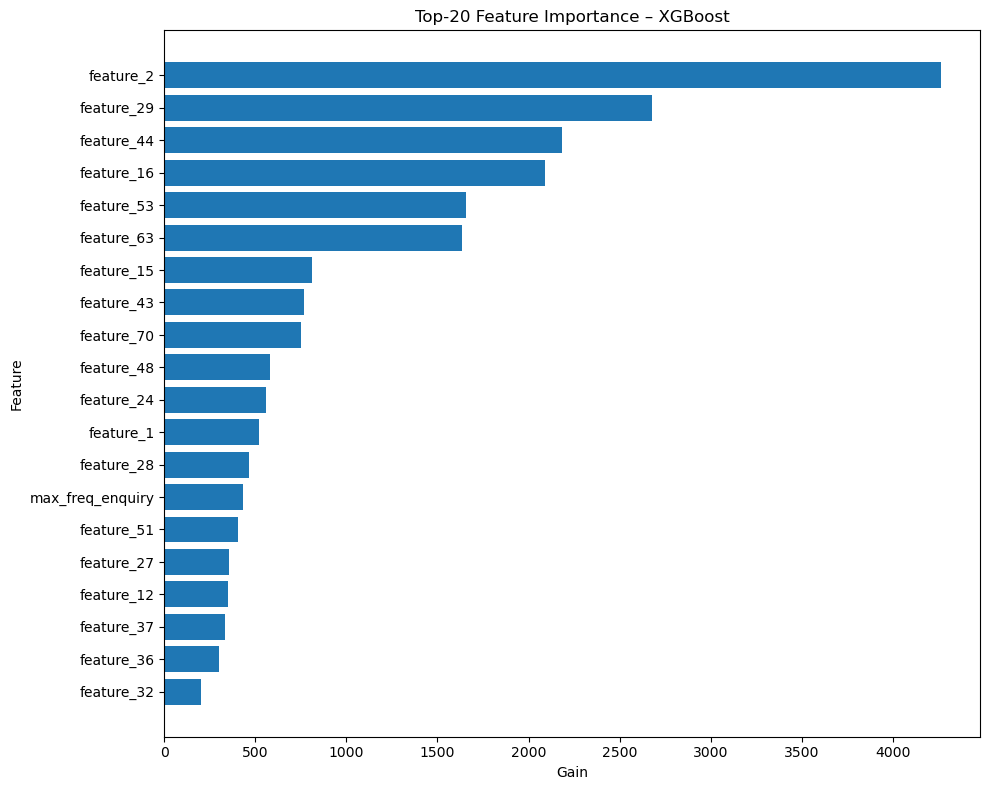

In [143]:


top_20_features = final_feature_matrix.copy()

plt.figure(figsize=(10, 8))

plt.barh(
    top_20_features["Original_Feature"][::-1],
    top_20_features["Gain"][::-1]
)

plt.xlabel("Gain")
plt.ylabel("Feature")
plt.title("Top-20 Feature Importance – XGBoost")
plt.tight_layout()

plt.show()

# Phase 13 – Final Model Evaluation and Risk Rank Ordering	

## Final Model Performance Comparison

In [144]:


model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Improved XGBoost",
        "Client Benchmark"
    ],
    "ROC_AUC": [
        0.6620,
        0.6808,
        0.6748,
        np.nan
    ],
    "Gini": [
        0.3239,
        0.3616,
        0.3496,
        0.3790
    ]
})

model_comparison["Gini_Percentage"] = model_comparison["Gini"] * 100
model_comparison["Gap_vs_Benchmark_pp"] = (
    model_comparison["Gini"] - 0.3790
) * 100

display(model_comparison.round(4))

,Model,ROC_AUC,Gini,Gini_Percentage,Gap_vs_Benchmark_pp
0,Logistic Regression,0.6620,0.3239,32.39,-5.51
1,XGBoost,0.6808,0.3616,36.16,-1.74
2,Improved XGBoost,0.6748,0.3496,34.96,-2.94
3,Client Benchmark,NaN,0.3790,37.90,0.00


## Final Model Selection

In [145]:


final_model = xgb_model

final_model_name = "XGBoost"

final_model_gini = 0.3616
benchmark_gini = 0.3790

performance_gap = final_model_gini - benchmark_gini
performance_gap_pp = performance_gap * 100

print("Final Model:", final_model_name)
print(f"Final Model Gini: {final_model_gini:.4f} ({final_model_gini * 100:.2f}%)")
print(f"Client Benchmark Gini: {benchmark_gini:.4f} ({benchmark_gini * 100:.2f}%)")
print(f"Gap to Benchmark: {performance_gap_pp:.2f} percentage points")

if final_model_gini >= benchmark_gini:
    print("Status: Final model meets or exceeds the client benchmark.")
else:
    print("Status: Final model is below the client benchmark.")

Final Model: XGBoost
Final Model Gini: 0.3616 (36.16%)
Client Benchmark Gini: 0.3790 (37.90%)
Gap to Benchmark: -1.74 percentage points
Status: Final model is below the client benchmark.


##  Final Model Rank Ordering

In [146]:


final_model_proba = final_model.predict_proba(X_test_final)[:, 1]


rank_ordering = pd.DataFrame({
    "Actual_Bad_Label": y_test.values,
    "Predicted_Bad_Probability": final_model_proba
})


rank_ordering = rank_ordering.sort_values(
    "Predicted_Bad_Probability",
    ascending=False
).reset_index(drop=True)


rank_ordering["Decile"] = pd.qcut(
    rank_ordering.index,
    q=10,
    labels=False
)


rank_ordering["Decile"] = 10 - rank_ordering["Decile"]


decile_summary = (
    rank_ordering
    .groupby("Decile")
    .agg(
        Customers=("Actual_Bad_Label", "count"),
        Bad_Customers=("Actual_Bad_Label", "sum"),
        Bad_Rate=("Actual_Bad_Label", "mean"),
        Average_Predicted_Probability=("Predicted_Bad_Probability", "mean")
    )
    .reset_index()
    .sort_values("Decile", ascending=False)
)

decile_summary["Bad_Rate_Percentage"] = (
    decile_summary["Bad_Rate"] * 100
)

display(
    decile_summary[
        [
            "Decile",
            "Customers",
            "Bad_Customers",
            "Bad_Rate_Percentage",
            "Average_Predicted_Probability"
        ]
    ].round(4)
)

,Decile,Customers,Bad_Customers,Bad_Rate_Percentage,Average_Predicted_Probability
9,10,478,31,6.4854,0.6743
8,9,478,46,9.6234,0.5565
7,8,478,28,5.8577,0.4850
6,7,478,30,6.2762,0.4266
5,6,478,20,4.1841,0.3731
4,5,478,15,3.1381,0.3227
3,4,478,10,2.0921,0.2773
2,3,478,10,2.0921,0.2257
1,2,478,5,1.0460,0.1709
0,1,478,6,1.2552,0.0960


##  Rank Ordering Interpretation

The final XGBoost model ranks customers according to their predicted probability of bad credit.

The rank ordering shows that customers in the higher-risk deciles generally have higher bad-credit rates than customers in the lower-risk deciles. The relationship is not perfectly monotonic, as some deciles show small fluctuations in bad-credit rates.

This indicates useful risk discrimination, while also highlighting that the model does not achieve perfect rank ordering across all deciles.

In [147]:


highest_risk_decile = decile_summary.loc[
    decile_summary["Decile"] == 10, "Bad_Rate_Percentage"
].iloc[0]

lowest_risk_decile = decile_summary.loc[
    decile_summary["Decile"] == 1, "Bad_Rate_Percentage"
].iloc[0]

top_3_bad_rate = decile_summary.loc[
    decile_summary["Decile"].isin([10, 9, 8]),
    "Bad_Customers"
].sum() / decile_summary["Bad_Customers"].sum() * 100

print(f"Highest-risk decile bad rate: {highest_risk_decile:.2f}%")
print(f"Lowest-risk decile bad rate: {lowest_risk_decile:.2f}%")
print(f"Bad customers concentrated in top 3 deciles: {top_3_bad_rate:.2f}%")

print("\nInterpretation:")

if highest_risk_decile > lowest_risk_decile:
    print(
        "The model successfully identifies a higher-risk group in the "
        "highest predicted-risk decile."
    )
else:
    print(
        "The highest-risk decile does not have a higher bad rate than "
        "the lowest-risk decile."
    )

print(
    "Rank ordering is useful overall, but it is not perfectly monotonic "
    "across all deciles."
)

Highest-risk decile bad rate: 6.49%
Lowest-risk decile bad rate: 1.26%
Bad customers concentrated in top 3 deciles: 52.24%

Interpretation:
The model successfully identifies a higher-risk group in the highest predicted-risk decile.
Rank ordering is useful overall, but it is not perfectly monotonic across all deciles.


## Out-of-Time Validation

### Create Out-of-Time Validation Split

To assess temporal robustness, customers are divided chronologically into an earlier development period and a later out-of-time validation period.

In [148]:

customer_application_dates = timing_features[
    ["customer_no", "dt_opened"]
].copy()


customer_application_dates = (
    customer_application_dates
    .drop_duplicates(subset="customer_no")
    .sort_values("dt_opened")
    .reset_index(drop=True)
)

cutoff_index = int(len(customer_application_dates) * 0.80)

cutoff_date = customer_application_dates.loc[
    cutoff_index, "dt_opened"
]


temporal_train_customers = customer_application_dates.loc[
    customer_application_dates["dt_opened"] < cutoff_date,
    "customer_no"
]


temporal_valid_customers = customer_application_dates.loc[
    customer_application_dates["dt_opened"] >= cutoff_date,
    "customer_no"
]


temporal_target = feature_matrix_model[
    ["customer_no", "Bad_label"]
].copy()

temporal_target = temporal_target.merge(
    customer_application_dates,
    on="customer_no",
    how="left"
)

temporal_target["Split"] = np.where(
    temporal_target["customer_no"].isin(temporal_train_customers),
    "Development",
    "Out-of-Time Validation"
)

development_data = temporal_target[
    temporal_target["Split"] == "Development"
].copy()

out_of_time_data = temporal_target[
    temporal_target["Split"] == "Out-of-Time Validation"
].copy()


customer_overlap = set(
    development_data["customer_no"]
).intersection(
    set(out_of_time_data["customer_no"])
)

print("OUT-OF-TIME VALIDATION SPLIT")
print("=" * 60)

print("Cutoff date:", cutoff_date)

print("\nDevelopment period:")
print("Customers:", len(development_data))
print(
    "Date range:",
    development_data["dt_opened"].min(),
    "to",
    development_data["dt_opened"].max()
)
print(
    "Bad-credit rate:",
    f"{development_data['Bad_label'].mean() * 100:.2f}%"
)

print("\nOut-of-Time validation period:")
print("Customers:", len(out_of_time_data))
print(
    "Date range:",
    out_of_time_data["dt_opened"].min(),
    "to",
    out_of_time_data["dt_opened"].max()
)
print(
    "Bad-credit rate:",
    f"{out_of_time_data['Bad_label'].mean() * 100:.2f}%"
)

print("\nCustomer overlap:", len(customer_overlap))

if len(customer_overlap) == 0:
    print("\nResult: PASS")
    print(
        "Development and out-of-time validation customer populations "
        "are completely separated."
    )
else:
    print("\nResult: REVIEW REQUIRED")

OUT-OF-TIME VALIDATION SPLIT
Cutoff date: 2015-11-24 00:00:00

Development period:
Customers: 18945
Date range: 2015-04-16 00:00:00 to 2015-11-21 00:00:00
Bad-credit rate: 4.21%

Out-of-Time validation period:
Customers: 4951
Date range: 2015-11-24 00:00:00 to 2015-12-31 00:00:00
Bad-credit rate: 4.18%

Customer overlap: 0

Result: PASS
Development and out-of-time validation customer populations are completely separated.


### Prepare Out-of-Time Modelling Data

The chronological customer groups are converted into separate development and out-of-time modelling datasets while preserving the same feature structure.

In [149]:


temporal_train_mask = feature_matrix_model["customer_no"].isin(
    temporal_train_customers
)

temporal_valid_mask = feature_matrix_model["customer_no"].isin(
    temporal_valid_customers
)


X_oot_train = X.loc[temporal_train_mask].copy()
X_oot_valid = X.loc[temporal_valid_mask].copy()

y_oot_train = y.loc[temporal_train_mask].copy()
y_oot_valid = y.loc[temporal_valid_mask].copy()


customer_ids_oot_train = set(
    feature_matrix_model.loc[
        temporal_train_mask, "customer_no"
    ]
)

customer_ids_oot_valid = set(
    feature_matrix_model.loc[
        temporal_valid_mask, "customer_no"
    ]
)

customer_overlap_oot = (
    customer_ids_oot_train.intersection(
        customer_ids_oot_valid
    )
)

all_temporal_customers = (
    customer_ids_oot_train.union(
        customer_ids_oot_valid
    )
)

all_project_customers = set(
    feature_matrix_model["customer_no"]
)

print("OUT-OF-TIME MODELLING DATA")
print("=" * 60)

print("Development X shape:", X_oot_train.shape)
print("Validation X shape :", X_oot_valid.shape)

print("\nDevelopment y shape:", y_oot_train.shape)
print("Validation y shape :", y_oot_valid.shape)

print(
    "\nDevelopment bad-credit rate:",
    f"{y_oot_train.mean() * 100:.2f}%"
)

print(
    "Validation bad-credit rate :",
    f"{y_oot_valid.mean() * 100:.2f}%"
)

print("\nCustomer overlap:", len(customer_overlap_oot))

print(
    "All customers accounted for:",
    all_temporal_customers == all_project_customers
)

print(
    "Feature columns identical:",
    list(X_oot_train.columns)
    == list(X_oot_valid.columns)
)

if (
    len(customer_overlap_oot) == 0
    and all_temporal_customers == all_project_customers
    and list(X_oot_train.columns)
    == list(X_oot_valid.columns)
):
    print("\nResult: PASS")
    print(
        "Out-of-time development and validation datasets are correctly "
        "separated and ready for temporal-only preprocessing."
    )
else:
    print("\nResult: REVIEW REQUIRED")

OUT-OF-TIME MODELLING DATA
Development X shape: (18945, 77)
Validation X shape : (4951, 77)

Development y shape: (18945,)
Validation y shape : (4951,)

Development bad-credit rate: 4.21%
Validation bad-credit rate : 4.18%

Customer overlap: 0
All customers accounted for: True
Feature columns identical: True

Result: PASS
Out-of-time development and validation datasets are correctly separated and ready for temporal-only preprocessing.


### Apply Temporal-Only Preprocessing

For the out-of-time evaluation, preprocessing rules are learned only from the earlier development period and then applied to the later validation period.

In [150]:


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


oot_numeric_imputer = SimpleImputer(strategy="median")

X_oot_train_numeric = pd.DataFrame(
    oot_numeric_imputer.fit_transform(
        X_oot_train[numeric_features]
    ),
    index=X_oot_train.index,
    columns=numeric_features
)

X_oot_valid_numeric = pd.DataFrame(
    oot_numeric_imputer.transform(
        X_oot_valid[numeric_features]
    ),
    index=X_oot_valid.index,
    columns=numeric_features
)


X_oot_train_cat = (
    X_oot_train[categorical_features]
    .astype(object)
    .replace({pd.NA: np.nan})
)

X_oot_valid_cat = (
    X_oot_valid[categorical_features]
    .astype(object)
    .replace({pd.NA: np.nan})
)

oot_categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="__MISSING__"
)

X_oot_train_cat = pd.DataFrame(
    oot_categorical_imputer.fit_transform(
        X_oot_train_cat
    ),
    index=X_oot_train.index,
    columns=categorical_features
).astype(str)

X_oot_valid_cat = pd.DataFrame(
    oot_categorical_imputer.transform(
        X_oot_valid_cat
    ),
    index=X_oot_valid.index,
    columns=categorical_features
).astype(str)



X_oot_train_high_card = pd.DataFrame(
    index=X_oot_train.index
)

X_oot_valid_high_card = pd.DataFrame(
    index=X_oot_valid.index
)

oot_frequency_maps = {}

for col in high_cardinality_features:

    frequency_map = (
        X_oot_train_cat[col]
        .value_counts(normalize=True)
    )

    oot_frequency_maps[col] = frequency_map

    X_oot_train_high_card[col] = (
        X_oot_train_cat[col]
        .map(frequency_map)
        .fillna(0)
        .astype(float)
    )

    X_oot_valid_high_card[col] = (
        X_oot_valid_cat[col]
        .map(frequency_map)
        .fillna(0)
        .astype(float)
    )



oot_onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_oot_train_onehot = oot_onehot_encoder.fit_transform(
    X_oot_train_cat[low_cardinality_features]
)

X_oot_valid_onehot = oot_onehot_encoder.transform(
    X_oot_valid_cat[low_cardinality_features]
)

oot_onehot_columns = (
    oot_onehot_encoder
    .get_feature_names_out(
        low_cardinality_features
    )
)

X_oot_train_onehot = pd.DataFrame(
    X_oot_train_onehot,
    index=X_oot_train.index,
    columns=oot_onehot_columns
)

X_oot_valid_onehot = pd.DataFrame(
    X_oot_valid_onehot,
    index=X_oot_valid.index,
    columns=oot_onehot_columns
)



X_oot_train_final = pd.concat(
    [
        X_oot_train_numeric,
        X_oot_train_high_card,
        X_oot_train_onehot
    ],
    axis=1
)

X_oot_valid_final = pd.concat(
    [
        X_oot_valid_numeric,
        X_oot_valid_high_card,
        X_oot_valid_onehot
    ],
    axis=1
)


print("TEMPORAL-ONLY PREPROCESSING")
print("=" * 60)

print(
    "OOT development shape:",
    X_oot_train_final.shape
)

print(
    "OOT validation shape:",
    X_oot_valid_final.shape
)

print(
    "\nMissing values in OOT development:",
    X_oot_train_final.isna().sum().sum()
)

print(
    "Missing values in OOT validation:",
    X_oot_valid_final.isna().sum().sum()
)

print(
    "\nFinal feature columns identical:",
    list(X_oot_train_final.columns)
    == list(X_oot_valid_final.columns)
)

print(
    "All final features numeric:",
    all(
        pd.api.types.is_numeric_dtype(dtype)
        for dtype in X_oot_train_final.dtypes
    )
)

print(
    "\nUnseen validation categories in one-hot encoding:",
    "Handled with handle_unknown='ignore'"
)

print(
    "Unseen high-cardinality categories:",
    "Mapped to frequency 0"
)

oot_preprocessing_pass = (
    X_oot_train_final.isna().sum().sum() == 0
    and X_oot_valid_final.isna().sum().sum() == 0
    and list(X_oot_train_final.columns)
    == list(X_oot_valid_final.columns)
    and all(
        pd.api.types.is_numeric_dtype(dtype)
        for dtype in X_oot_train_final.dtypes
    )
)

print("\nResult:")

if oot_preprocessing_pass:
    print("PASS")
    print(
        "Temporal preprocessing was fitted only on the earlier "
        "development period and applied to the later validation period."
    )
else:
    print("REVIEW REQUIRED")

TEMPORAL-ONLY PREPROCESSING
OOT development shape: (18945, 4256)
OOT validation shape: (4951, 4256)

Missing values in OOT development: 0
Missing values in OOT validation: 0

Final feature columns identical: True
All final features numeric: True

Unseen validation categories in one-hot encoding: Handled with handle_unknown='ignore'
Unseen high-cardinality categories: Mapped to frequency 0

Result:
PASS
Temporal preprocessing was fitted only on the earlier development period and applied to the later validation period.


### Evaluate XGBoost on Later Customers

A fresh XGBoost model is trained on the earlier development period and evaluated on the later out-of-time validation period.

In [151]:


from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score


oot_negative_count = (y_oot_train == 0).sum()
oot_positive_count = (y_oot_train == 1).sum()

oot_scale_pos_weight = (
    oot_negative_count / oot_positive_count
)


xgb_oot_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=oot_scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_oot_model.fit(
    X_oot_train_final,
    y_oot_train
)


oot_pred_proba = xgb_oot_model.predict_proba(
    X_oot_valid_final
)[:, 1]


oot_roc_auc = roc_auc_score(
    y_oot_valid,
    oot_pred_proba
)

oot_gini = (2 * oot_roc_auc) - 1

print("OUT-OF-TIME XGBOOST EVALUATION")
print("=" * 60)

print("Development customers:", len(y_oot_train))
print("Validation customers :", len(y_oot_valid))

print(
    "\nDevelopment bad-credit rate:",
    f"{y_oot_train.mean() * 100:.2f}%"
)

print(
    "Validation bad-credit rate :",
    f"{y_oot_valid.mean() * 100:.2f}%"
)

print(
    "\nScale positive weight:",
    f"{oot_scale_pos_weight:.4f}"
)

print(
    "\nOut-of-Time ROC-AUC:",
    f"{oot_roc_auc:.4f}"
)

print(
    "Out-of-Time Gini:",
    f"{oot_gini:.4f} ({oot_gini * 100:.2f}%)"
)

print(
    "\nRandom-split XGBoost Gini:",
    "0.3616 (36.16%)"
)

print(
    "Difference:",
    f"{(oot_gini - 0.3616) * 100:.2f} percentage points"
)

print("\nInterpretation:")

if oot_gini >= 0.3616:
    print(
        "The out-of-time model maintains or exceeds the random-split "
        "XGBoost Gini, indicating strong temporal stability."
    )
else:
    print(
        "The out-of-time model performs below the random-split XGBoost "
        "Gini, indicating some loss of predictive performance over time."
    )

OUT-OF-TIME XGBOOST EVALUATION
Development customers: 18945
Validation customers : 4951

Development bad-credit rate: 4.21%
Validation bad-credit rate : 4.18%

Scale positive weight: 22.7704

Out-of-Time ROC-AUC: 0.6325
Out-of-Time Gini: 0.2650 (26.50%)

Random-split XGBoost Gini: 0.3616 (36.16%)
Difference: -9.66 percentage points

Interpretation:
The out-of-time model performs below the random-split XGBoost Gini, indicating some loss of predictive performance over time.


### Assess Out-of-Time Rank Ordering

Evaluate whether the model continues to separate higher-risk customers from lower-risk customers when applied to later-period customers.

In [152]:


oot_rank_ordering = pd.DataFrame({
    "Actual_Bad_Label": y_oot_valid.values,
    "Predicted_Bad_Probability": oot_pred_proba
})


oot_rank_ordering = (
    oot_rank_ordering
    .sort_values(
        "Predicted_Bad_Probability",
        ascending=False
    )
    .reset_index(drop=True)
)


oot_rank_ordering["Decile"] = pd.qcut(
    oot_rank_ordering.index,
    q=10,
    labels=False
)


oot_rank_ordering["Decile"] = (
    10 - oot_rank_ordering["Decile"]
)


oot_decile_summary = (
    oot_rank_ordering
    .groupby("Decile")
    .agg(
        Customers=("Actual_Bad_Label", "count"),
        Bad_Customers=("Actual_Bad_Label", "sum"),
        Bad_Rate=("Actual_Bad_Label", "mean"),
        Average_Predicted_Probability=(
            "Predicted_Bad_Probability",
            "mean"
        )
    )
    .reset_index()
    .sort_values("Decile", ascending=False)
)

oot_decile_summary["Bad_Rate_Percentage"] = (
    oot_decile_summary["Bad_Rate"] * 100
)


oot_highest_risk_rate = oot_decile_summary.loc[
    oot_decile_summary["Decile"] == 10,
    "Bad_Rate_Percentage"
].iloc[0]

oot_lowest_risk_rate = oot_decile_summary.loc[
    oot_decile_summary["Decile"] == 1,
    "Bad_Rate_Percentage"
].iloc[0]

oot_top_3_concentration = (
    oot_decile_summary.loc[
        oot_decile_summary["Decile"].isin([10, 9, 8]),
        "Bad_Customers"
    ].sum()
    / oot_decile_summary["Bad_Customers"].sum()
    * 100
)

display(
    oot_decile_summary[
        [
            "Decile",
            "Customers",
            "Bad_Customers",
            "Bad_Rate_Percentage",
            "Average_Predicted_Probability"
        ]
    ].round(4)
)

print("\nOUT-OF-TIME RANK ORDERING SUMMARY")
print("=" * 60)

print(
    f"Highest-risk decile bad rate: "
    f"{oot_highest_risk_rate:.2f}%"
)

print(
    f"Lowest-risk decile bad rate: "
    f"{oot_lowest_risk_rate:.2f}%"
)

print(
    f"Bad customers in top 3 deciles: "
    f"{oot_top_3_concentration:.2f}%"
)

print(
    f"Highest-to-lowest bad-rate ratio: "
    f"{oot_highest_risk_rate / oot_lowest_risk_rate:.2f}x"
)

print("\nInterpretation:")

if oot_highest_risk_rate > oot_lowest_risk_rate:
    print(
        "The model continues to distinguish higher-risk customers "
        "from lower-risk customers on later-period data."
    )
else:
    print(
        "The model does not provide the expected risk separation "
        "on later-period data."
    )

,Decile,Customers,Bad_Customers,Bad_Rate_Percentage,Average_Predicted_Probability
9,10,496,42,8.4677,0.7207
8,9,495,37,7.4747,0.6171
7,8,495,23,4.6465,0.5459
6,7,495,23,4.6465,0.4838
5,6,495,17,3.4343,0.4286
4,5,495,11,2.2222,0.3715
3,4,495,16,3.2323,0.3132
2,3,495,15,3.0303,0.2555
1,2,495,11,2.2222,0.1920
0,1,495,12,2.4242,0.1066



OUT-OF-TIME RANK ORDERING SUMMARY
Highest-risk decile bad rate: 8.47%
Lowest-risk decile bad rate: 2.42%
Bad customers in top 3 deciles: 49.28%
Highest-to-lowest bad-rate ratio: 3.49x

Interpretation:
The model continues to distinguish higher-risk customers from lower-risk customers on later-period data.


## Improvement 3 – Risk Concentration and Lift Analysis

In [153]:


def calculate_risk_concentration(decile_table, target):
    overall_bad_rate = target.mean()
    total_bad_customers = decile_table["Bad_Customers"].sum()

    top_10 = decile_table[decile_table["Decile"] >= 10]
    top_20 = decile_table[decile_table["Decile"] >= 9]
    top_30 = decile_table[decile_table["Decile"] >= 8]

    top_10_bad_rate = (
        top_10["Bad_Customers"].sum() / top_10["Customers"].sum()
    )

    top_10_capture = (
        top_10["Bad_Customers"].sum() / total_bad_customers
    )

    top_20_capture = (
        top_20["Bad_Customers"].sum() / total_bad_customers
    )

    top_30_capture = (
        top_30["Bad_Customers"].sum() / total_bad_customers
    )

    return {
        "Overall_Bad_Rate": overall_bad_rate,
        "Top_10_Bad_Rate": top_10_bad_rate,
        "Top_10_Lift": top_10_bad_rate / overall_bad_rate,
        "Top_10_Bad_Capture": top_10_capture,
        "Top_20_Bad_Capture": top_20_capture,
        "Top_30_Bad_Capture": top_30_capture
    }


random_risk_metrics = calculate_risk_concentration(
    decile_summary,
    y_test
)

oot_risk_metrics = calculate_risk_concentration(
    oot_decile_summary,
    y_oot_valid
)

risk_concentration_summary = pd.DataFrame({
    "Metric": [
        "Overall bad-credit rate",
        "Top 10% bad-credit rate",
        "Top 10% lift",
        "Top 10% bad-customer capture",
        "Top 20% bad-customer capture",
        "Top 30% bad-customer capture"
    ],
    "Random_Split": [
        random_risk_metrics["Overall_Bad_Rate"] * 100,
        random_risk_metrics["Top_10_Bad_Rate"] * 100,
        random_risk_metrics["Top_10_Lift"],
        random_risk_metrics["Top_10_Bad_Capture"] * 100,
        random_risk_metrics["Top_20_Bad_Capture"] * 100,
        random_risk_metrics["Top_30_Bad_Capture"] * 100
    ],
    "Out_of_Time": [
        oot_risk_metrics["Overall_Bad_Rate"] * 100,
        oot_risk_metrics["Top_10_Bad_Rate"] * 100,
        oot_risk_metrics["Top_10_Lift"],
        oot_risk_metrics["Top_10_Bad_Capture"] * 100,
        oot_risk_metrics["Top_20_Bad_Capture"] * 100,
        oot_risk_metrics["Top_30_Bad_Capture"] * 100
    ]
})

display(
    risk_concentration_summary.round(2)
)

print("\nRISK CONCENTRATION ANALYSIS")
print("=" * 60)

print(
    f"Random-split top 10% lift: "
    f"{random_risk_metrics['Top_10_Lift']:.2f}x"
)

print(
    f"Out-of-time top 10% lift: "
    f"{oot_risk_metrics['Top_10_Lift']:.2f}x"
)

print(
    f"\nRandom-split top 10% captures "
    f"{random_risk_metrics['Top_10_Bad_Capture'] * 100:.2f}% "
    f"of bad customers."
)

print(
    f"Out-of-time top 10% captures "
    f"{oot_risk_metrics['Top_10_Bad_Capture'] * 100:.2f}% "
    f"of bad customers."
)

print(
    f"\nRandom-split top 30% captures "
    f"{random_risk_metrics['Top_30_Bad_Capture'] * 100:.2f}% "
    f"of bad customers."
)

print(
    f"Out-of-time top 30% captures "
    f"{oot_risk_metrics['Top_30_Bad_Capture'] * 100:.2f}% "
    f"of bad customers."
)

print("\nInterpretation:")

if oot_risk_metrics["Top_10_Lift"] > 1:
    print(
        "The out-of-time model identifies a higher-risk group "
        "within the top 10% of predicted-risk customers."
    )
else:
    print(
        "The out-of-time model does not provide meaningful "
        "lift in the top 10% risk group."
    )

,Metric,Random_Split,Out_of_Time
0,Overall bad-credit rate,4.21,4.18
1,Top 10% bad-credit rate,6.49,8.47
2,Top 10% lift,1.54,2.03
3,Top 10% bad-customer capture,15.42,20.29
4,Top 20% bad-customer capture,38.31,38.16
5,Top 30% bad-customer capture,52.24,49.28



RISK CONCENTRATION ANALYSIS
Random-split top 10% lift: 1.54x
Out-of-time top 10% lift: 2.03x

Random-split top 10% captures 15.42% of bad customers.
Out-of-time top 10% captures 20.29% of bad customers.

Random-split top 30% captures 52.24% of bad customers.
Out-of-time top 30% captures 49.28% of bad customers.

Interpretation:
The out-of-time model identifies a higher-risk group within the top 10% of predicted-risk customers.


## Final Gini Performance Visualization

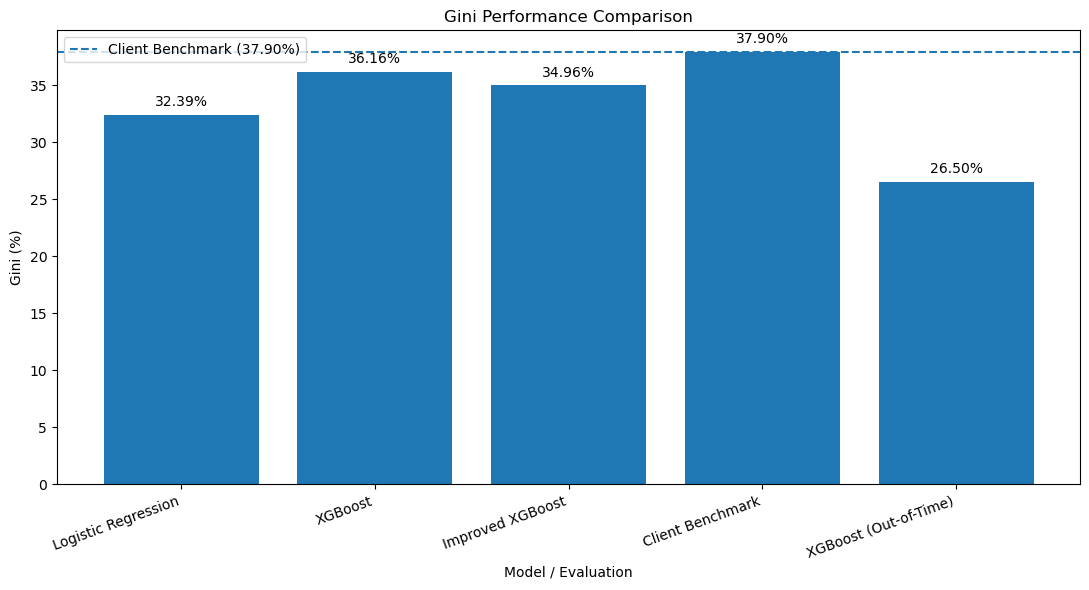

In [154]:


gini_visualization = pd.DataFrame({
    "Evaluation": [
        "Logistic Regression",
        "XGBoost",
        "Improved XGBoost",
        "Client Benchmark",
        "XGBoost (Out-of-Time)"
    ],
    "Gini_Percentage": [
        32.39,
        36.16,
        34.96,
        37.90,
        26.50
    ]
})

plt.figure(figsize=(11, 6))

bars = plt.bar(
    gini_visualization["Evaluation"],
    gini_visualization["Gini_Percentage"]
)

plt.axhline(
    y=37.90,
    linestyle="--",
    linewidth=1.5,
    label="Client Benchmark (37.90%)"
)

plt.ylabel("Gini (%)")
plt.xlabel("Model / Evaluation")
plt.title("Gini Performance Comparison")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(
    bars,
    gini_visualization["Gini_Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.legend()
plt.tight_layout()
plt.show()

##  Rank Ordering Comparison

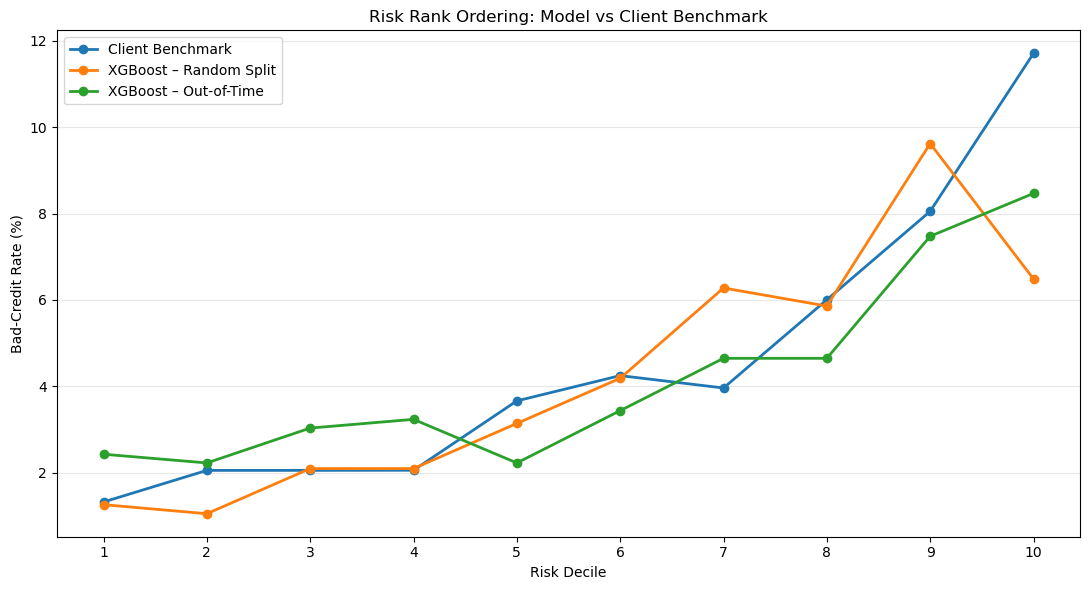

In [155]:

benchmark_rank_ordering = {
    10: 0.11713031,
    9: 0.08052709,
    8: 0.06002928,
    7: 0.03958944,
    6: 0.04245974,
    5: 0.03660322,
    4: 0.02052786,
    3: 0.02049780,
    2: 0.02049780,
    1: 0.01317716
}


benchmark_rates = [
    benchmark_rank_ordering[d] * 100
    for d in sorted(benchmark_rank_ordering, reverse=True)
]


random_rates = (
    decile_summary
    .sort_values("Decile", ascending=False)["Bad_Rate_Percentage"]
    .tolist()
)


oot_rates = (
    oot_decile_summary
    .sort_values("Decile", ascending=False)["Bad_Rate_Percentage"]
    .tolist()
)

deciles = sorted(benchmark_rank_ordering, reverse=True)

plt.figure(figsize=(11, 6))

plt.plot(
    deciles,
    benchmark_rates,
    marker="o",
    linewidth=2,
    label="Client Benchmark"
)

plt.plot(
    deciles,
    random_rates,
    marker="o",
    linewidth=2,
    label="XGBoost – Random Split"
)

plt.plot(
    deciles,
    oot_rates,
    marker="o",
    linewidth=2,
    label="XGBoost – Out-of-Time"
)

plt.xlabel("Risk Decile")
plt.ylabel("Bad-Credit Rate (%)")
plt.title("Risk Rank Ordering: Model vs Client Benchmark")

plt.xticks(deciles)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Recruiter-Friendly Business KPI Summary

In [156]:


business_kpis = pd.DataFrame({
    "KPI": [
        "Final Model",
        "Random-Split Gini",
        "Out-of-Time Gini",
        "Client Benchmark Gini",
        "Gap to Benchmark",
        "Out-of-Time Top-10% Lift",
        "Out-of-Time Top-10% Bad-Customer Capture",
        "Out-of-Time Top-30% Bad-Customer Capture"
    ],
    "Value": [
        final_model_name,
        f"{final_model_gini * 100:.2f}%",
        f"{oot_gini * 100:.2f}%",
        f"{benchmark_gini * 100:.2f}%",
        f"{(final_model_gini - benchmark_gini) * 100:.2f} pp",
        f"{oot_risk_metrics['Top_10_Lift']:.2f}x",
        f"{oot_risk_metrics['Top_10_Bad_Capture'] * 100:.2f}%",
        f"{oot_risk_metrics['Top_30_Bad_Capture'] * 100:.2f}%"
    ]
})

display(business_kpis)

print("\nKEY BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"XGBoost is the final selected model with "
    f"{final_model_gini * 100:.2f}% random-split Gini."
)

print(
    f"Out-of-time Gini is {oot_gini * 100:.2f}%, "
    f"showing lower discrimination on later-period customers."
)

print(
    f"The later-period top 10% risk group has "
    f"{oot_risk_metrics['Top_10_Lift']:.2f}x lift."
)

print(
    f"The top 30% of later-period customers capture "
    f"{oot_risk_metrics['Top_30_Bad_Capture'] * 100:.2f}% "
    f"of observed bad customers."
)

,KPI,Value
0,Final Model,XGBoost
1,Random-Split Gini,36.16%
2,Out-of-Time Gini,26.50%
3,Client Benchmark Gini,37.90%
4,Gap to Benchmark,-1.74 pp
5,Out-of-Time Top-10% Lift,2.03x
6,Out-of-Time Top-10% Bad-Customer Capture,20.29%
7,Out-of-Time Top-30% Bad-Customer Capture,49.28%



KEY BUSINESS INSIGHTS
XGBoost is the final selected model with 36.16% random-split Gini.
Out-of-time Gini is 26.50%, showing lower discrimination on later-period customers.
The later-period top 10% risk group has 2.03x lift.
The top 30% of later-period customers capture 49.28% of observed bad customers.


# Phase 14 – Business Interpretation, Conclusion, and Future Scope

## Project Conclusion

The banking credit-risk analysis successfully integrated customer demographic, account, payment-history, and enquiry information into a customer-level modelling dataset.

The project included data cleaning, exploratory analysis, business-oriented feature engineering, missing-value treatment, semantic feature classification, high-cardinality handling, categorical encoding, model development, feature-importance analysis, and risk rank ordering.

Additional validation strengthened the modelling process. As-of-date validation found no account reporting records or enquiries occurring after the customer application date. The preprocessing pipeline was also validated to ensure that imputation and encoding rules were learned from the training data and applied consistently to validation data.

Among the evaluated models, the original XGBoost model achieved the best random-split performance with a Gini score of 36.16%, outperforming Logistic Regression at 32.39% and the alternative XGBoost configuration at 34.96%. The random-split Gini is 1.74 percentage points below the client benchmark of 37.90%.

Out-of-time validation provided a more realistic assessment of temporal performance. The XGBoost model achieved a Gini score of 26.50% on later-period customers, representing a decrease of 9.66 percentage points compared with the random-split result.

Despite this temporal performance degradation, the model continued to provide useful risk differentiation. The highest-risk decile had an 8.47% bad-credit rate compared with 2.42% in the lowest-risk decile. The top 10% risk group achieved 2.03x lift and captured 20.29% of observed bad customers, while the top 30% captured 49.28%.

Overall, the model demonstrates practical customer risk-ranking capability, while the out-of-time results highlight the importance of temporal stability monitoring and further model refinement before production deployment.

## Business Impact

The developed credit-risk model can support Bank GoodCredit by prioritizing customers according to their predicted probability of bad credit.

The out-of-time results show that the highest-risk 10% of customers had approximately 2x the overall bad-credit rate, providing a practical basis for targeted risk review and monitoring.

The model can support risk-based customer segmentation, enhanced credit assessment, closer monitoring of higher-risk customers, and more focused allocation of risk-management resources.

The predicted risk score should be used as one input within the bank's broader credit policy and decision-making framework rather than as the sole basis for automated credit decisions.

## Project Limitations

The final XGBoost model achieved a random-split Gini score of 36.16%, which is 1.74 percentage points below the client benchmark of 37.90%.

More importantly, the out-of-time Gini decreased to 26.50%, a reduction of 9.66 percentage points compared with the random-split evaluation. This indicates that model discrimination is less stable when applied to later-period customers.

The out-of-time rank ordering remains useful, but bad-credit rates are not perfectly monotonic across all deciles, indicating some fluctuations in risk separation.

Several demographic variables contain substantial missingness and anonymized or high-cardinality values. Although these were addressed through appropriate preprocessing, their anonymized nature limits direct business interpretation.

The project uses a single out-of-time validation period. Additional rolling or repeated temporal validation would provide stronger evidence of long-term model stability.

The model should therefore be considered a useful risk-ranking solution and a strong analytical foundation, but further validation, monitoring, calibration, and refinement would be required before production deployment.

## Future Scope

Future work can focus on improving predictive performance, temporal stability, and production readiness.

Potential improvements include systematic hyperparameter tuning using training-period validation, additional business-driven feature engineering from account, payment-history, and enquiry data, and evaluation of alternative modelling approaches.

Repeated out-of-time or rolling-window validation can be used to monitor model stability across different application periods and identify changes in customer behaviour or data distribution.

Model calibration and threshold optimization can also be explored to align predicted risk with the bank's operational risk categories and decision policies.

For production deployment, ongoing monitoring of model performance, feature distributions, and population changes would be required, together with periodic model review and recalibration.

## Final Project Summary

This project developed a customer-level credit-risk prediction framework for Bank GoodCredit using demographic, account, payment-history, and enquiry information.

The project covered data-quality assessment, feature engineering, missing-value treatment, semantic feature classification, high-cardinality preprocessing, model development, feature-importance analysis, benchmark comparison, and risk rank ordering.

The original XGBoost model achieved the best random-split Gini score of **36.16%**, compared with **32.39%** for Logistic Regression and **34.96%** for the alternative XGBoost configuration. The client benchmark is **37.90%**.

Additional validation confirmed that historical account and enquiry information did not extend beyond the customer application date and that preprocessing was consistently learned from training data.

Out-of-time validation produced a Gini score of **26.50%**, revealing a **9.66 percentage-point reduction** in discrimination on later-period customers. However, the model retained useful risk-ranking capability, with **2.03x lift** in the highest-risk 10% group and **49.28% of observed bad customers captured** within the highest-risk 30%.

The final XGBoost model therefore provides a useful foundation for credit-risk prioritization while highlighting the need for continued temporal validation, monitoring, calibration, and refinement before production deployment.